In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.lines import Line2D

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.dates as mdates
import numpy as np

import intake

import sys
sys.path.append("/work/mh1498/m301248/TCO_data/COARE-algorithm/Python/COARE3.5/") 
sys.path.append("/work/mh1498/m301248/TCO_data/BCO_observational/mass_fluxes_profiles/yk22_mass_fluxes.py")

import metpy

import meteo


import pandas as pd
from IPython.display import display, HTML

In [2]:
%load_ext autoreload
%autoreload 2

Diregarding intra-seasonal advection, the mean moisture profile is simply set by th balance between boundary layer top and surface fluxes.
$$ q_\mathrm{bl} = \frac{V_\mathrm{sfc} q_\mathrm{sfc} + E q_{h^+}}{V_\mathrm{sfc} + E}$$

here $V_\mathrm{sfc}$ and $E$ must have dimensions of mass fluxes ($\rho C\cdot U$, with units $g~m^{-2}~s^{-1}$)

then at the surface

$$ W_\mathrm{sfc} \approx \frac{q_\mathrm{bl}}{q_\mathrm{sfc}}  = \frac{V_\mathrm{sfc} + E \frac{q_{h^+}}{q_\mathrm{sfc}} }{V_\mathrm{sfc} + E} = \frac{V_\mathrm{sfc} + \chi \cdot E}{V_\mathrm{sfc} + E} $$

from this, I can rearrange the terms to estimate values for the vertical mass transport needed to attain such surface relative humidity $W_\mathrm{sfc}$

$$ E = \frac{\left( 1 - W_\mathrm{sfc} \right) \cdot V_\mathrm{sfc}}{W_\mathrm{sfc} - \chi} $$

From the radiosoundings, $W_\mathrm{sfc} = 0.75$ .

Far reaching idea: use computed $E$ in bulk equation from $\theta$


### set global parameters

In [3]:
## what is the reference layer to compute mixed layer AVERAGED quantities?
mixed_avg_levels   = slice(200, 500)

Rd = 287.
cp = 1004. # j / kg K
Lv = 2.5e6 # J/kg
g = 9.81   # m/s2


Fa_q_eu, Fa_q_or    = (-2e-3)/86400. , (-0.e-3)/86400.   # kg/kg / day
Fa_th_eu , Fa_th_or = -0.75/86400.,       -0./86400.        # K/day
bl_height        = 500.                                    #  mean mixed layer height / m
bl_density       = 1. 


## test what happens with fractions of

In [4]:
## what height is entrained air from?
entrainment_levels = slice(600, 850)    # m

## what height does convective downdrafts come from?
downdraft_levels_eu = slice(1000, 2000)
downdraft_levels_or = slice(2500, 3500)

In [71]:
## compute thetaD
from scipy.optimize import root_scalar

def pot_temp_from_h(theta, p, h_cd, Lv, cp):
    es = 6.1121 * np.exp(17.502 * (theta-273.15) / (240.97 + (theta-273.15)))
    denominator = p - 0.378 * es * (1.0007 + p * 3.46e-6)
    
    return h_cd/cp - theta - (Lv / cp) * 0.622 * es * (1.0007 + p * 3.46e-6) / denominator

# single profile, different levels
def find_theta_for_pair(p, h):
    # def f(t):
    #     return temp_from_h(t, p=p, h_cd=h, Lv=Lv, cp=cp)
    
    f = lambda t : pot_temp_from_h(t, p=p, h_cd=h, Lv=Lv, cp=cp)

    try:
        sol = root_scalar(f, bracket=[270,300], method='brentq')
        return sol.root if sol.converged else np.nan
    except Exception as e:
        print(f"Exception for p={p:.2f}, h={h:.2f}: {e}")
        return np.nan

# since I am working with arrays
vectorized_theta_root = np.vectorize(find_theta_for_pair)




def properties_from_profile(profile, mixed_avg_levels, entrainment_levels, downdraft_levels, vert_dim):

    h_cd = (cp*profile["ta"] + Lv*profile["q"] + g*profile[vert_dim]).sel({vert_dim:downdraft_levels})
    p_cd = profile["p"].sel({vert_dim:downdraft_levels}).values

    thetaD = np.nanmean(vectorized_theta_root( p_cd / 100., h_cd))
    qD = np.nanmean(meteo.qsea(   (thetaD)-273.15 , p_cd/100.  )/1e3)

    theta_out = profile.theta.sel({vert_dim:entrainment_levels}).mean(dim = vert_dim)
    theta_bl  = profile.theta.sel({vert_dim:mixed_avg_levels}).mean(dim = vert_dim)

    q_out = profile.q.sel({vert_dim:entrainment_levels}).mean(dim = vert_dim)
    q_bl  = profile.q.sel({vert_dim:mixed_avg_levels}).mean(dim = vert_dim)

    cd_levels = profile[vert_dim].sel({vert_dim:downdraft_levels}).values

    return xr.Dataset(dict(
    thetaD=xr.DataArray(thetaD, dims=[vert_dim], coords={vert_dim:cd_levels}),
    qD=xr.DataArray(qD, dims=[vert_dim], coords={vert_dim:cd_levels}),
    theta_out=theta_out,
    theta_bl=theta_bl,
    q_out=q_out,
    q_bl=q_bl
))




def CD_properties(profile, downdraft_levels, vert_dim):

    h_cd = (cp*profile["ta"] + Lv*profile["q"] + g*profile[vert_dim]).sel({vert_dim:downdraft_levels})
    p_cd = profile["p"].sel({vert_dim:downdraft_levels}).values

    thetaD = (vectorized_theta_root( p_cd / 100., h_cd))
    print(thetaD.shape)

    qD = (meteo.qsea(   (thetaD)-273.15 , p_cd/100.  )/1e3)

    cd_levels = profile[vert_dim].sel({vert_dim:downdraft_levels}).values

    return xr.Dataset(dict(
            thetaD=xr.DataArray(thetaD, dims=[vert_dim], coords={vert_dim:cd_levels}),
            qD=xr.DataArray(qD, dims=[vert_dim], coords={vert_dim:cd_levels}) ))

#### load profiles

In [72]:
min_hgt = 40.

level2_path = "/work/mh1498/m301248/TCO_data/eurec4a_profiles_level2/EUREC4A_BCO_Vaisala-RS_L2_v3.0.0.nc"
ds_eureca = xr.open_dataset(level2_path)
ds_eureca_bco = ds_eureca.where(((ds_eureca["platform"] == 1)&(ds_eureca["ascent_flag"]==1)&(ds_eureca.alt>min_hgt)), drop=True)
## renaming for common ground
ds_eureca_bco = ds_eureca_bco.swap_dims({"sounding": "launch_time"})
ds_eureca_bco = ds_eureca_bco.rename({"alt":"height"})


ds_orcestra = xr.open_dataset("ipfs://bafybeid7cnw62zmzfgxcvc6q6fa267a7ivk2wcchbmkoyk4kdi5z2yj2w4", engine="zarr")
ds_orcestra
ds_orcestra_bco = ds_orcestra.where(((ds_orcestra["platform"] == "BCO")&(ds_orcestra["ascent_flag"]==0)&(ds_orcestra.height>min_hgt)), drop=True)


In [73]:
## campaign-mean profiles
rh_eu = ds_eureca_bco.rh.mean(dim="launch_time")
wind_eu = ds_eureca_bco.wspd.mean(dim="launch_time")
temp_eu = ds_eureca_bco.ta.mean(dim="launch_time")
theta_eu = ds_eureca_bco.theta.mean(dim="launch_time")
q_eu = ds_eureca_bco.q.mean(dim="launch_time")
press_eu = ds_eureca_bco.p.mean(dim="launch_time")


## to draw profiles of thetaD, qD
E_CD_eu = CD_properties(ds_eureca_bco.mean(dim="launch_time"), downdraft_levels=slice(min_hgt,4000), vert_dim="height")






rh_or = ds_orcestra_bco.rh.mean(dim="launch_time")
wind_or = ds_orcestra_bco.wspd.mean(dim="launch_time")
temp_or = ds_orcestra_bco.ta.mean(dim="launch_time")
theta_or = ds_orcestra_bco.theta.mean(dim="launch_time")
q_or = ds_orcestra_bco.q.mean(dim="launch_time")
press_or = ds_orcestra_bco.p.mean(dim="launch_time")


## to draw profiles of thetaD, qD
E_CD_or = CD_properties(ds_orcestra_bco.mean(dim="launch_time"), downdraft_levels=slice(min_hgt,4000), vert_dim="height")





(396,)
(396,)


In [74]:
## load campaign-mean SST data
ingr_eu = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/EUREC4A_IngrFlux.nc")
sst_eu = ingr_eu.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

ingr_or = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/ORCESTRA_IngrFlux.nc")
sst_or = ingr_or.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

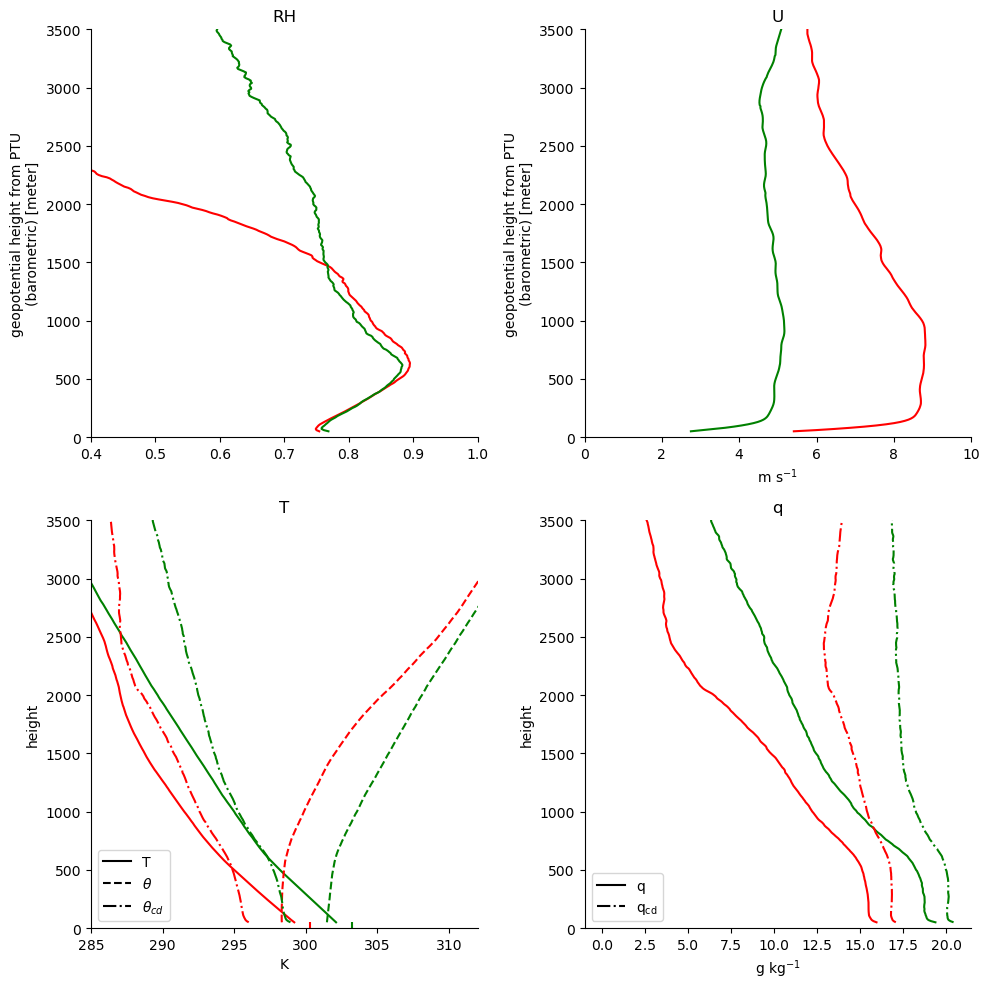

In [75]:
fig, ax = plt.subplots(2,2, figsize=(10,10))
ax = ax.flatten()

rh_eu.plot.line(ax=ax[0], y="height", color="red")
rh_or.plot.line(ax=ax[0], y="height", color="green")
ax[0].set_title("RH")
ax[0].set_xlabel(r"")
ax[0].set_xlim(0.4, 1)

wind_eu.plot.line(ax=ax[1], y="height", color="red")
wind_or.plot.line(ax=ax[1], y="height", color="green")
ax[1].set_title("U")
ax[1].set_xlabel(r"$\rm m~s^{-1}$")
ax[1].set_xlim(0, 10)




temp_eu.plot.line(ax=ax[2], y="height", color="red", linestyle="-")
temp_or.plot.line(ax=ax[2], y="height", color="green", linestyle="-")

theta_eu.plot.line(ax=ax[2], y="height", color="red", linestyle="--")
theta_or.plot.line(ax=ax[2], y="height", color="green", linestyle="--")

E_CD_eu["thetaD"].plot.line(ax=ax[2], y="height", color="red", linestyle="-.")
E_CD_or["thetaD"].plot.line(ax=ax[2], y="height", color="green", linestyle="-.")


legend_elements = [
    Line2D([0], [0], color='k', linestyle='-',  label='T'),
    Line2D([0], [0], color='k', linestyle='--', label=r'$\theta$'),
    Line2D([0], [0], color='k', linestyle='-.',  label=r'$\theta_{cd}$'),
]
ax[2].legend(handles=legend_elements)

ax[2].set_title("T")
ax[2].set_xlabel(r"K")
ax[2].set_xlim(285, 312)
ax[2].vlines([sst_eu, 
              sst_or], 
              ymin=0, ymax=50, 
              color=["red", "green"])




(q_eu*1e3).plot.line(ax=ax[3], y="height", color="red")
(q_or*1e3).plot.line(ax=ax[3], y="height", color="green")

(E_CD_eu["qD"]*1e3).plot.line(ax=ax[3], y="height", color="red", linestyle="-.")
(E_CD_or["qD"]*1e3).plot.line(ax=ax[3], y="height", color="green", linestyle="-.")

legend_elements = [
    Line2D([0], [0], color='k', linestyle='-',  label='q'),
    Line2D([0], [0], color='k', linestyle='-.',  label=r'$\rm q_{cd}$'),
]
ax[3].legend(handles=legend_elements, loc="lower left")

ax[3].set_title(r"q")
ax[3].set_xlabel(r"$\rm g~kg^{-1}$")
# ax[2].set_xlim(285, 305)



for x in ax:
    x.set_ylim(0,3.5e3)
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)


plt.tight_layout()


In [76]:
## compute mean q_sfc
from meteo import qsea

sst_local = ingr_eu.sst.sel(cell=[17,24,31,18,25,32, 19,26,33])
q_sfc_eu = qsea(sst_local-273.15, 1013.)
q_sfc_eu = np.mean(q_sfc_eu)/1e3

sst_local = ingr_or.sst.sel(cell=[17,24,31,18,25,32, 19,26,33])
q_sfc_or = qsea(sst_local-273.15, 1013.)
q_sfc_or = np.mean(q_sfc_or)/1e3

In [77]:
q_bl_eu = q_eu.sel(height=mixed_avg_levels).mean().values
n_days_eu = (ds_eureca_bco.launch_time.values[-1] - ds_eureca_bco.launch_time.values[0]) / np.timedelta64(1, 'D')
q_var_eu   = ds_eureca_bco.q.sel(height=mixed_avg_levels).mean(dim="height").std(dim="launch_time")/np.sqrt(n_days_eu-1)

q_bl_or = q_or.sel(height=mixed_avg_levels).mean().values
n_days_or = (ds_orcestra_bco.launch_time.values[-1] - ds_orcestra_bco.launch_time.values[0]) / np.timedelta64(1, 'D')
q_var_or   = ds_orcestra_bco.q.sel(height=mixed_avg_levels).mean(dim="height").std(dim="launch_time")/np.sqrt(n_days_or-1)




data = [
    [r"observed sfc RH ", f"{rh_eu[0]:.2f}", f"{rh_or[0]:.2f}"],
    [r"$q_{bl} / q*_{sst}$", f"{(q_bl_eu/q_sfc_eu):.2f}", f"{(q_bl_or/q_sfc_or):.2f}"], 
    [r"q*_{sfc}/q*_{sst}", f"{(qsea(temp_eu[0]-273.15, 1013.)/1e3/q_sfc_eu):.2f}", f"{(qsea(temp_or[0]-273.15, 1013.)/1e3/q_sfc_or):.2f}"]
]

# Create DataFrame
df = pd.DataFrame(data, columns=["Quantity", "EU", "OR"])

display(HTML(df.to_html(index=False, table_id="summary-table")))

Quantity,EU,OR
observed sfc RH,0.75,0.77
$q_{bl} / q*_{sst}$,0.70,0.71
q*_{sfc}/q*_{sst},0.94,0.94


#### do U and q_sfc or fluxes compensate ?

In [78]:
fluxes_eu = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/sfcFluxes_EUREC4A.nc")
lhf_era5_eu = fluxes_eu.lhf.sel(cell=[17,24,31,18,25,32, 19,26,33]).median(dim=["cell", "time"])
shf_era5_eu = fluxes_eu.shf.sel(cell=[17,24,31,18,25,32, 19,26,33]).median(dim=["cell", "time"])

fluxes_or = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/sfcFluxes_ORCESTRA.nc")
lhf_era5_or = fluxes_or.lhf.sel(cell=[17,24,31,18,25,32, 19,26,33]).median(dim=["cell", "time"])
shf_era5_or = fluxes_or.shf.sel(cell=[17,24,31,18,25,32, 19,26,33]).median(dim=["cell", "time"])



###### bulk fluxes from one week of ship measurements
ds_bulkFluxes = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/Bulk_fluxes_from_Meteor.nc")
lhf_recShip_eu = ds_bulkFluxes.LHF_eu.mean(dim="time_eu")
lhf_recShip_or = ds_bulkFluxes.LHF_or.mean(dim="time_or")
shf_recShip_eu = ds_bulkFluxes.SHF_eu.mean(dim="time_eu")
shf_recShip_or = ds_bulkFluxes.SHF_or.mean(dim="time_or")


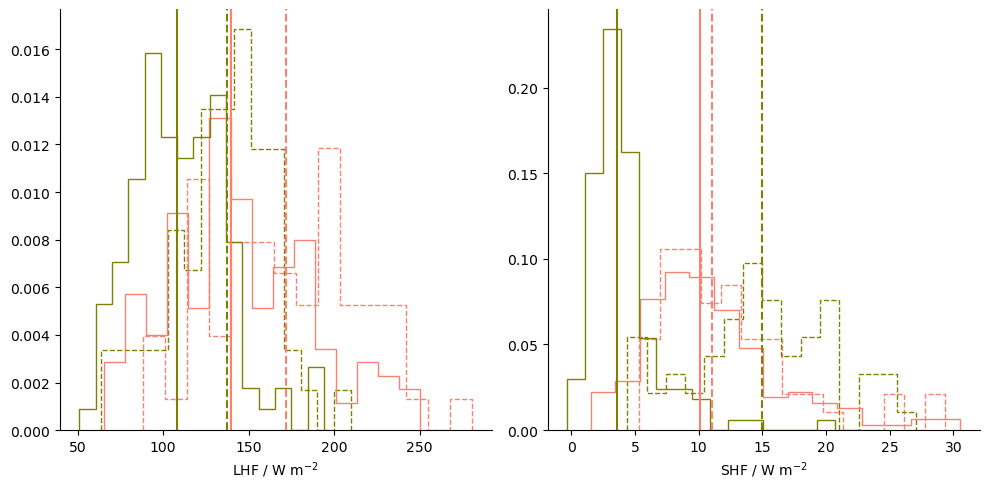

In [79]:
fig, ax = plt.subplots(1,2, figsize=(10,5))

fluxes_eu.lhf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell"]).plot.hist(ax=ax[0], bins=15, histtype="step", color="salmon", linestyle="--", density=True)
fluxes_or.lhf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell"]).plot.hist(ax=ax[0], bins=15, histtype="step", color="olive", linestyle="--", density=True)
ds_bulkFluxes.LHF_eu.resample(time_eu="1h").mean().plot.hist(ax=ax[0], bins=15, histtype="step", color="salmon", linestyle="-", density=True)
ds_bulkFluxes.LHF_or.resample(time_or="1h").mean().plot.hist(ax=ax[0], bins=15, histtype="step", color="olive", linestyle="-", density=True)

ax[0].axvline(fluxes_eu.lhf.sel(cell=[17,24,31,18,25,32,19,26,33]).mean(dim="cell").quantile(0.5).item(), color="salmon", linestyle="--")
ax[0].axvline(fluxes_or.lhf.sel(cell=[17,24,31,18,25,32,19,26,33]).mean(dim="cell").quantile(0.5).item(), color="olive",  linestyle="--")
ax[0].axvline(ds_bulkFluxes.LHF_eu.resample(time_eu="1h").mean().quantile(0.5).item(), color="salmon", linestyle="-")
ax[0].axvline(ds_bulkFluxes.LHF_or.resample(time_or="1h").mean().quantile(0.5).item(), color="olive",  linestyle="-")




fluxes_eu.shf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell"]).plot.hist(ax=ax[1], bins=15, histtype="step", color="salmon", linestyle="--", density=True)
fluxes_or.shf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell"]).plot.hist(ax=ax[1], bins=15, histtype="step", color="olive", linestyle="--", density=True)
ds_bulkFluxes.SHF_eu.resample(time_eu="1h").mean().plot.hist(ax=ax[1], bins=15, histtype="step", color="salmon", linestyle="-", density=True)
ds_bulkFluxes.SHF_or.resample(time_or="1h").mean().plot.hist(ax=ax[1], bins=15, histtype="step", color="olive", linestyle="-", density=True)

ax[1].axvline(fluxes_eu.shf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell"]).quantile(0.5, dim="time").item(), color="salmon", linestyle="--")
ax[1].axvline(fluxes_or.shf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell"]).quantile(0.5, dim="time").item(), color="olive",  linestyle="--")
ax[1].axvline(ds_bulkFluxes.SHF_eu.resample(time_eu="1h").mean().quantile(0.5, dim="time_eu").item(), color="salmon", linestyle="-")
ax[1].axvline(ds_bulkFluxes.SHF_or.resample(time_or="1h").mean().quantile(0.5, dim="time_or").item(), color="olive",  linestyle="-")

for i, lab in enumerate([r"LHF / $\rm W~m^{-2}$", r"SHF / $\rm W~m^{-2}$"]):
    ax[i].set_xlabel(lab)
    for spine in ['top', 'right']:
        ax[i].spines[spine].set_visible(False)
    

plt.tight_layout()
plt.show()

In [80]:
print(f"Uq EU = {(wind_eu.isel(height=0)*q_sfc_eu):.2f} ; Uq OR = {(wind_or.isel(height=0)*q_sfc_or):.2f}")
print(f"LHF ERA5 EU = {lhf_era5_eu.values:.2f}  ;  LHF ERA5 OR = {lhf_era5_or.values:.2f}")
print("check how the drag coefficients change!")

Uq EU = 0.12 ; Uq OR = 0.07
LHF ERA5 EU = 169.36  ;  LHF ERA5 OR = 137.51
check how the drag coefficients change!


In [81]:
import coare35vn

## ATTENTION: here output only [hsb,hlb, rhoa, Ch,Ce]

u = wind_eu.isel(height=0)
t = temp_eu.isel(height=0)
rh = rh_eu.isel(height=0)
ts = sst_eu
P = 1013.
Rs = ingr_eu.sw_global.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])
Rl = ingr_eu.lw_diff.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

output_eu = coare35vn.coare35vn(u=u.values,
                             t=t.values-273.15,
                             rh=100*rh.values,
                             ts=ts.values-273.15,
                             P=P,
                             Rs=Rs.values,
                             Rl=Rl.values, 
                             zu=50, zt=50, zq=50, lat=13, zi=600, rain=None, cp=None, sigH=None, jcool=1)




u = wind_or.isel(height=0)
t = temp_or.isel(height=0)
rh = rh_or.isel(height=0)
ts = sst_or
P = 1013.
Rs = ingr_or.sw_global.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])
Rl = ingr_or.lw_diff.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

output_or = coare35vn.coare35vn(u=u.values,
                             t=t.values-273.15,
                             rh=100*rh.values,
                             ts=ts.values-273.15,
                             P=P,
                             Rs=Rs.values,
                             Rl=Rl.values, 
                             zu=50, zt=50, zq=50, lat=13, zi=600, rain=None, cp=None, sigH=None, jcool=1)


/work/mh1498/m301248/TCO_data/COARE-algorithm/Python/COARE3.5/meteo.py:157: RuntimeWarning: invalid value encountered in power
  psi = -((1 + 0.6667*zet)**1.5 + 0.6667*(zet - 14.28)*exp(-dzet) + 8.525)


In [82]:
rho_eu, Ch_eu, Ce_eu = output_eu[0,2], output_eu[0,3] , output_eu[0,4]
rho_or, Ch_or, Ce_or = output_or[0,2], output_or[0,3] , output_or[0,4]

lhf_eu_rec, lhf_or_rec = output_eu[0,1], output_or[0,1]
shf_eu_rec, shf_or_rec = output_eu[0,0], output_or[0,0]

In [83]:
print(f"Uq EU = {(wind_eu.isel(height=0)*q_sfc_eu):.2f} ; Uq OR = {(wind_or.isel(height=0)*q_sfc_or):.2f}")
print(f"rho Ce Uq EU = {(rho_eu*Ce_eu*wind_eu.isel(height=0)*q_sfc_eu):.2f} ; rho Ce Uq OR = {(rho_or*Ce_or*wind_or.isel(height=0)*q_sfc_or):.2f}")

print(f"Ce EU = {(Ce_eu):.5f} ; Ce OR = {(Ce_or):.5f}")


print(f"LHF ERA5 EU = {lhf_era5_eu.values:.2f}  ;  LHF ERA5 EU = {lhf_era5_or.values:.2f}")
print(f"LHF EU from prof = {lhf_eu_rec:.2f}  ;  LHF ERA5 EU = {lhf_or_rec:.2f}")


Uq EU = 0.12 ; Uq OR = 0.07
rho Ce Uq EU = 0.00 ; rho Ce Uq OR = 0.00
Ce EU = 0.00113 ; Ce OR = 0.00134
LHF ERA5 EU = 169.36  ;  LHF ERA5 EU = 137.51
LHF EU from prof = 102.70  ;  LHF ERA5 EU = 69.45


In [84]:
lhf_era5_eu

<xarray.DataArray 'lhf' ()> Size: 8B
array(169.36476813)
Attributes:
    units:        W/m^2
    description:  latent heat flux into ocean

In [85]:
data = [
    [r"$\delta q$ (g/kg)", f"{(q_sfc_eu - q_eu[0]):.2f}", f"{(q_sfc_or - q_or[0]):.2f}"],
    [r"$\delta T$ (K)", f"{(sst_eu - temp_eu[0]):.2f}", f"{(sst_or - temp_or[0]):.2f}"],
    [r"Uq (m/s kg/kg)", f"{(wind_eu.isel(height=0) * q_sfc_eu):.2f}", f"{(wind_or.isel(height=0) * q_sfc_or):.2f}"],
    ["ρCeUq (g / m²s)", f"{(rho_eu * Ce_eu * wind_eu.isel(height=0) * q_sfc_eu*1e3):.2f}", f"{(rho_or * Ce_or * wind_or.isel(height=0) * q_sfc_or*1e3):.2f}"],
    [r"U dq (m/s kg/kg)", f"{(wind_eu.isel(height=0) * (q_sfc_eu - q_eu[0])):.2f}", f"{(wind_or.isel(height=0) * (q_sfc_or - q_or[0])):.2f}"],
    ["ρCeU dq (g / m²s)", f"{1e3*(rho_eu * Ce_eu * wind_eu.isel(height=0) * (q_sfc_eu - q_eu[0])):.2f}", f"{1e3*(rho_or * Ce_or * wind_or.isel(height=0) * (q_sfc_or - q_or[0])):.2f}"],
    ["Ce", f"{Ce_eu:.5f}", f"{Ce_or:.5f}"],
    ["Ch", f"{Ch_eu:.5f}", f"{Ch_or:.5f}"],
    ["","",""],
    ["","",""],
    ["LHF ERA5 (W/m²)", f"{lhf_era5_eu:.2f}", f"{lhf_era5_or:.2f}"],
    ["LHF from Prof (50m) (W/m²)", f"{lhf_eu_rec:.2f}", f"{lhf_or_rec:.2f}"],
    ["LHF bulk from ship (W/m²)", f"{ds_bulkFluxes.LHF_eu.resample(time_eu='1h').mean().quantile(0.5).item():.2f}", f"{ds_bulkFluxes.LHF_or.resample(time_or='1h').mean().quantile(0.5).item():.2f}"],
    ["SHF ERA5 (W/m²)", f"{shf_era5_eu:.2f}", f"{shf_era5_or:.2f}"],
    ["SHF from Prof (50m) (W/m²)", f"{shf_eu_rec:.2f}", f"{shf_or_rec:.2f}"],
    ["SHF bulk from ship (W/m²)", f"{ds_bulkFluxes.SHF_eu.resample(time_eu='1h').mean().quantile(0.5, dim="time_eu").item():.2f}", f"{ds_bulkFluxes.SHF_or.resample(time_or='1h').mean().quantile(0.5, dim="time_or").item():.2f}"]
]


# Create DataFrame
df = pd.DataFrame(data, columns=["Quantity", "EU", "OR"])

display(HTML(df.to_html(index=False, table_id="summary-table")))

Quantity,EU,OR
$\delta q$ (g/kg),0.01,0.01
$\delta T$ (K),1.10,1.10
Uq (m/s kg/kg),0.12,0.07
ρCeUq (g / m²s),0.16,0.11
U dq (m/s kg/kg),0.03,0.02
ρCeU dq (g / m²s),0.04,0.03
Ce,0.00113,0.00134
Ch,0.00113,0.00134
,,
,,


In [86]:
(ds_bulkFluxes.LHF_eu.resample(time_eu='1h').mean().quantile(0.5).item())

139.7074432373047

In [87]:
## LET'S DOUBLE Ce
# Ce_eu = 2*Ce_eu
# Ce_or = 2*Ce_or

In [88]:
q_out_eu = q_eu.sel(height=entrainment_levels).values
q_out_or = q_or.sel(height=entrainment_levels).values

def E(q_out, q_sfc, Vs, W): #W=0.7):
    E = ((W-1)*Vs)/((q_out/q_sfc)-W)
    return E


####  use here lhf values as done in the CD section below!  ####
# Vs_lhf_eu = (rho_eu * Ce_eu * wind_eu.isel(height=0)).values  # rho_eu *
# Vs_lhf_or = (rho_or * Ce_or * wind_or.isel(height=0)).values  # rho_or *
Vs_lhf_eu = (lhf_recShip_eu/(Lv*(q_sfc_eu - q_bl_eu))).values
Vs_lhf_or = (lhf_recShip_or/(Lv*(q_sfc_or - q_bl_or))).values

print(r"difference in $V_s EU$ with two methods = ", ((rho_eu * Ce_eu * wind_eu.isel(height=0)).values - Vs_lhf_eu)*1e3, r" $\rm g m^{-2} s^{-1}$")
print(r"difference in $V_s OR$ with two methods = ", ((rho_or * Ce_or * wind_or.isel(height=0)).values - Vs_lhf_or)*1e3, r" $\rm g m^{-2} s^{-1}$")

## compute a series of E values
E_values_eu = E(q_out_eu, q_sfc_eu, Vs_lhf_eu, W=q_bl_eu/q_sfc_eu) #q_bl_eu/q_sfc_eu)
E_values_or = E(q_out_or, q_sfc_or, Vs_lhf_or, W=q_bl_or/q_sfc_or) #q_bl_eu/q_sfc_eu)


difference in $V_s EU$ with two methods =  -1.5131026410712087  $\rm g m^{-2} s^{-1}$
difference in $V_s OR$ with two methods =  -1.5659824929032067  $\rm g m^{-2} s^{-1}$


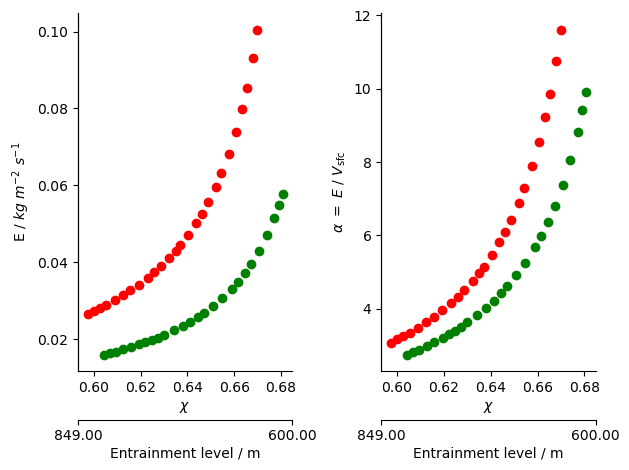

In [89]:
fig, ax = plt.subplots(1,2)

ax[0].scatter(q_out_eu/q_sfc_eu, E_values_eu, color="red", label="EUREC4A")
ax[0].scatter(q_out_or/q_sfc_or, E_values_or, color="green", label="ORCESTRA")

# ax[0].set_xlabel(r"$q_\mathrm{out}$ / $g~kg^{-1}$")
ax[0].set_xlabel(r"$\chi$")
ax[0].set_ylabel(r"E / $kg~m^{-2}~s^{-1}$")


ax[1].scatter(q_out_eu/q_sfc_eu, E_values_eu/Vs_lhf_eu, color="red", label="EUREC4A")
ax[1].scatter(q_out_or/q_sfc_or, E_values_or/Vs_lhf_or, color="green", label="ORCESTRA")

ax[1].set_xlabel(r"$\chi$")
ax[1].set_ylabel(r"$\alpha ~=~ E ~/~ V_\mathrm{sfc}$")


for x in ax:

    ax_top = x.twiny()
    ax_top.set_xlim(x.get_xlim())

    x_ticks = x.get_xticks()

    # Only keep first and last ticks
    selected_ticks = [x_ticks[0], x_ticks[-1]]
    entrainment_levels_list = np.arange(entrainment_levels.start, entrainment_levels.stop, entrainment_levels.step)
    selected_labels = [f"{entrainment_levels_list[-1]:.2f}", f"{entrainment_levels_list[0]:.2f}"]

    ax_top.set_xticks(selected_ticks)
    ax_top.set_xticklabels(selected_labels)

    ax_top.xaxis.set_ticks_position("bottom")
    ax_top.xaxis.set_label_position("bottom")
    ax_top.spines["bottom"].set_position(("outward", 35))
    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(False)
    ax_top.set_xlabel("Entrainment level / m", labelpad=2)

    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)



plt.tight_layout()
plt.show()

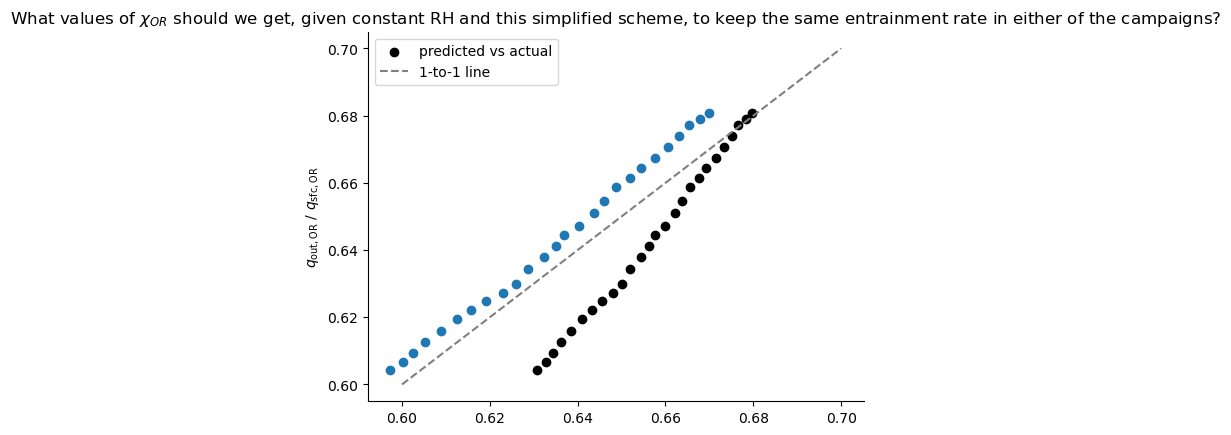

In [90]:
plt.scatter(q_out_eu/q_sfc_eu, q_out_or/q_sfc_or)

def chi_or_local(chi, W=0.7):
    return W - (Vs_lhf_or/Vs_lhf_eu)*(W - chi)

plt.scatter(chi_or_local(q_out_eu/q_sfc_eu), q_out_or/q_sfc_or, color="black", label="predicted vs actual")

## add one-to-line
x = np.linspace(0.6, 0.7, 100)
plt.plot(x, x, color="gray", linestyle="--", label="1-to-1 line")

plt.legend()

plt.ylabel(r"$q_\mathrm{out, OR}$ / $q_\mathrm{sfc, OR}$")
plt.title(r"What values of $\chi_{OR}$ should we get, given constant RH and this simplified scheme, to keep the same entrainment rate in either of the campaigns?")


for spine in ['top', 'right']:
        plt.gca().spines[spine].set_visible(False)

#### use E values in the bulk framework for potential temperature

the temperature equation in the bulk formulation takes the form
$$\theta_\mathrm{bl} = \frac{V_\mathrm{sfc} ~SST + E\theta_\mathrm{out}}{V_\mathrm{sfc}+E} + Radiation$$

In [91]:
## reduce Ch to half
# Ch_eu = 0.5*Ch_eu
# Ch_or = 0.5*Ch_or

In [92]:
## compute predicted theta and compare with average theta and its variability
theta_eu = ds_eureca_bco.theta.mean(dim="launch_time")
theta_or = ds_orcestra_bco.theta.mean(dim="launch_time")

theta_out_eu = theta_eu.sel(height=entrainment_levels).values
theta_out_or = theta_or.sel(height=entrainment_levels).values


## actual mixed-layer averaged theta
theta_bl_eu = (theta_eu.sel(height=mixed_avg_levels).mean()).values
th_var_eu   = ds_eureca_bco.theta.sel(height=mixed_avg_levels).mean(dim="height").std(dim="launch_time")/np.sqrt(n_days_eu-1)

theta_bl_or = (theta_or.sel(height=mixed_avg_levels).mean()).values
th_var_or   = ds_orcestra_bco.theta.sel(height=mixed_avg_levels).mean(dim="height").std(dim="launch_time")/np.sqrt(n_days_or-1)

# ## use Vs for sensible heat exchange
# Vs_shf_eu = ( rho_eu * Ch_eu * wind_eu.isel(height=0)).values  # rho_eu *
# Vs_shf_or = ( rho_or * Ch_or * wind_or.isel(height=0)).values  # rho_or *
Vs_shf_eu = (shf_recShip_eu/(cp*(sst_eu - theta_bl_eu))).values
Vs_shf_or = (shf_recShip_or/(cp*(sst_or - theta_bl_or))).values

print(r"difference in $V_s shf EU$ with two methods = ", ((rho_eu * Ch_eu * wind_eu.isel(height=0)).values - Vs_shf_eu)*1e3, r" $\rm g m^{-2} s^{-1}$")
print(r"difference in $V_s shf OR$ with two methods = ", ((rho_or * Ch_or * wind_or.isel(height=0)).values - Vs_shf_or)*1e3, r" $\rm g m^{-2} s^{-1}$")

theta_pred_eu = (Vs_shf_eu*sst_eu.values + E_values_eu*theta_out_eu) / (Vs_shf_eu+E_values_eu)
theta_pred_or = (Vs_shf_or*sst_or.values + E_values_or*theta_out_or) / (Vs_shf_or+E_values_or)




data = [
    [r"Vs_shf (g / m2 s)", f"{Vs_shf_eu*1e3:.2f}", f"{Vs_shf_or*1e3:.2f}"],
    [r"Vs_lhf (g / m2 s)", f"{(Vs_lhf_eu*1e3):.2f}", f"{Vs_lhf_or*1e3:.2f}"],
    ["sst - ta", f"{(sst_eu - theta_bl_eu):.2f}", f"{(sst_or - theta_bl_or):.2f}"]
]

# Create DataFrame
df = pd.DataFrame(data, columns=["Quantity", "EU", "OR"])

display(HTML(df.to_html(index=False, table_id="summary-table")))


difference in $V_s shf EU$ with two methods =  1.442142405653186  $\rm g m^{-2} s^{-1}$
difference in $V_s shf OR$ with two methods =  1.4846564706302054  $\rm g m^{-2} s^{-1}$


Quantity,EU,OR
Vs_shf (g / m2 s),5.70,2.78
Vs_lhf (g / m2 s),8.65,5.83
sst - ta,1.91,1.47


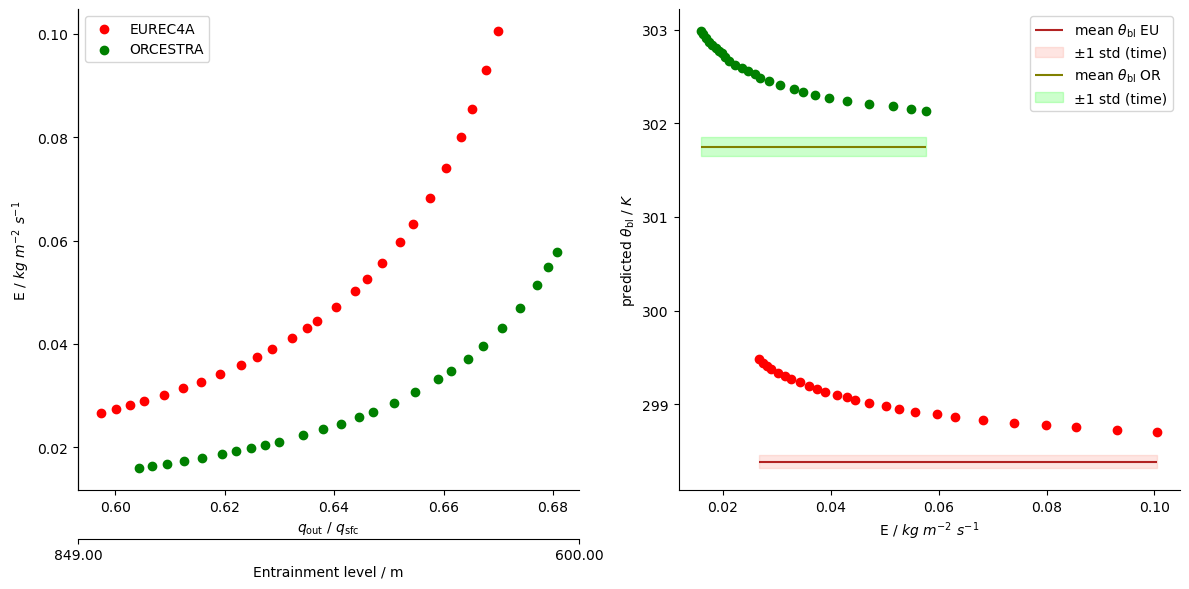

In [93]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))

#### report E for values of q_out
ax[0].scatter(q_out_eu/q_sfc_eu, E_values_eu, color="red", label="EUREC4A")
ax[0].scatter(q_out_or/q_sfc_or, E_values_or, color="green", label="ORCESTRA")

ax[0].set_xlabel(r"$q_\mathrm{out}$ / $q_\mathrm{sfc}$")
# ax[0].set_xlabel(r"$\chi$")
ax[0].set_ylabel(r"E / $kg~m^{-2}~s^{-1}$")
ax[0].legend()

ax_top = ax[0].twiny()
ax_top.set_xlim(ax[0].get_xlim())

x_ticks = ax[0].get_xticks()

# Only keep first and last ticks
selected_ticks = [x_ticks[0], x_ticks[-1]]
entrainment_levels_list = np.arange(entrainment_levels.start, entrainment_levels.stop, entrainment_levels.step)
selected_labels = [f"{entrainment_levels_list[-1]:.2f}", f"{entrainment_levels_list[0]:.2f}"]
ax_top.set_xticks(selected_ticks)
ax_top.set_xticklabels(selected_labels)
ax_top.xaxis.set_ticks_position("bottom")
ax_top.xaxis.set_label_position("bottom")
ax_top.spines["bottom"].set_position(("outward", 35))
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)
ax_top.set_xlabel("Entrainment level / m", labelpad=2)




#### compare predicted theta with actual theta

ax[1].scatter(E_values_eu, theta_pred_eu, color="red")
ax[1].scatter(E_values_or, theta_pred_or, color="green")

ax[1].hlines(theta_bl_eu, xmin=np.min(E_values_eu), xmax=np.max(E_values_eu), color="firebrick", label=r"mean $\theta_\mathrm{bl}$ EU")
ax[1].fill_between(
    [np.min(E_values_eu), np.max(E_values_eu)],
    (theta_bl_eu - th_var_eu) ,
    (theta_bl_eu + th_var_eu) ,
    color="salmon",
    alpha=0.2,
    label='±1 std (time)'
)



ax[1].hlines(theta_bl_or, xmin=np.min(E_values_or), xmax=np.max(E_values_or), color="olive", label=r"mean $\theta_\mathrm{bl}$ OR")
ax[1].fill_between(
    [np.min(E_values_or), np.max(E_values_or)],
    (theta_bl_or - th_var_or) ,
    (theta_bl_or + th_var_or) ,
    color="lime",
    alpha=0.2,
    label='±1 std (time)'
)



ax[1].set_xlabel(r"E / $kg~m^{-2}~s^{-1}$")
ax[1].set_ylabel(r"predicted $\theta_\mathrm{bl}$ / $K$")
ax[1].legend()

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)



plt.tight_layout()
plt.show()

##### include radiation: Yokoi and Katsumata 2022

In [94]:
eps = 0.295           # 0.14
oc_abs = 0.97        ## ocean absorptivity == emissivity
stefan = 5.67*1e-8
eta = 0.02
oc_alb = 0.055

def rad_terms(sw_in, lw_in, sst):
    return (eps/(1-eps))*lw_in +eps*oc_abs*stefan*(sst)**4 + ((eta/(1-eta)) + eta*(1-oc_alb))*sw_in

def R_net(sw_in, lw_in, sst, theta_bl):
    return rad_terms(sw_in, lw_in, sst) - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl)**4


### compute values

non_thBL_terms_eu = rad_terms(ingr_eu.sw_global.sel(cell=0).mean(dim="time").values, ingr_eu.lw_diff.sel(cell=0).mean(dim="time").values, sst_eu.values)
non_thBL_terms_or = rad_terms(ingr_or.sw_global.sel(cell=0).mean(dim="time").values, ingr_or.lw_diff.sel(cell=0).mean(dim="time").values, sst_or.values)


RNet_eu = R_net(ingr_eu.sw_global.sel(cell=0).mean(dim="time").values, ingr_eu.lw_diff.sel(cell=0).mean(dim="time").values, sst_eu.values, theta_bl_eu)
RNet_or = R_net(ingr_or.sw_global.sel(cell=0).mean(dim="time").values, ingr_or.lw_diff.sel(cell=0).mean(dim="time").values, sst_or.values, theta_bl_or)


radi = [
    [r"Non-theta-BL radiation (W/m²)", non_thBL_terms_eu, non_thBL_terms_or],
    [r"Net radiation (W/m²)", RNet_eu, RNet_or],
]

# Create DataFrame
df = pd.DataFrame(radi, columns=["Quantity", "EU", "OR"])

display(HTML(df.to_html(index=False, table_id="summary-table")))

Quantity,EU,OR
Non-theta-BL radiation (W/m²),310.610834,327.016758
Net radiation (W/m²),-10.069128,-8.363278


### main change here: SHF is kept fixed! Before it was changing depending on theta_bl, which is actually the unknown!

In [95]:
theta_predRad_eu = np.zeros_like(E_values_eu)
theta_predRad_or = np.zeros_like(E_values_or)

## EUREC4A DATA

for i, E in enumerate(E_values_eu):
    # Define the coefficients of the quartic: a*x^4 + b*x^3 + c*x^2 + d*x + e = 0
    coeffs = [
        0, # -((2 - eps) / (1 - eps)) * eps * stefan,  # a (x^4)
        0,                                        # b (x^3)
        0,                                        # c (x^2)
        -cp*E,  #-(cp*Vs_shf_eu +cp*E),                             # d (x^1)
        shf_recShip_eu + cp*E * theta_out_eu[i] + non_thBL_terms_eu - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_eu**4)   # e (constant). # cp*Vs_shf_eu * sst_eu.values
    ]
    
    # Solve the polynomial
    roots = np.roots(coeffs)
    
    # Filter only the fully real roots (no imaginary part)
    real_roots = roots[np.isreal(roots)]
    real_roots = np.real(real_roots) 
    
    # Now filter for physically meaningful (positive) roots
    positive_real_roots = real_roots[real_roots > 0]
    
    if len(positive_real_roots) > 0:
        theta_predRad_eu[i] = np.max(positive_real_roots)



## ORCESTRA DATA

for i, E in enumerate(E_values_or):
    # Define the coefficients of the quartic: a*x^4 + b*x^3 + c*x^2 + d*x + e = 0
    coeffs = [
        0, #-((2 - eps) / (1 - eps)) * eps * stefan,  # a (x^4)
        0,                                        # b (x^3)
        0,                                        # c (x^2)
        -cp*E, # -( cp*Vs_shf_or + cp*E),                             # d (x^1)
        shf_recShip_or + cp*E * theta_out_or[i] + non_thBL_terms_or -((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_or**4)  # e (constant).  # cp*Vs_shf_or * sst_or.values
    ]
    
    # Solve the polynomial
    roots = np.roots(coeffs)
    
    # Filter only the fully real roots (no imaginary part)
    real_roots = roots[np.isreal(roots)]
    real_roots = np.real(real_roots)
    
    # Now filter for physically meaningful (positive) roots
    positive_real_roots = real_roots[real_roots > 0]
    
    if len(positive_real_roots) > 0:
        theta_predRad_or[i] = np.max(positive_real_roots)

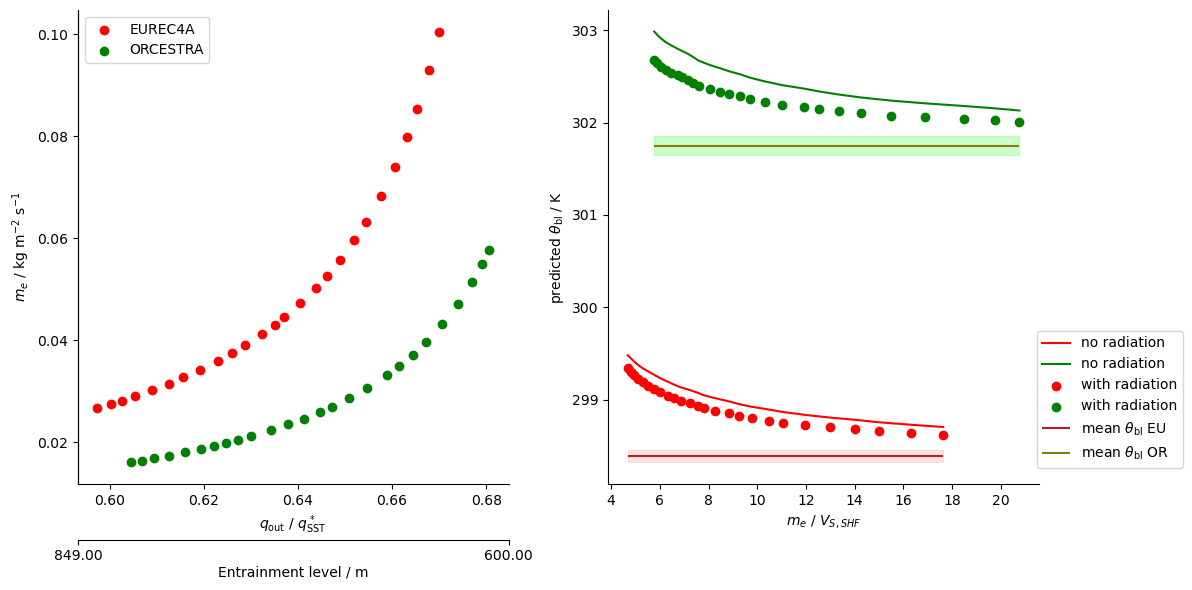

In [96]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))

#### report E for values of q_out
ax[0].scatter(q_out_eu/q_sfc_eu, E_values_eu, color="red", label="EUREC4A")
ax[0].scatter(q_out_or/q_sfc_or, E_values_or, color="green", label="ORCESTRA")

ax[0].set_xlabel(r"$q_\mathrm{out}$ / $q^*_\mathrm{SST}$")
# ax[0].set_xlabel(r"$\chi$")
ax[0].set_ylabel(r"$m_e$ / $\rm kg~m^{-2}~s^{-1}$")
ax[0].legend()

ax_top = ax[0].twiny()
ax_top.set_xlim(ax[0].get_xlim())

x_ticks = ax[0].get_xticks()

# Only keep first and last ticks
selected_ticks = [x_ticks[0], x_ticks[-1]]
entrainment_levels_list = np.arange(entrainment_levels.start, entrainment_levels.stop, entrainment_levels.step)
selected_labels = [f"{entrainment_levels_list[-1]:.2f}", f"{entrainment_levels_list[0]:.2f}"]
ax_top.set_xticks(selected_ticks)
ax_top.set_xticklabels(selected_labels)
ax_top.xaxis.set_ticks_position("bottom")
ax_top.xaxis.set_label_position("bottom")
ax_top.spines["bottom"].set_position(("outward", 40))
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)
ax_top.set_xlabel("Entrainment level / m", labelpad=2)




#### compare predicted theta with actual theta
ax[1].plot(E_values_eu/Vs_shf_eu, theta_pred_eu, color="red", label="no radiation")
ax[1].plot(E_values_or/Vs_shf_or, theta_pred_or, color="green", label="no radiation")

ax[1].scatter(E_values_eu/Vs_shf_eu, theta_predRad_eu, color="red", label="with radiation")
ax[1].scatter(E_values_or/Vs_shf_or, theta_predRad_or, color="green", label="with radiation")

ax[1].hlines(theta_bl_eu, xmin=np.min(E_values_eu/Vs_shf_eu), xmax=np.max(E_values_eu/Vs_shf_eu), color="firebrick", label=r"mean $\theta_\mathrm{bl}$ EU")
ax[1].fill_between(
    [np.min(E_values_eu/Vs_shf_eu), np.max(E_values_eu/Vs_shf_eu)],
    (theta_bl_eu - th_var_eu) ,
    (theta_bl_eu + th_var_eu) ,
    color="salmon",
    alpha=0.2
)



ax[1].hlines(theta_bl_or, xmin=np.min(E_values_or/Vs_shf_or), xmax=np.max(E_values_or/Vs_shf_or), color="olive", label=r"mean $\theta_\mathrm{bl}$ OR")
ax[1].fill_between(
    [np.min(E_values_or/Vs_shf_or), np.max(E_values_or/Vs_shf_or)],
    (theta_bl_or - th_var_or) ,
    (theta_bl_or + th_var_or) ,
    color="lime",
    alpha=0.2
)



ax[1].set_xlabel(r"$m_e$ / $V_{S,SHF}$ ") #/ $kg~m^{-2}~s^{-1}$")
ax[1].set_ylabel(r"predicted $\theta_\mathrm{bl}$ / $\rm K$")
ax[1].legend(loc="lower right", bbox_to_anchor=(1.35,0.02))

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)



plt.tight_layout()
plt.show()

#### add depth-integrated advection effect:

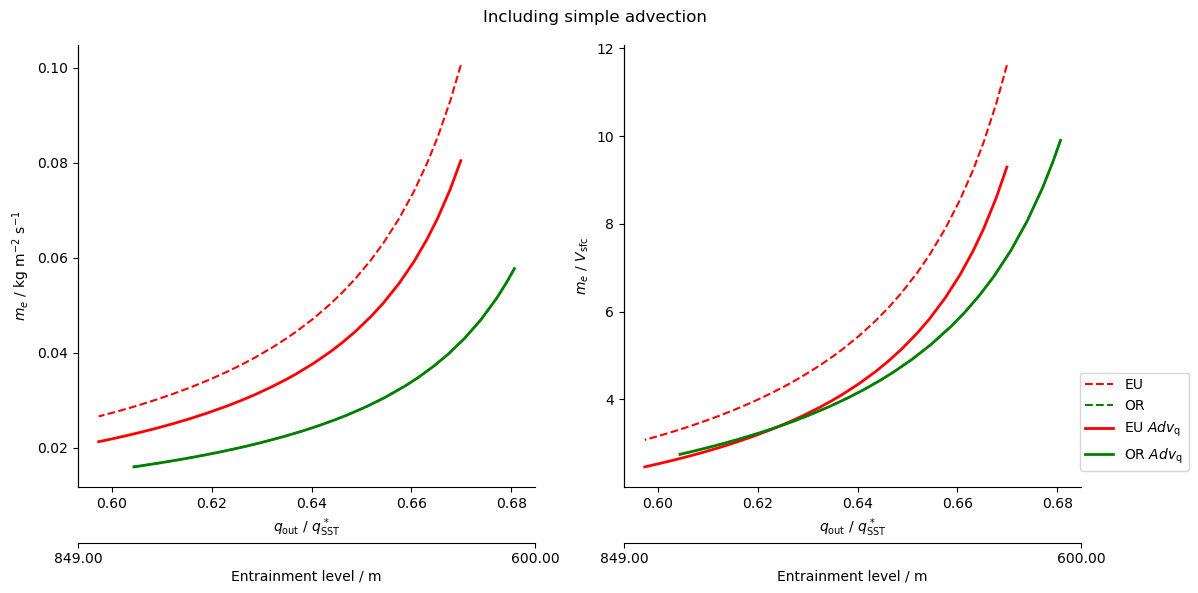

In [97]:
def E(q_out, q_sfc, Vs, Fa, h, rho_bl, W): #W=0.7):
    E = ( ((1-W)*Vs) + (h*Fa*rho_bl/q_sfc))/(W-(q_out/q_sfc) )
    return E


## compute a series of E values
E_adv_eu = E(q_out_eu, q_sfc_eu, Vs_lhf_eu, Fa_q_eu, bl_height, bl_density, W=q_bl_eu/q_sfc_eu) #q_bl_eu/q_sfc_eu)
E_adv_or = E(q_out_or, q_sfc_or, Vs_lhf_or, Fa_q_or, bl_height, bl_density, W=q_bl_or/q_sfc_or) #q_bl_or/q_sfc_or)


##### plotting #####

fig, ax = plt.subplots(1,2, figsize=(12, 6))
fig.suptitle("Including simple advection")

# no-advection values
ax[0].plot(q_out_eu/q_sfc_eu, E_values_eu, "--", color="red", label="EUREC4A")
ax[0].plot(q_out_or/q_sfc_or, E_values_or, "--", color="green", label="ORCESTRA")

# with advection
ax[0].plot(q_out_eu/q_sfc_eu, E_adv_eu, linewidth=2., color="red", label="EUREC4A adv")
ax[0].plot(q_out_or/q_sfc_or, E_adv_or, linewidth=2., color="green", label="ORCESTRA adv")

# ax[0].set_xlabel(r"$q_\mathrm{out}$ / $g~kg^{-1}$")
ax[0].set_xlabel(r"$q_\mathrm{out}$ / $q^*_\mathrm{SST}$")
ax[0].set_ylabel(r"$m_e$ / $\rm kg~m^{-2}~s^{-1}$")


# no-advection values
ax[1].plot(q_out_eu/q_sfc_eu, E_values_eu/Vs_lhf_eu, "--", color="red", label="EU")
ax[1].plot(q_out_or/q_sfc_or, E_values_or/Vs_lhf_or, "--", color="green", label="OR")

# with advection
ax[1].plot(q_out_eu/q_sfc_eu, E_adv_eu/Vs_lhf_eu, linewidth=2., color="red", label=r"EU $Adv_\mathrm{q}$")
ax[1].plot(q_out_or/q_sfc_or, E_adv_or/Vs_lhf_or, linewidth=2., color="green", label=r"OR $Adv_\mathrm{q}$")

ax[1].set_xlabel(r"$q_\mathrm{out}$ / $q^*_\mathrm{SST}$")
ax[1].set_ylabel(r"$ m_e ~/~ V_\mathrm{sfc}$")
ax[1].legend(loc="lower right", bbox_to_anchor=(1.25,0.02))


for x in ax:

    ax_top = x.twiny()
    ax_top.set_xlim(x.get_xlim())

    x_ticks = x.get_xticks()

    # Only keep first and last ticks
    selected_ticks = [x_ticks[0], x_ticks[-1]]
    entrainment_levels_list = np.arange(entrainment_levels.start, entrainment_levels.stop, entrainment_levels.step)
    selected_labels = [f"{entrainment_levels_list[-1]:.2f}", f"{entrainment_levels_list[0]:.2f}"]

    ax_top.set_xticks(selected_ticks)
    ax_top.set_xticklabels(selected_labels)

    ax_top.xaxis.set_ticks_position("bottom")
    ax_top.xaxis.set_label_position("bottom")
    ax_top.spines["bottom"].set_position(("outward", 40))
    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(False)
    ax_top.set_xlabel("Entrainment level / m", labelpad=2)

    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)



plt.tight_layout()
plt.show()

#### add a simple theta advection term:

In [98]:
theta_predRadAdv_eu = np.zeros_like(E_values_eu)
theta_predRadAdv_or = np.zeros_like(E_values_or)

## EUREC4A DATA


for i, E in enumerate(E_adv_eu):
    # Define the coefficients of the quartic: a*x^4 + b*x^3 + c*x^2 + d*x + e = 0
    coeffs = [
        0, #-((2 - eps) / (1 - eps)) * eps * stefan,              # a (x^4)
        0,                                                    # b (x^3)
        0,                                                    # c (x^2)
        -cp*E, #-(cp*Vs_shf_eu +cp*E),                                # d (x^1)
        shf_recShip_eu.item() 
        + cp*E*theta_out_eu[i] 
        + non_thBL_terms_eu -((2 - eps) / (1 - eps)) * eps * stefan*(theta_bl_eu**4)
        + cp*bl_density*bl_height*Fa_th_eu  # e (constant). # cp*Vs_shf_eu * sst_eu.values
    ]
    
    # Solve the polynomial
    roots = np.roots(coeffs)
    
    # Filter only the fully real roots (no imaginary part)
    real_roots = roots[np.isreal(roots)]
    real_roots = np.real(real_roots) 
    
    # Now filter for physically meaningful (positive) roots
    positive_real_roots = real_roots[real_roots > 0]
    
    if len(positive_real_roots) > 0:
        theta_predRadAdv_eu[i] = np.max(positive_real_roots)



## ORCESTRA DATA


for i, E in enumerate(E_adv_or):
    # Define the coefficients of the quartic: a*x^4 + b*x^3 + c*x^2 + d*x + e = 0
    coeffs = [
        0, #-((2 - eps) / (1 - eps)) * eps * stefan,               # a (x^4)
        0,                                                     # b (x^3)
        0,                                                     # c (x^2)
        -cp*E, #-(cp*Vs_shf_or + cp*E),                                # d (x^1)
        shf_recShip_or.item() 
        + cp*E * theta_out_or[i] 
        + non_thBL_terms_or -((2 - eps) / (1 - eps)) * eps * stefan*(theta_bl_or**4)
        + cp*bl_density*bl_height*Fa_th_or  # e (constant) # cp*Vs_shf_or * sst_or.values
    ]
    
    # Solve the polynomial
    roots = np.roots(coeffs)
    
    # Filter only the fully real roots (no imaginary part)
    real_roots = roots[np.isreal(roots)]
    real_roots = np.real(real_roots)
    
    # Now filter for physically meaningful (positive) roots
    positive_real_roots = real_roots[real_roots > 0]
    
    if len(positive_real_roots) > 0:
        theta_predRadAdv_or[i] = np.max(positive_real_roots)

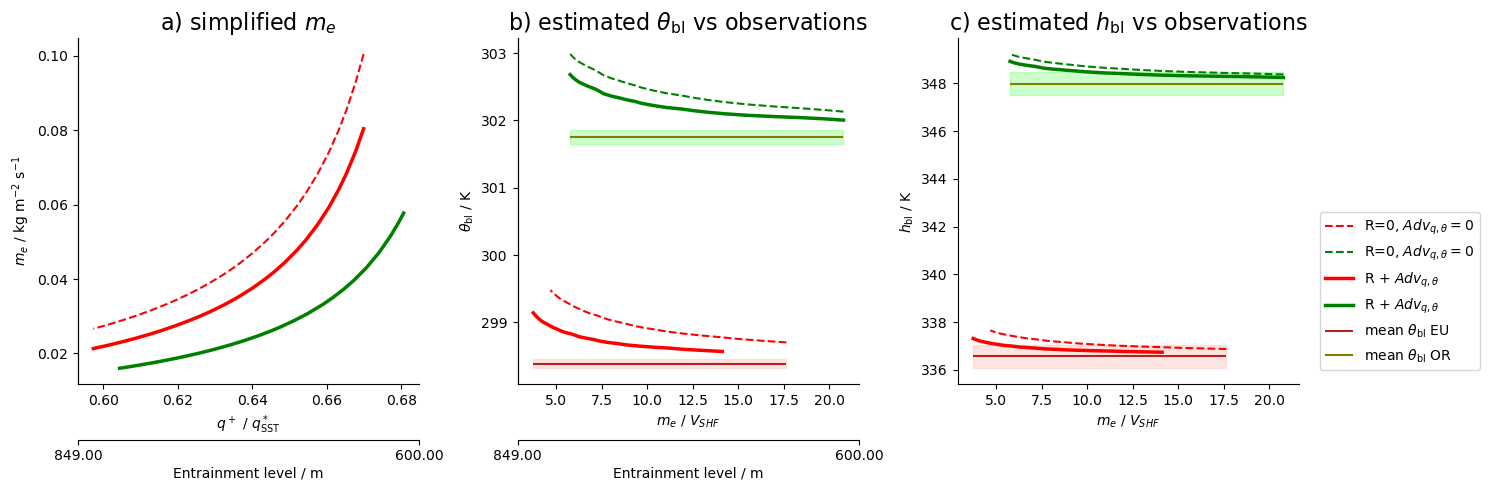

In [99]:
fig, ax = plt.subplots(1,3, figsize=(15, 5))

# no-advection values
ax[0].plot(q_out_eu/q_sfc_eu, E_values_eu, "--", color="red", label="EUREC4A")
ax[0].plot(q_out_or/q_sfc_or, E_values_or, "--", color="green", label="ORCESTRA")

# with advection
ax[0].plot(q_out_eu/q_sfc_eu, E_adv_eu, color="red", linewidth=2.5, label="EUREC4A adv")
ax[0].plot(q_out_or/q_sfc_or, E_adv_or, color="green", linewidth=2.5, label="ORCESTRA adv")



ax[0].set_xlabel(r"$q^+$ / $q^*_\mathrm{SST}$")
# ax[0].set_xlabel(r"$\chi$")
ax[0].set_ylabel(r"$m_e$ / $\rm kg~m^{-2}~s^{-1}$")
# ax[0].legend()
ax[0].set_title(r"a) simplified $m_e$" ,fontsize=16)

ax_top = ax[0].twiny()
ax_top.set_xlim(ax[0].get_xlim())

x_ticks = ax[0].get_xticks()

# Only keep first and last ticks
selected_ticks = [x_ticks[0], x_ticks[-1]]
entrainment_levels_list = np.arange(entrainment_levels.start, entrainment_levels.stop, entrainment_levels.step)
selected_labels = [f"{entrainment_levels_list[-1]:.2f}", f"{entrainment_levels_list[0]:.2f}"]
ax_top.set_xticks(selected_ticks)
ax_top.set_xticklabels(selected_labels)
ax_top.xaxis.set_ticks_position("bottom")
ax_top.xaxis.set_label_position("bottom")
ax_top.spines["bottom"].set_position(("outward", 40))
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)
ax_top.set_xlabel("Entrainment level / m", labelpad=2)




#### compare predicted theta with actual theta
ax[1].plot(E_values_eu/Vs_shf_eu, theta_pred_eu, "--", color="red", label=r"R=0, $Adv_{q,\theta}=0$")
ax[1].plot(E_values_or/Vs_shf_or, theta_pred_or, "--", color="green", label=r"R=0, $Adv_{q,\theta}=0$")

ax[1].plot(E_adv_eu/Vs_shf_eu, theta_predRadAdv_eu, color="red", linewidth=2.5, label=r"R + $Adv_{q,\theta}$")
ax[1].plot(E_adv_or/Vs_shf_or, theta_predRadAdv_or, color="green", linewidth=2.5, label=r"R + $Adv_{q,\theta}$")

ax[1].hlines(theta_bl_eu, xmin=np.min(E_adv_eu/Vs_shf_eu), xmax=np.max(E_values_eu/Vs_shf_eu), color="firebrick", label=r"mean $\theta_\mathrm{bl}$ EU")
ax[1].fill_between(
    [np.min(E_adv_eu/Vs_shf_eu), np.max(E_values_eu/Vs_shf_eu)],
    (theta_bl_eu - th_var_eu) ,
    (theta_bl_eu + th_var_eu) ,
    color="salmon",
    alpha=0.2
)



ax[1].hlines(theta_bl_or, xmin=np.min(E_adv_or/Vs_shf_or), xmax=np.max(E_values_or/Vs_shf_or), color="olive", label=r"mean $\theta_\mathrm{bl}$ OR")
ax[1].fill_between(
    [np.min(E_adv_or/Vs_shf_or), np.max(E_values_or/Vs_shf_or)],
    (theta_bl_or - th_var_or) ,
    (theta_bl_or + th_var_or) ,
    color="lime",
    alpha=0.2
)


ax[1].set_title(r"b) estimated $\theta_\mathrm{bl}$ vs observations" ,fontsize=16)
ax[1].set_xlabel(r"$m_e$ / $V_{SHF}$ ") #/ $kg~m^{-2}~s^{-1}$")
ax[1].set_ylabel(r"$\theta_\mathrm{bl}$ / $\rm K$")
# ax[1].set_title("including simple advection")

ax_top = ax[1].twiny()
ax_top.set_xlim(ax[1].get_xlim())

x_ticks = ax[1].get_xticks()

# Only keep first and last ticks
selected_ticks = [x_ticks[0], x_ticks[-1]]
entrainment_levels_list = np.arange(entrainment_levels.start, entrainment_levels.stop, entrainment_levels.step)
selected_labels = [f"{entrainment_levels_list[-1]:.2f}", f"{entrainment_levels_list[0]:.2f}"]
ax_top.set_xticks(selected_ticks)
ax_top.set_xticklabels(selected_labels)
ax_top.xaxis.set_ticks_position("bottom")
ax_top.xaxis.set_label_position("bottom")
ax_top.spines["bottom"].set_position(("outward", 40))
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)
ax_top.set_xlabel("Entrainment level / m", labelpad=2)







### in terms of MSE values
obs_mse_eu = (cp*theta_bl_eu + Lv*q_bl_eu)/cp
obs_mse_or = (cp*theta_bl_or + Lv*q_bl_or)/cp

pred_mse_eu = (cp*theta_pred_eu + Lv*q_bl_eu)/cp
pred_mse_or = (cp*theta_pred_or + Lv*q_bl_or)/cp

predRadAdv_mse_eu = (cp*theta_predRadAdv_eu + Lv*q_bl_eu)/cp
predRadAdv_mse_or = (cp*theta_predRadAdv_or + Lv*q_bl_or)/cp


ax[2].plot(E_values_eu/Vs_shf_eu, pred_mse_eu, "--", color="red", label=r"R=0, $Adv_{q,\theta}=0$")
ax[2].plot(E_values_or/Vs_shf_or, pred_mse_or, "--", color="green", label=r"R=0, $Adv_{q,\theta}=0$")

ax[2].plot(E_adv_eu/Vs_shf_eu, predRadAdv_mse_eu, color="red", linewidth=2.5, label=r"R + $Adv_{q,\theta}$")
ax[2].plot(E_adv_or/Vs_shf_or, predRadAdv_mse_or, color="green", linewidth=2.5, label=r"R + $Adv_{q,\theta}$")

ax[2].hlines(obs_mse_eu, xmin=np.min(E_adv_eu/Vs_shf_eu), xmax=np.max(E_values_eu/Vs_shf_eu), color="firebrick", label=r"mean $\theta_\mathrm{bl}$ EU")
ax[2].fill_between(
    [np.min(E_adv_eu/Vs_shf_eu), np.max(E_values_eu/Vs_shf_eu)],
    (obs_mse_eu - (th_var_eu+ (Lv/cp)*q_var_eu) ) ,
    (obs_mse_eu + (th_var_eu+ (Lv/cp)*q_var_eu)) ,
    color="salmon",
    alpha=0.2
)



ax[2].hlines(obs_mse_or, xmin=np.min(E_adv_or/Vs_shf_or), xmax=np.max(E_values_or/Vs_shf_or), color="olive", label=r"mean $\theta_\mathrm{bl}$ OR")
ax[2].fill_between(
    [np.min(E_adv_or/Vs_shf_or), np.max(E_values_or/Vs_shf_or)],
    (obs_mse_or - (th_var_or+ (Lv/cp)*q_var_or)) ,
    (obs_mse_or + (th_var_or+ (Lv/cp)*q_var_or) ) ,
    color="lime",
    alpha=0.2
)

ax[2].legend(loc="lower right", bbox_to_anchor=(1.55,0.02))
ax[2].set_ylabel(r"$h_\mathrm{bl}$ / $\rm K$")
ax[2].set_xlabel(r"$m_e$ / $V_{SHF}$ ") #/ $kg~m^{-2}~s^{-1}$")
ax[2].set_title(r"c) estimated $h_\mathrm{bl}$ vs observations" ,fontsize=16)




for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)



plt.tight_layout()
plt.show()

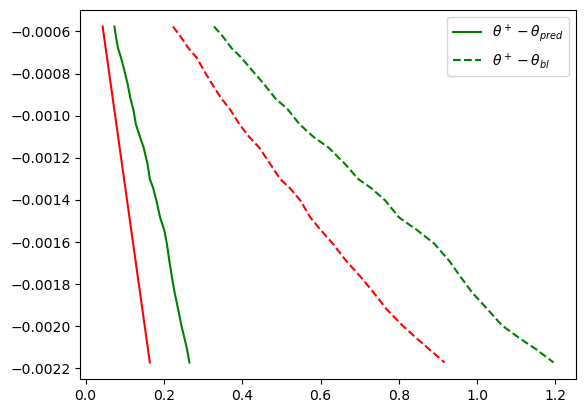

In [100]:
plt.plot(theta_out_eu - theta_predRadAdv_eu, q_out_eu - q_bl_eu, "r")
plt.plot(theta_out_eu - theta_bl_eu, q_out_eu - q_bl_eu, "r--")



plt.plot(theta_out_or - theta_predRadAdv_or, q_out_eu - q_bl_eu,  "g", label=r"$\theta^+ - \theta_{pred}$")
plt.plot(theta_out_or - theta_bl_or,  q_out_eu - q_bl_eu, "g--", label=r"$\theta^+ - \theta_{bl}$")


plt.legend()

In [101]:
print((predRadAdv_mse_eu[-1] - obs_mse_eu))
print((pred_mse_eu[-1] - obs_mse_eu))

print((predRadAdv_mse_or[-1] - obs_mse_or))
print((pred_mse_or[-1] - obs_mse_or))

0.7528057320176345
1.091498263748349
0.9301990357018326
1.2356928567453451


In [35]:
RNet_eu_final = R_net(ingr_eu.sw_global.sel(cell=0).mean(dim="time").values, ingr_eu.lw_diff.sel(cell=0).mean(dim="time").values, sst_eu.values, theta_predRadAdv_eu)
RNet_or_final = R_net(ingr_or.sw_global.sel(cell=0).mean(dim="time").values, ingr_or.lw_diff.sel(cell=0).mean(dim="time").values, sst_or.values, theta_predRadAdv_or)

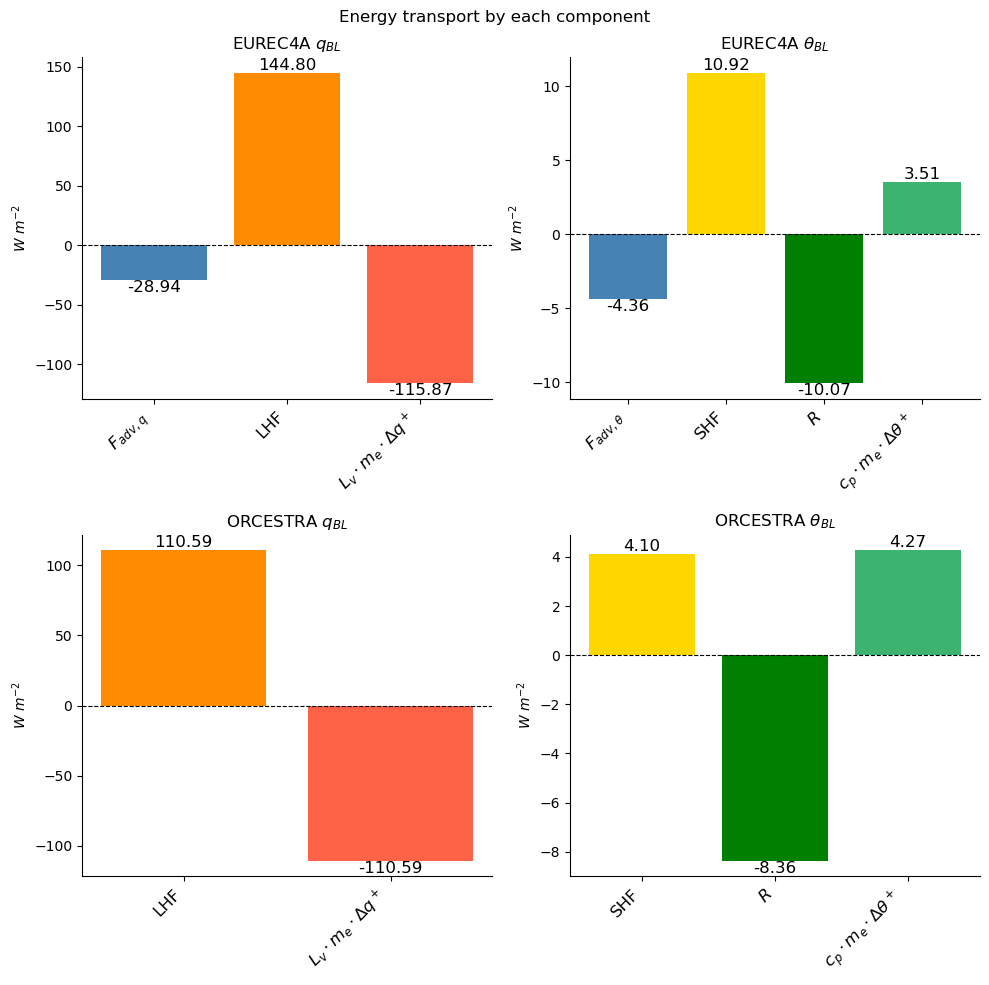

In [103]:
fig, ax = plt.subplots(2,2, figsize=(10, 10))
ax = ax.flatten()
fig.suptitle("Energy transport by each component")


labels = [
    r"$F_{adv, q}$",
    "LHF",
    r"$L_v \cdot m_e\cdot \Delta q^+$",
]

colors = [
    "steelblue",        # F_adv
    "darkorange",       # LHF
    "tomato",           # m_e · Δq+
]


terms_moisture_eu = [(bl_density*bl_height*(Lv*Fa_q_eu) )*np.ones_like(q_out_eu),      # cp*Fa_th_eu + 
         lhf_recShip_eu.values*np.ones_like(q_out_eu), 
         E_adv_eu*Lv*(q_out_eu - q_bl_eu)] 

bar_values = [terms_moisture_eu[i][0] for i in range(len(terms_moisture_eu))]

all_labels = labels #+ ["res"]

ax[0].bar(all_labels, bar_values , color=colors + ['grey'])   #+ [sum(bar_values)]
for i, v in enumerate(bar_values ):   #+ [sum(bar_values)]
    ax[0].text(i, v, f"{v:.2f}", ha='center', va='bottom' if v >= 0 else 'top', fontsize=12)
ax[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
ax[0].set_title(r"EUREC4A $q_{BL}$")
ax[0].set_ylabel(r"$W~m^{-2}$")
ax[0].set_xticks(range(len(all_labels)))
ax[0].set_xticklabels(all_labels, rotation=45, ha='right', fontsize=12)







labels = [
    r"$F_{adv, \theta}$",
    "SHF",
    r"$R$",
    r"$c_p \cdot m_e\cdot \Delta \theta^+$",
]


colors = [
    "steelblue",        # F_adv
    "gold",             # SHF
    "green",            # R
    "mediumseagreen",   # m_e · Δθ+
]

terms_th_eu = [(bl_density*bl_height*(cp*Fa_th_eu) )*np.ones_like(q_out_eu), 
         shf_recShip_eu.values*np.ones_like(q_out_eu)  ,
         RNet_eu*np.ones_like(q_out_eu),
         E_adv_eu*cp*(theta_out_eu - theta_predRadAdv_eu)] 

bar_values = [(terms_th_eu[i])[0] for i in range(len(terms_th_eu))]
# residual = shf_recShip_eu.values + (E_adv_eu*cp*(theta_out_eu - theta_predRadAdv_eu))[0] + bl_density*bl_height*(cp*Fa_th_eu) + RNet_eu_final[0]
all_labels = labels #+ ["res"]

ax[1].bar(all_labels, bar_values , color=colors + ['grey'])      #+ [residual]
for i, v in enumerate(bar_values ):      #+ [residual]
    ax[1].text(i, v, f"{v:.2f}", ha='center', va='bottom' if v >= 0 else 'top', fontsize=12)
ax[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
ax[1].set_title(r"EUREC4A $\theta_{BL}$")
ax[1].set_ylabel(r"$W~m^{-2}$")
ax[1].set_xticks(range(len(all_labels)))
ax[1].set_xticklabels(all_labels, rotation=45, ha='right', fontsize=12)






labels = [
    "LHF",
    r"$L_v \cdot m_e\cdot \Delta q^+$",
]

colors = [
    "darkorange",       # LHF
    "tomato",           # m_e · Δq+
]

terms_moisture_or = [lhf_recShip_or.values*np.ones_like(q_out_or), 
E_adv_or*Lv*(q_out_or - q_bl_or) ] 
bar_values = [terms_moisture_or[i][0]for i in range(len(terms_moisture_or))]

all_labels = labels #+ ["res"]

ax[2].bar(all_labels, bar_values , color=colors + ['grey'])  #+ [sum(bar_values)] 
for i, v in enumerate(bar_values ):   #+ [sum(bar_values)]
    ax[2].text(i, v, f"{v:.2f}", ha='center', va='bottom' if v >= 0 else 'top', fontsize=12)
ax[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
ax[2].set_title(r"ORCESTRA $q_{BL}$")
ax[2].set_ylabel(r"$W~m^{-2}$")
ax[2].set_xticks(range(len(all_labels)))
ax[2].set_xticklabels(all_labels, rotation=45, ha='right', fontsize=12)








labels = [
    "SHF",
    r"$R$",
    r"$c_p \cdot m_e\cdot \Delta \theta^+$",
]


colors = [
    "gold",             # SHF
    "green",            # R
    "mediumseagreen",   # m_e · Δθ+
]


terms_th_or = [shf_recShip_or.values*np.ones_like(q_out_or)  ,
               RNet_or*np.ones_like(q_out_or),
               E_adv_or*cp*(theta_out_or - theta_predRadAdv_or) ] 

bar_values = [(terms_th_or[i])[0] for i in range(len(terms_th_or))]
# residual = shf_recShip_or.values +  (E_adv_or*cp*(theta_out_or - theta_predRadAdv_or))[0] + RNet_or_final[0] 
all_labels = labels # + ["res"]

ax[3].bar(all_labels, bar_values , color=colors + ['grey'])   # + [residual]
for i, v in enumerate(bar_values ):   # + [residual]
    ax[3].text(i, v, f"{v:.2f}", ha='center', va='bottom' if v >= 0 else 'top', fontsize=12)
ax[3].axhline(0, color='black', linewidth=0.8, linestyle='--')
ax[3].set_title(r"ORCESTRA $\theta_{BL}$")
ax[3].set_ylabel(r"$W~m^{-2}$")
ax[3].set_xticks(range(len(all_labels)))
ax[3].set_xticklabels(all_labels, rotation=45, ha='right', fontsize=12)




for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

plt.tight_layout()

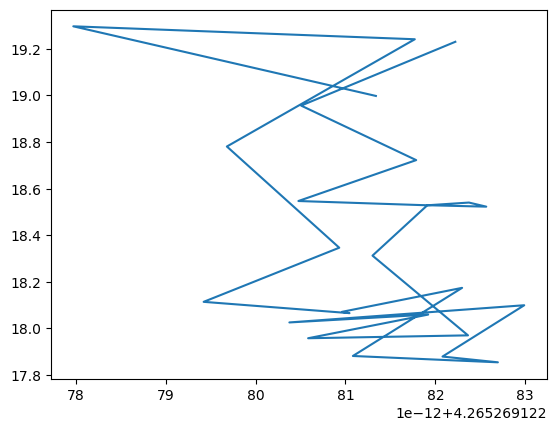

In [84]:
plt.plot(E_adv_or*cp*(theta_out_or - theta_predRadAdv_or), E_adv_or*cp*(theta_out_or - theta_bl_or))

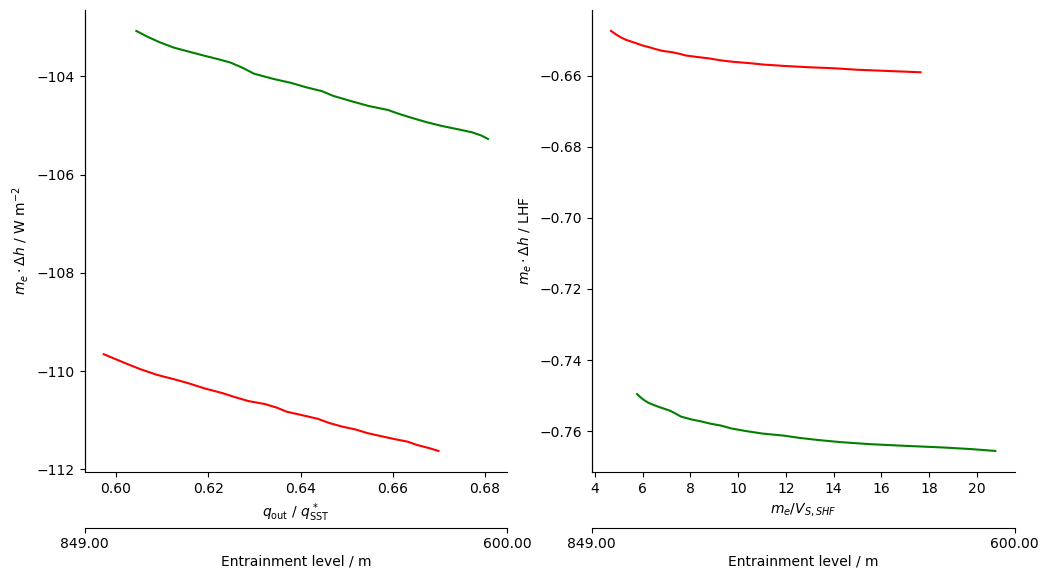

In [37]:

h_tx_eu = E_adv_eu * ( cp*(theta_out_eu - theta_predRadAdv_eu) + Lv*(q_out_eu - q_bl_eu) )
h_tx_or = E_adv_or * ( cp*(theta_out_or - theta_predRadAdv_or) + Lv*(q_out_or - q_bl_or) )


fig, ax = plt.subplots(1,2, figsize=(12, 6))
ax[0].plot(q_out_eu/q_sfc_eu, h_tx_eu, color="red", label="EUREC4A")
ax[0].plot(q_out_or/q_sfc_or, h_tx_or, color="green", label="ORCESTRA")
ax[0].set_ylabel(r"$m_e\cdot \Delta h$ / $\rm W~m^{-2}$")
ax[0].set_xlabel(r"$q_\mathrm{out}$ / $q^*_\mathrm{SST}$")







ax[1].plot(E_values_eu/Vs_shf_eu, h_tx_eu/lhf_era5_eu.values, color="red", label=r"EUREC4A")
ax[1].plot(E_values_or/Vs_shf_or, h_tx_or/lhf_era5_or.values, color="green", label=r"ORCESTRA")
ax[1].set_ylabel(r"$m_e\cdot \Delta h$ / LHF")
ax[1].set_xlabel(r"$m_e / V_{S,SHF}$ ")

for x in ax:
    ax_top = x.twiny()
    ax_top.set_xlim(x.get_xlim())
    x_ticks = x.get_xticks()

    # Only keep first and last ticks
    selected_ticks = [x_ticks[0], x_ticks[-1]]
    entrainment_levels_list = np.arange(entrainment_levels.start, entrainment_levels.stop, entrainment_levels.step)
    selected_labels = [f"{entrainment_levels_list[-1]:.2f}", f"{entrainment_levels_list[0]:.2f}"]
    ax_top.set_xticks(selected_ticks)
    ax_top.set_xticklabels(selected_labels)
    ax_top.xaxis.set_ticks_position("bottom")
    ax_top.xaxis.set_label_position("bottom")
    ax_top.spines["bottom"].set_position(("outward", 40))
    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(False)
    ax_top.set_xlabel("Entrainment level / m", labelpad=2)
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

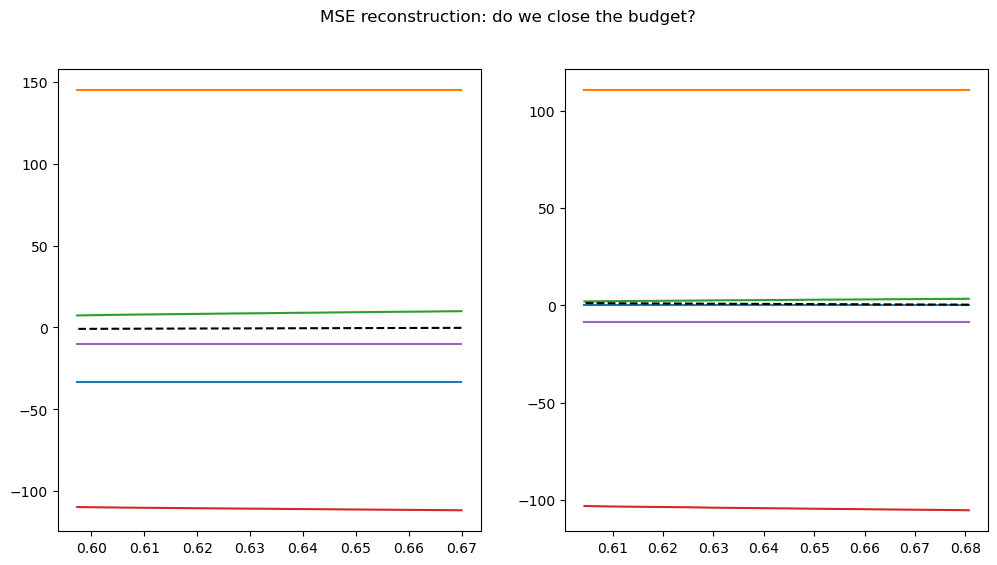

In [38]:
fig, ax = plt.subplots(1,2, figsize=(12,6))
fig.suptitle("MSE reconstruction: do we close the budget?")


terms = [(bl_density*bl_height*(cp*Fa_th_eu + Lv*Fa_q_eu) )*np.ones_like(q_out_eu),      # full advection           (r"$F_{adv}$"")
Lv*Vs_lhf_eu*(q_sfc_eu - q_bl_eu)*np.ones_like(q_out_eu),                                # reconstructed latent.    (r"LHF")
cp*Vs_shf_eu*(sst_eu.values - theta_predRadAdv_eu),                                      # reconstructed sensible.  (r"$SHF$")
E_adv_eu*( Lv*(q_out_eu - q_bl_eu) + cp*(theta_out_eu - theta_predRadAdv_eu)  ),          # contributio from entrainment (r"$m_e$")
RNet_eu*np.ones_like(q_out_eu)]                                                          # net radiation (R)

net_sum = 0
for term in terms:
    net_sum += term
    ax[0].plot(q_out_eu/q_sfc_eu, term)
ax[0].plot(q_out_eu/q_sfc_eu, net_sum, "k--")




terms = [(bl_density*bl_height*(cp*Fa_th_or + Lv*Fa_q_or) )*np.ones_like(q_out_or),      # full advection           (r"$F_{adv}$"")
Lv*Vs_lhf_or*(q_sfc_or - q_bl_or)*np.ones_like(q_out_or),                                # reconstructed latent.    (r"LHF")
cp*Vs_shf_or*(sst_or.values - theta_predRadAdv_or),                # reconstructed sensible.  (r"$SHF$")
E_adv_or*( Lv*(q_out_or - q_bl_or) + cp*(theta_out_or - theta_predRadAdv_or)  ),       # contributio from entrainment (r"$m_e$")
RNet_or*np.ones_like(q_out_or)]                                                          # net radiation (R)

net_sum = 0
for term in terms:
    net_sum += term
    ax[1].plot(q_out_or/q_sfc_or, term)
ax[1].plot(q_out_or/q_sfc_or, net_sum, "k--")


In [39]:
E_adv_eu*( Lv*(q_out_eu - q_bl_eu) + cp*(theta_out_eu - theta_predRadAdv_eu))

array([-111.62470659, -111.56473424, -111.50351661, -111.43426741,
       -111.38625562, -111.32590056, -111.2593565 , -111.18942037,
       -111.12452906, -111.05205915, -110.97046628, -110.89649734,
       -110.82497103, -110.74771771, -110.67046375, -110.60917755,
       -110.53309169, -110.44527159, -110.35181522, -110.24462732,
       -110.16232376, -110.07519188, -109.96258739, -109.86178343,
       -109.76454469, -109.65615496])

#### constant W or use the right quantity to compute entrainment?

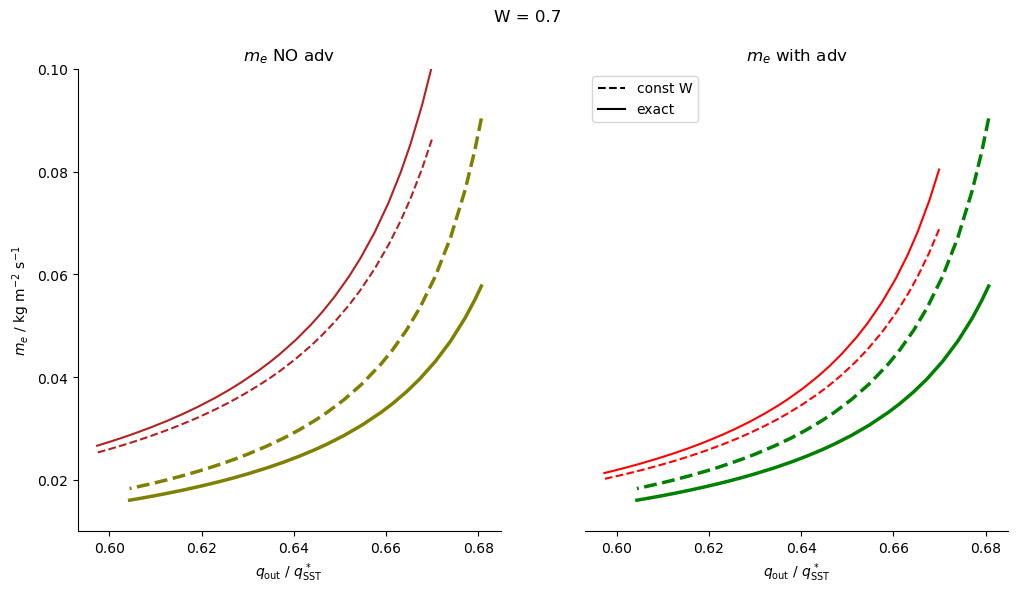

In [40]:
W_inUse = 0.7
def E_local(q_out, q_sfc, Vs, W): #W=0.7):
    E = ((W-1)*Vs)/((q_out/q_sfc)-W)
    return E


## compute a series of E values
E_conW_eu = E_local(q_out_eu, q_sfc_eu, Vs_lhf_eu, W=W_inUse) #q_bl_eu/q_sfc_eu)
E_conW_or = E_local(q_out_or, q_sfc_or, Vs_lhf_or, W=W_inUse) #q_bl_eu/q_sfc_eu)

E_exact_eu = E_local(q_out_eu, q_sfc_eu, Vs_lhf_eu, W=q_bl_eu/q_sfc_eu)
E_exact_or = E_local(q_out_or, q_sfc_or, Vs_lhf_or, W=q_bl_or/q_sfc_or)



def E_adv(q_out, q_sfc, Vs, Fa, h, rho_bl, W): #W=0.7):
    E = ( ((1-W)*Vs) + (h*Fa*rho_bl/q_sfc))/(W-(q_out/q_sfc) )
    return E

E_advConW_eu = E_adv(q_out_eu, q_sfc_eu, Vs_lhf_eu, Fa_q_eu, bl_height, bl_density, W=W_inUse) #q_bl_eu/q_sfc_eu)
E_advConW_or = E_adv(q_out_or, q_sfc_or, Vs_lhf_or, Fa_q_or, bl_height, bl_density, W=W_inUse) #q_bl_or/q_sfc_or)

E_advExact_eu = E_adv(q_out_eu, q_sfc_eu, Vs_lhf_eu, Fa_q_eu, bl_height, bl_density, W=q_bl_eu/q_sfc_eu)
E_advExact_or = E_adv(q_out_or, q_sfc_or, Vs_lhf_or, Fa_q_or, bl_height, bl_density, W=q_bl_or/q_sfc_or)




fig, ax = plt.subplots(1,2, figsize=(12,6))
fig.suptitle(f"W = {W_inUse}")

# no-advection values
ax[0].plot(q_out_eu/q_sfc_eu, E_conW_eu, "--", color="firebrick", label="EU conW")
ax[0].plot(q_out_eu/q_sfc_eu, E_exact_eu,  color="firebrick", label="EU exact")

ax[0].plot(q_out_or/q_sfc_or, E_conW_or, "--", color="olive", linewidth=2.5, label="OR conW")
ax[0].plot(q_out_or/q_sfc_or, E_exact_or, color="olive", linewidth=2.5, label="OR exact")
ax[0].set_title(r"$m_e$ NO adv")
ax[0].set_ylabel(r"$m_e$ / $\rm kg~m^{-2}~s^{-1}$")



# with advection
ax[1].plot(q_out_eu/q_sfc_eu, E_advConW_eu, "--", color="red", label="EUREC4A")
ax[1].plot(q_out_eu/q_sfc_eu, E_advExact_eu,  color="red", label="ORCESTRA")

ax[1].plot(q_out_or/q_sfc_or, E_advConW_or, "--", color="green", linewidth=2.5, label="EUREC4A adv")
ax[1].plot(q_out_or/q_sfc_or, E_advExact_or, color="green", linewidth=2.5, label="ORCESTRA adv")
ax[1].set_title(r"$m_e$ with adv")

ax[1].spines["left"].set_visible(False)
ax[1].yaxis.set_visible(False)

for x in ax:
    x.set_xlabel(r"$q_\mathrm{out}$ / $q^*_\mathrm{SST}$")
    x.set_ylim([0.01, 0.1])
    for spine in ['top', 'right']:
            x.spines[spine].set_visible(False)

const_w = mlines.Line2D([], [], color='black', linestyle='--', label='const W')
exact   = mlines.Line2D([], [], color='black', linestyle='-',  label='exact')

ax[1].legend(handles=[const_w, exact])



### how does the balances change if I am to use $SHF , LHF |_{EU} = SHF , LHF |_{OR}$

#### show sensitivity to BL height parameter


In [41]:

blh_samples = [600, 700, 800]
entr_levs_sens = [slice(blh+100, blh+300) for blh in blh_samples]

q_out_eu_sens = [q_eu.sel(height=levs).values for levs in entr_levs_sens]
q_out_or_sens = [q_or.sel(height=levs).values for levs in entr_levs_sens]

theta_out_eu_sens = [theta_eu.sel(height=levs).values for levs in entr_levs_sens]
theta_out_or_sens = [theta_or.sel(height=levs).values for levs in entr_levs_sens]


## CAREFUL WITH W constant HERE
def E(q_out, q_sfc, Vs, Fa, h, rho_bl, W=0.75):
    E = (((1-W)*Vs) + (h*Fa*rho_bl/q_sfc))/(W-(q_out/q_sfc))
    return E  # fixed indentation


E_sens_eu = [E(q_out, q_sfc_eu, Vs_lhf_eu, Fa_q_eu, blh_samples[i], bl_density) for i, q_out in enumerate(q_out_eu_sens)]
E_sens_or = [E(q_out, q_sfc_or, Vs_lhf_or, Fa_q_or, blh_samples[i], bl_density) for i, q_out in enumerate(q_out_or_sens)]

theta_pred_sens_eu = []
theta_pred_sens_or = []


def theta_simple_scheme(E_values, Vs_shf, sst, theta_out, non_thBL_terms, blh, Fa_th):
    theta_pred = np.zeros_like(E_values)
    for i, (E, th_out) in enumerate(zip(E_values, theta_out)):  # fixed: indentation + enumerate
        coeffs = [
            -((2 - eps) / (1 - eps)) * eps * stefan,
            0,
            0,
            -(cp*Vs_shf + cp*E),
            cp*Vs_shf * sst + cp*E * th_out + non_thBL_terms + cp*bl_density*blh*Fa_th
        ]
        roots = np.roots(coeffs)
        real_roots = roots[np.isreal(roots)]
        real_roots = np.real(real_roots)
        positive_real_roots = real_roots[real_roots > 0]
        if len(positive_real_roots) > 0:
            theta_pred[i] = np.max(positive_real_roots)
    return theta_pred  # fixed indentation


# Fixed: use enumerate and pass blh_samples[i] as scalar
for i, (E_list_eu, th_list_eu) in enumerate(zip(E_sens_eu, theta_out_eu_sens)):
    theta_pred_sens_eu.append(
        theta_simple_scheme(E_list_eu, Vs_shf_eu, sst_eu.values, th_list_eu,
                            non_thBL_terms_eu, blh_samples[i], Fa_q_eu)
    )

for i, (E_list_or, th_list_or) in enumerate(zip(E_sens_or, theta_out_or_sens)):
    theta_pred_sens_or.append(
        theta_simple_scheme(E_list_or, Vs_shf_or, sst_or.values, th_list_or,
                            non_thBL_terms_or, blh_samples[i], Fa_q_or)
    )

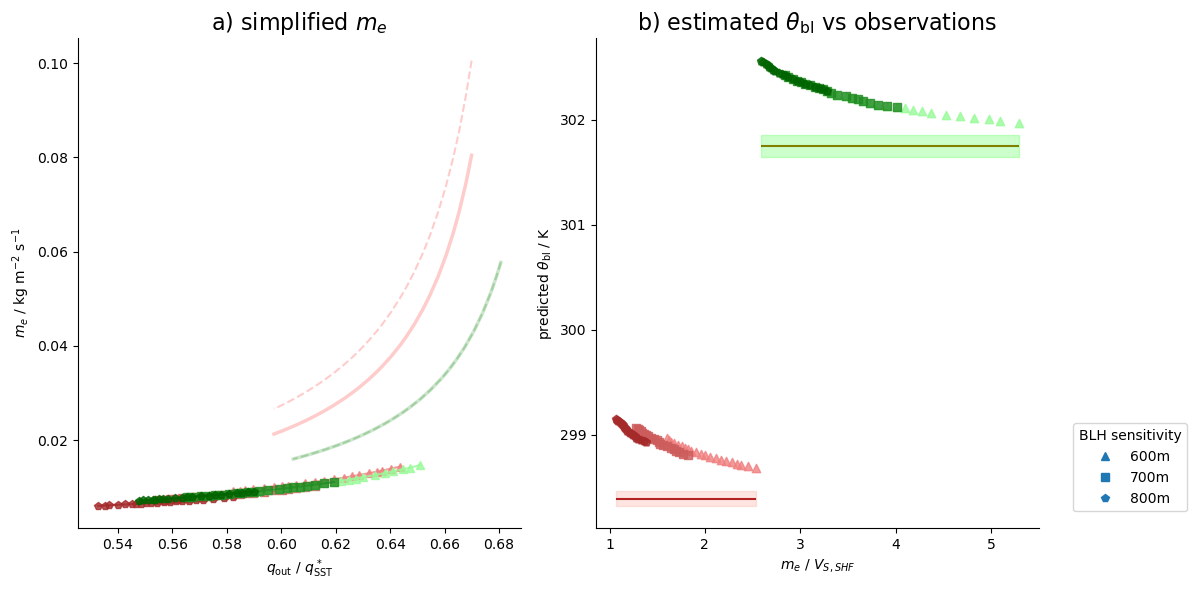

In [42]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
import matplotlib.lines as mlines

legend_elements = [
    mlines.Line2D([], [], marker="^", linestyle="None", label=f"{blh_samples[0]}m"),
    mlines.Line2D([], [], marker="s", linestyle="None", label=f"{blh_samples[1]}m"),
    mlines.Line2D([], [], marker="p", linestyle="None", label=f"{blh_samples[2]}m"),
]

#### BLH = 500m ####
# no-advection values
ax[0].plot(q_out_eu/q_sfc_eu, E_values_eu, "--", color="red", alpha=0.2, label=r"EU, R=0, $Adv_{q,\theta}=0$")
ax[0].plot(q_out_or/q_sfc_or, E_values_or, "--", color="green", alpha=0.2, label=r"OR, R=0, $Adv_{q,\theta}=0$")

# with advection
ax[0].plot(q_out_eu/q_sfc_eu, E_adv_eu, color="red", linewidth=2.5, alpha=0.2, label=r"EU, R + $Adv_{q,\theta}$")
ax[0].plot(q_out_or/q_sfc_or, E_adv_or, color="green", linewidth=2.5, alpha=0.2, label=r"OR, R + $Adv_{q,\theta}$")
#### BLH = 500m ####


####### varying BLH #######
ax[0].plot(q_out_eu_sens[0]/q_sfc_eu, E_sens_eu[0], marker="^", color="lightcoral", alpha=0.8) #, label="EUREC4A")
ax[0].plot(q_out_eu_sens[1]/q_sfc_eu, E_sens_eu[1], marker="s", color="indianred", alpha=0.8) #, label="EUREC4A")
ax[0].plot(q_out_eu_sens[2]/q_sfc_eu, E_sens_eu[2], marker="p", color="brown", alpha=0.8) #, label="EUREC4A")

ax[0].plot(q_out_or_sens[0]/q_sfc_or, E_sens_or[0], marker="^", color="palegreen", alpha=0.8) #, label="EUREC4A")
ax[0].plot(q_out_or_sens[1]/q_sfc_or, E_sens_or[1], marker="s", color="forestgreen", alpha=0.8) #, label="EUREC4A")
ax[0].plot(q_out_or_sens[2]/q_sfc_or, E_sens_or[2], marker="p", color="darkgreen", alpha=0.8) #, label="EUREC4A")
####### varying BLH #######

ax[0].set_xlabel(r"$q_\mathrm{out}$ / $q^*_\mathrm{SST}$")
ax[0].set_ylabel(r"$m_e$ / $\rm kg~m^{-2}~s^{-1}$")
ax[0].set_title(r"a) simplified $m_e$" ,fontsize=16)
# ax[0].legend(loc="upper left", title="BLH sensitivity")




#### compare predicted theta with actual theta

# #### BLH = 500m ####
# ax[1].plot(E_values_eu/Vs_shf_eu, theta_pred_eu, "--", color="red", alpha=0.3, label=r"R=0, $Adv_{q,\theta}=0$")
# ax[1].plot(E_values_or/Vs_shf_or, theta_pred_or, "--", color="green", alpha=0.3,label=r"R=0, $Adv_{q,\theta}=0$")

# ax[1].plot(E_values_eu/Vs_shf_eu, theta_predRadAdv_eu, color="red", linewidth=2.5, alpha=0.3, label=r"R + $Adv_{q,\theta}$")
# ax[1].plot(E_values_or/Vs_shf_or, theta_predRadAdv_or, color="green", linewidth=2.5, alpha=0.3, label=r"R + $Adv_{q,\theta}$")
#### BLH = 500m ####

####### varying BLH #######
ax[1].scatter(E_sens_eu[0]/Vs_shf_eu, theta_pred_sens_eu[0], marker="^", color="lightcoral", alpha=0.8) #, label=f"{blh_samples[0]}m")
ax[1].scatter(E_sens_eu[1]/Vs_shf_eu, theta_pred_sens_eu[1], marker="s", color="indianred", alpha=0.8) #, label=f"{blh_samples[1]}m")
ax[1].scatter(E_sens_eu[2]/Vs_shf_eu, theta_pred_sens_eu[2], marker="p", color="brown", alpha=0.8) #, label=f"{blh_samples[2]}m")

ax[1].scatter(E_sens_or[0]/Vs_shf_or, theta_pred_sens_or[0], marker="^", color="palegreen", alpha=0.8) #, label=f"{blh_samples[0]}m")
ax[1].scatter(E_sens_or[1]/Vs_shf_or, theta_pred_sens_or[1], marker="s", color="forestgreen", alpha=0.8) #, label=f"{blh_samples[1]}m")
ax[1].scatter(E_sens_or[2]/Vs_shf_or, theta_pred_sens_or[2], marker="p", color="darkgreen", alpha=0.8) #, label=f"{blh_samples[2]}m")
####### varying BLH #######






ax[1].hlines(theta_bl_eu, xmin=np.min(E_sens_eu[2]/Vs_shf_eu), xmax=np.max(E_sens_eu[0]/Vs_shf_eu), color="firebrick", label=r"mean $\theta_\mathrm{bl}$ EU")
ax[1].fill_between(
    [np.min(E_sens_eu[2]/Vs_shf_eu), np.max(E_sens_eu[0]/Vs_shf_eu)],
    (theta_bl_eu - th_var_eu) ,
    (theta_bl_eu + th_var_eu) ,
    color="salmon",
    alpha=0.2
)



ax[1].hlines(theta_bl_or, xmin=np.min(E_sens_or[2]/Vs_shf_or), xmax=np.max(E_sens_or[0]/Vs_shf_or), color="olive", label=r"mean $\theta_\mathrm{bl}$ OR")
ax[1].fill_between(
    [np.min(E_sens_or[2]/Vs_shf_or), np.max(E_sens_or[0]/Vs_shf_or)],
    (theta_bl_or - th_var_or) ,
    (theta_bl_or + th_var_or) ,
    color="lime",
    alpha=0.2
)


ax[1].set_title(r"b) estimated $\theta_\mathrm{bl}$ vs observations" ,fontsize=16)
ax[1].set_xlabel(r"$m_e$ / $V_{S,SHF}$ ") #/ $kg~m^{-2}~s^{-1}$")
ax[1].set_ylabel(r"predicted $\theta_\mathrm{bl}$ / $\rm K$")
# ax[1].set_title("including simple advection")
ax[1].legend(loc="lower right", bbox_to_anchor=(1.35,0.02), handles=legend_elements, title="BLH sensitivity")

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)



plt.tight_layout()
plt.show()

### What if we treat E as convective downdraft? Meaning that now

$$ E = D = \frac{\left( 1 - W_\mathrm{sfc} \right) \cdot V_\mathrm{sfc}}{W - q^*_{cd}/q^*_\mathrm{sfc}} $$

In [113]:
downdraft_levels_eu = slice(1200, 1700)
downdraft_levels_or = slice(2500, 3000)

In [18]:
# function to invert is
# h_cd / cp = \theta_cd + Lv/cp * qs(\theta_cd)

def temp_from_h(theta, p, h_cd, Lv, cp):
    es = 6.1121 * np.exp(17.502 * (theta*(p/1000.)**(Rd/cp)-273.15) / (240.97 + (theta*(p/1000.)**(Rd/cp)-273.15)))
    denominator = p - 0.378 * es * (1.0007 + p * 3.46e-6)
    
    return h_cd/cp - theta - (Lv / cp) * 0.622 * es * (1.0007 + p * 3.46e-6) / denominator


## data to use
h_cd_eu = (cp*ds_eureca_bco["ta"] + Lv*ds_eureca_bco["mr"] + g*ds_eureca_bco.height).mean(dim="launch_time").sel(height=downdraft_levels_eu)
h_cd_or = (cp*ds_orcestra_bco["ta"] + Lv*ds_orcestra_bco["mr"] + g*ds_orcestra_bco.height).mean(dim="launch_time").sel(height=downdraft_levels_or)

p_cd_eu = ds_eureca_bco["p"].mean(dim="launch_time").sel(height=downdraft_levels_eu)
p_cd_or = ds_orcestra_bco["p"].mean(dim="launch_time").sel(height=downdraft_levels_or)

p_sfc_eu = 1e5*np.ones_like(p_cd_eu.values)
p_sfc_or = 1e5*np.ones_like(p_cd_or.values)

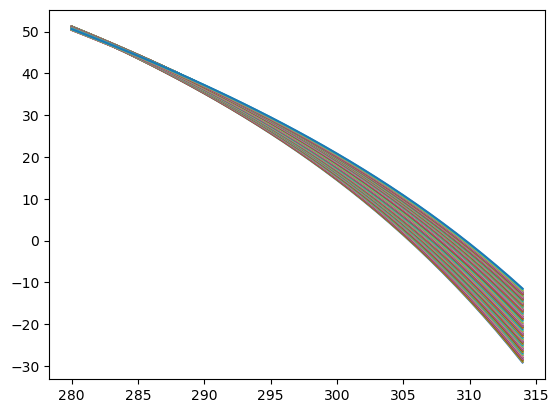

In [21]:
t = np.arange(280, 315)
vect_temp = np.vectorize(temp_from_h)

for x in zip(p_cd_or, h_cd_or):
    function_res = vect_temp(t, p=x[0]/100., h_cd=x[1], Lv=Lv, cp=cp)
    plt.plot(t, function_res)


In [23]:
def f_eu(t):
    return temp_from_h(t, p=p_cd_eu[0]/100., h_cd=h_cd_eu[0], Lv=Lv, cp=cp)

def f_or(t):
    return temp_from_h(t, p=p_cd_or[0]/100., h_cd=h_cd_or[0], Lv=Lv, cp=cp)



from scipy.optimize import root_scalar

try:
    sol_or = root_scalar(f_or, bracket=[280, 350], method='brentq')
    
    if sol_or.converged:
        t_root = sol_or.root
        print(f"Root found at theta = {t_root:.4f} K")
    else:
        print("Root finding did not converge.")
except Exception as e:
    print(f"Error: {e}")

Root found at theta = 305.4801 K


In [25]:
305.48*(p_cd_or[0]/100000.)**(0.287)

<xarray.DataArray 'p' ()> Size: 4B
array(287.09357, dtype=float32)
Coordinates:
    height   float32 4B 2e+03
Attributes:
    cell_methods:   height: interpolated (interval: 10 m)
    description:    Air Pressure during flight
    long_name:      pressure
    standard_name:  air_pressure
    units:          Pa

##### extend to arrays of values

In [24]:
# Wrap the root-finding in a vectorized function
def find_root_for_pair(p, h):
    def f(t):
        return temp_from_h(t, p=p, h_cd=h, Lv=Lv, cp=cp)
    
    try:
        sol = root_scalar(f, bracket=[280, 350], method='brentq')
        return sol.root if sol.converged else np.nan
    except:
        return np.nan

# Vectorize the function
vectorized_root = np.vectorize(find_root_for_pair)



In [118]:
# Apply find_root_for_pair(p, h) to arrays
thetaD_eu = vectorized_root(p_sfc_eu / 100., h_cd_eu.values)
thetaD_or = vectorized_root(p_sfc_or / 100., h_cd_or.values)

tempD_eu = thetaD_eu*((1000./(p_cd_eu/100.).values)**(-Rd/cp))
tempD_or = thetaD_or*((1000./(p_cd_or/100.).values)**(-Rd/cp))


# from the thetaD retrievals,
# I compute absolute temperature to then compute q_sat at the downdraft level
qSat_out_eu = meteo.qsea(  tempD_eu-273.15 , p_cd_eu/100 )/1000.    # output of function is g / kg  
qSat_out_or = meteo.qsea(  tempD_or-273.15 , p_cd_or/100 )/1000.    # output of function is g / kg  

In [123]:
'''
g = 9.81   # m/s2

method = input("what method of saturation calculation? direct or yk ")

while method not in ["direct", "yk"]:
    method = input("no matching method, try again")
if method == "direct":
    ## direct formulation : use local saturation vaue obtained by just dividing by RH
    qSat_out_eu = (q_eu.sel(height=downdraft_levels_eu).values*1e3)/rh_eu.sel(height=downdraft_levels_eu).values
    qSat_out_or = (q_or.sel(height=downdraft_levels_or).values*1e3)/rh_or.sel(height=downdraft_levels_or).values

elif method == "yk":
    ref_BL_press = 975.      ## hPa
    ## Yokoi and Katsumata
    T_satD_eu = (ds_eureca_bco.ta + g*ds_eureca_bco.ta.height/cp).mean(dim="launch_time")
    qSat_out_eu = meteo.qsea(  T_satD_eu.sel(height=downdraft_levels_eu) -273.15 , ref_BL_press  )     #press_eu.sel(height=downdraft_levels_eu)

    T_satD_or = (ds_orcestra_bco.ta + g*ds_orcestra_bco.ta.height/cp).mean(dim="launch_time")
    qSat_out_or = meteo.qsea(  T_satD_or.sel(height=downdraft_levels_or) -273.15 , ref_BL_press  )     #press_eu.sel(height=downdraft_levels_or)
    
'''

def D_here(q_out, q_sfc, Vs, W):
    E = ((W-1)*Vs)/((q_out/q_sfc)-W)
    return E


###### bulk fluxes from one week of ship measurements
ds_bulkFluxes = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/Bulk_fluxes_from_Meteor.nc")
lhf_recShip_eu = ds_bulkFluxes.LHF_eu.mean(dim="time_eu")
lhf_recShip_or = ds_bulkFluxes.LHF_or.mean(dim="time_or")
shf_recShip_eu = ds_bulkFluxes.SHF_eu.mean(dim="time_eu")
shf_recShip_or = ds_bulkFluxes.SHF_or.mean(dim="time_or")


# Vs_lhf_eu = (rho_eu * Ce_eu * wind_eu.isel(height=0)).values  # rho_eu * 
# Vs_lhf_or = (rho_or * Ce_or * wind_or.isel(height=0)).values  # rho_or * 
Vs_lhf_eu = (lhf_recShip_eu/(Lv*(q_sfc_eu - q_bl_eu))).values
Vs_lhf_or = (lhf_recShip_or/(Lv*(q_sfc_or - q_bl_or))).values


## compute a series of E values
D_values_eu = D_here(qSat_out_eu, q_sfc_eu, Vs_lhf_eu, W = q_bl_eu/q_sfc_eu)
D_values_or = D_here(qSat_out_or, q_sfc_or, Vs_lhf_or, W = q_bl_or/q_sfc_or)

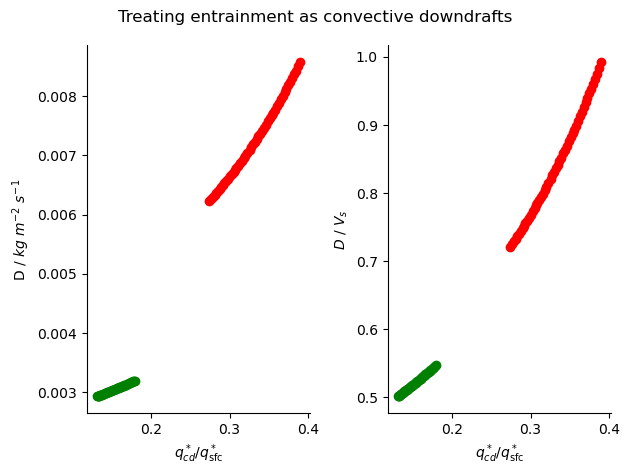

In [125]:
fig, ax = plt.subplots(1,2)
fig.suptitle("Treating entrainment as convective downdrafts")

ax[0].scatter(qSat_out_eu/q_sfc_eu, D_values_eu, color="red", label="EUREC4A")
ax[0].scatter(qSat_out_or/q_sfc_or, D_values_or, color="green", label="ORCESTRA")

# ax[0].set_xlabel(r"$q_\mathrm{out}$ / $g~kg^{-1}$")
ax[0].set_xlabel(r"$q^*_{cd}/q^*_\mathrm{sfc}$")
ax[0].set_ylabel(r"D / $kg~m^{-2}~s^{-1}$")


ax[1].scatter(qSat_out_eu/q_sfc_eu, D_values_eu/Vs_lhf_eu, color="red", label="EUREC4A")
ax[1].scatter(qSat_out_or/q_sfc_or, D_values_or/Vs_lhf_or, color="green", label="ORCESTRA")

ax[1].set_xlabel(r"$q^*_{cd}/q^*_\mathrm{sfc}$")
ax[1].set_ylabel(r"$D ~ / ~ V_s $")


for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)



plt.tight_layout()
plt.show()

In [127]:
## compute predicted theta and compare with average theta and its variability
theta_eu = ds_eureca_bco.theta.mean(dim="launch_time")
theta_or = ds_orcestra_bco.theta.mean(dim="launch_time")
'''
thetaD_out_eu = theta_eu.sel(height=downdraft_levels_eu).values
thetaD_out_or = theta_or.sel(height=downdraft_levels_or).values

using 
thetaD_eu
thetaD_or
calculated as in Yokoi and Katsumata 2022
'''

## use Vs for sensible heat exchange
# Vs_shf_eu = ( rho_eu * Ch_eu * wind_eu.isel(height=0)).values   
# Vs_shf_or = ( rho_or * Ch_or * wind_or.isel(height=0)).values  
Vs_shf_eu = ( shf_recShip_eu / (cp*(sst_eu - theta_bl_eu) )).values   
Vs_shf_or = ( shf_recShip_or / (cp*(sst_or - theta_bl_or) )).values 

thetaD_pred_eu = (Vs_shf_eu*sst_eu.values + D_values_eu*thetaD_eu) / (Vs_shf_eu+D_values_eu)
thetaD_pred_or = (Vs_shf_or*sst_or.values + D_values_or*thetaD_or) / (Vs_shf_or+D_values_or)


## actual mixed-layer averaged theta
theta_bl_eu = theta_eu.sel(height=mixed_avg_levels).mean()
th_var_eu   = ds_eureca_bco.theta.sel(height=mixed_avg_levels).mean(dim="height").std(dim="launch_time")

theta_bl_or = theta_or.sel(height=mixed_avg_levels).mean()
th_var_or   = ds_orcestra_bco.theta.sel(height=mixed_avg_levels).mean(dim="height").std(dim="launch_time")


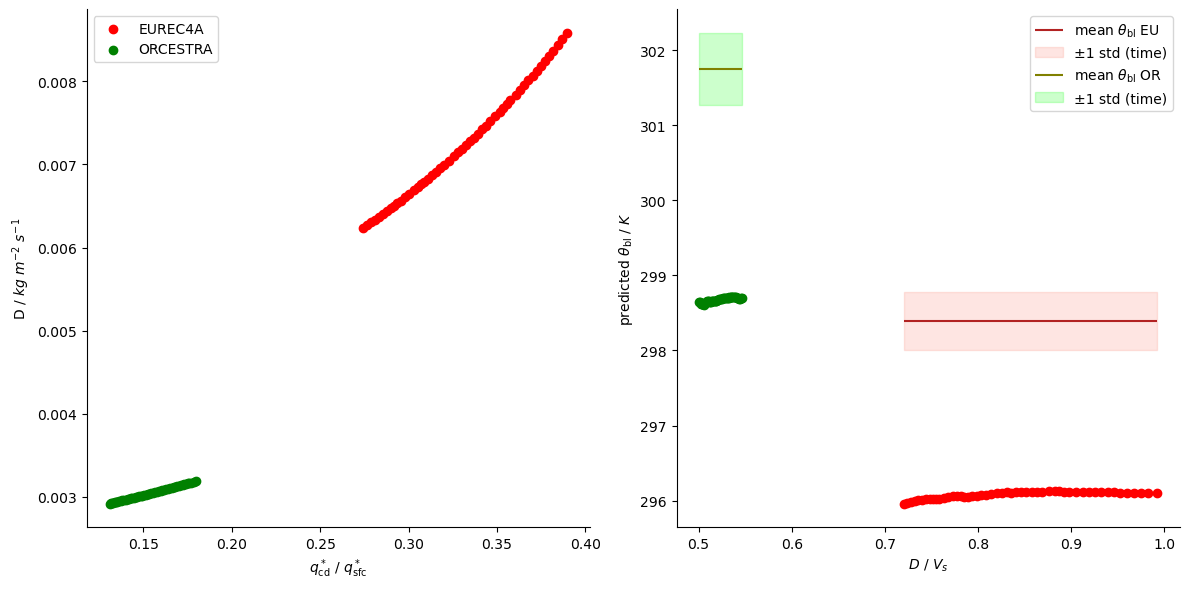

In [128]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))

#### report E for values of q_out
ax[0].scatter(qSat_out_eu/q_sfc_eu, D_values_eu, color="red", label="EUREC4A")
ax[0].scatter(qSat_out_or/q_sfc_or, D_values_or, color="green", label="ORCESTRA")

ax[0].set_xlabel(r"$q^*_\mathrm{cd}$ / $q^*_\mathrm{sfc}$")
# ax[0].set_xlabel(r"$\chi$")
ax[0].set_ylabel(r"D / $kg~m^{-2}~s^{-1}$")
ax[0].legend()






#### compare predicted theta with actual theta

ax[1].scatter(D_values_eu/Vs_lhf_eu, thetaD_pred_eu, color="red")
ax[1].scatter(D_values_or/Vs_lhf_or, thetaD_pred_or, color="green")

ax[1].hlines(theta_bl_eu, xmin=np.min(D_values_eu/Vs_lhf_eu), xmax=np.max(D_values_eu/Vs_lhf_eu), color="firebrick", label=r"mean $\theta_\mathrm{bl}$ EU")
ax[1].fill_between(
    [np.min(D_values_eu/Vs_lhf_eu), np.max(D_values_eu/Vs_lhf_eu)],
    (theta_bl_eu - th_var_eu) ,
    (theta_bl_eu + th_var_eu) ,
    color="salmon",
    alpha=0.2,
    label='±1 std (time)'
)



ax[1].hlines(theta_bl_or, xmin=np.min(D_values_or/Vs_lhf_or), xmax=np.max(D_values_or/Vs_lhf_or), color="olive", label=r"mean $\theta_\mathrm{bl}$ OR")
ax[1].fill_between(
    [np.min(D_values_or/Vs_lhf_or), np.max(D_values_or/Vs_lhf_or)],
    (theta_bl_or - th_var_or) ,
    (theta_bl_or + th_var_or) ,
    color="lime",
    alpha=0.2,
    label='±1 std (time)'
)



ax[1].set_xlabel(r"$D ~ / ~ V_s$") #/ $kg~m^{-2}~s^{-1}$")
ax[1].set_ylabel(r"predicted $\theta_\mathrm{bl}$ / $K$")
ax[1].legend()

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)



plt.tight_layout()
plt.show()

In [148]:
# non_thBL_terms_eu = rad_terms(ingr_eu.sw_global.sel(cell=0).mean(dim="time").values, ingr_eu.lw_diff.sel(cell=0).mean(dim="time").values, sst_eu.values)
# non_thBL_terms_or = rad_terms(ingr_or.sw_global.sel(cell=0).mean(dim="time").values, ingr_or.lw_diff.sel(cell=0).mean(dim="time").values, sst_or.values)

In [129]:
thetaD_predRad_eu = np.zeros_like(D_values_eu)
thetaD_predRad_or = np.zeros_like(D_values_or)

Rd = 287.

## EUREC4A DATA

for i, D in enumerate(D_values_eu):
    # Define the coefficients of the quartic: a*x^4 + b*x^3 + c*x^2 + d*x + e = 0
    coeffs = [
        -((2 - eps) / (1 - eps)) * eps * stefan,                                   # a (x^4)
        0,                                                                         # b (x^3)
        0,                                                                         # c (x^2)
        -cp*D,                                                                     # d (x^1)
        shf_recShip_eu.item() + cp*D * thetaD_eu[i] + non_thBL_terms_eu     # e (constant)
    ]
    
    # Solve the polynomial
    roots = np.roots(coeffs)
    
    # Filter only the fully real roots (no imaginary part)
    real_roots = roots[np.isreal(roots)]
    real_roots = np.real(real_roots) 
    
    # Now filter for physically meaningful (positive) roots
    positive_real_roots = real_roots[real_roots > 0]
    
    if len(positive_real_roots) > 0:
        thetaD_predRad_eu[i] = np.max(positive_real_roots)



## ORCESTRA DATA

for i, D in enumerate(D_values_or):
    # Define the coefficients of the quartic: a*x^4 + b*x^3 + c*x^2 + d*x + e = 0
    coeffs = [
        -((2 - eps) / (1 - eps)) * eps * stefan,                                    # a (x^4)
        0,                                                                          # b (x^3)
        0,                                                                          # c (x^2)
        -cp*D,                                                     # d (x^1)
        shf_recShip_or + cp*D * thetaD_or[i] + non_thBL_terms_or      # e (constant)
    ]
    
    # Solve the polynomial
    roots = np.roots(coeffs)
    
    # Filter only the fully real roots (no imaginary part)
    real_roots = roots[np.isreal(roots)]
    real_roots = np.real(real_roots)
    
    # Now filter for physically meaningful (positive) roots
    positive_real_roots = real_roots[real_roots > 0]
    
    if len(positive_real_roots) > 0:
        thetaD_predRad_or[i] = np.max(positive_real_roots)

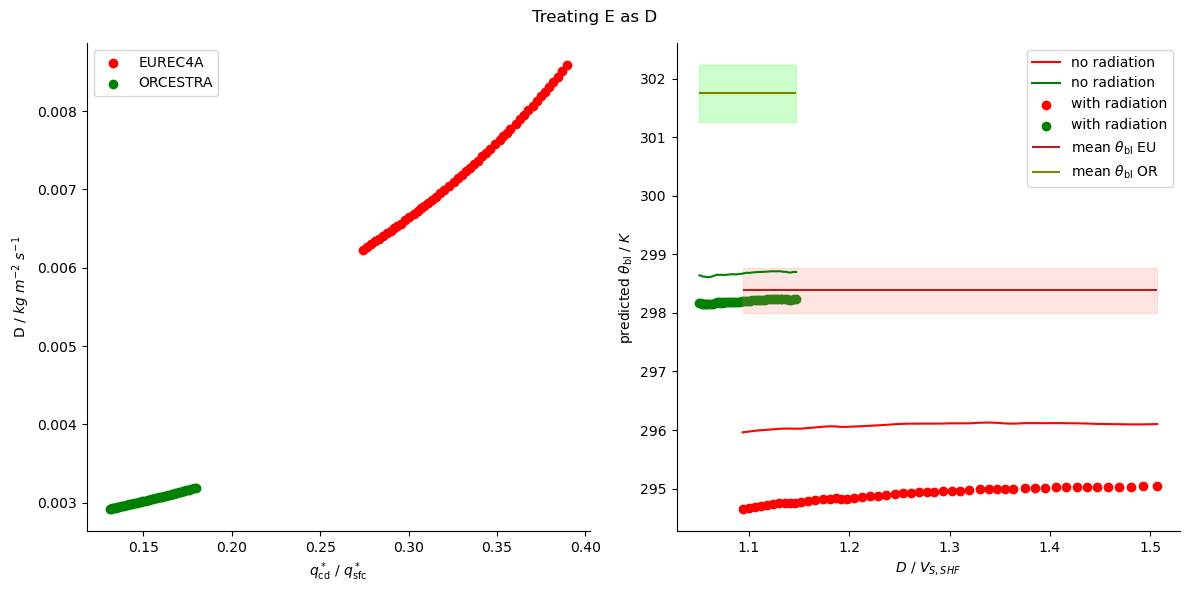

In [130]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
fig.suptitle("Treating E as D")

#### report E for values of q_out
ax[0].scatter(qSat_out_eu/q_sfc_eu, D_values_eu, color="red", label="EUREC4A")
ax[0].scatter(qSat_out_or/q_sfc_or, D_values_or, color="green", label="ORCESTRA")

ax[0].set_xlabel(r"$q^*_\mathrm{cd}$ / $q^*_\mathrm{sfc}$")
# ax[0].set_xlabel(r"$\chi$")
ax[0].set_ylabel(r"D / $kg~m^{-2}~s^{-1}$")
ax[0].legend()






#### compare predicted theta with actual theta
ax[1].plot(D_values_eu/Vs_shf_eu, thetaD_pred_eu, color="red", label="no radiation")
ax[1].plot(D_values_or/Vs_shf_or, thetaD_pred_or, color="green", label="no radiation")

ax[1].scatter(D_values_eu/Vs_shf_eu, thetaD_predRad_eu, color="red", label="with radiation")
ax[1].scatter(D_values_or/Vs_shf_or, thetaD_predRad_or, color="green", label="with radiation")

ax[1].hlines(theta_bl_eu, xmin=np.min(D_values_eu/Vs_shf_eu), xmax=np.max(D_values_eu/Vs_shf_eu), color="firebrick", label=r"mean $\theta_\mathrm{bl}$ EU")
ax[1].fill_between(
    [np.min(D_values_eu/Vs_shf_eu), np.max(D_values_eu/Vs_shf_eu)],
    (theta_bl_eu - th_var_eu) ,
    (theta_bl_eu + th_var_eu) ,
    color="salmon",
    alpha=0.2
)



ax[1].hlines(theta_bl_or, xmin=np.min(D_values_or/Vs_shf_or), xmax=np.max(D_values_or/Vs_shf_or), color="olive", label=r"mean $\theta_\mathrm{bl}$ OR")
ax[1].fill_between(
    [np.min(D_values_or/Vs_shf_or), np.max(D_values_or/Vs_shf_or)],
    (theta_bl_or - th_var_or) ,
    (theta_bl_or + th_var_or) ,
    color="lime",
    alpha=0.2
)



ax[1].set_xlabel(r"$D$ / $V_{S,SHF}$ ") #/ $kg~m^{-2}~s^{-1}$")
ax[1].set_ylabel(r"predicted $\theta_\mathrm{bl}$ / $K$")
ax[1].legend(loc="upper right")   #, bbox_to_anchor=(1.25,0.02))

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)



plt.tight_layout()
plt.show()

## Merging the two with a local MSE budget

With my current nomenclature and Yokoi and Katsumata 2022:

$$V_{s,SHF} \cdot (SST - \theta_{BL}) + m_{E} \cdot (\theta_E - \theta_{BL}) + m_{cd} \cdot (\theta_{cd} - \theta_{BL}) + R/c_p = 0$$
$$V_{s,LHF} \cdot (q^*_{sfc} - q_{BL}) + m_{E} \cdot (q_E - q_{BL}) + m_{cd} \cdot (q^*_{cd} - q_{BL}) = 0$$


actually, I should use the ERA5 surface heat fluxes 

$$SHF + c_p~m_{E} \cdot (\theta_E - \theta_{BL}) + c_p~m_{cd} \cdot (\theta_{cd} - \theta_{BL}) + R + c_p~\rho~H~F_{a,\theta} = 0$$
$$LHF + L_v~m_{E} \cdot (q_E - q_{BL}) + L_v~m_{cd} \cdot (q^*_{cd} - q_{BL}) + L_v~\rho~H~F_{a,q} = 0$$

In [35]:
import yk22_mass_fluxes

In [36]:
entrainment_levels = slice(600, 850)

downdraft_levels_eu = slice(600, 1600)      ## TRY HIGHER LEVELS HERE, \delta_{cd, EU} is positive with these!
downdraft_levels_or = slice(2000, 3000)

In [37]:
min_hgt = 40.

level2_path = "/work/mh1498/m301248/TCO_data/eurec4a_profiles_level2/EUREC4A_BCO_Vaisala-RS_L2_v3.0.0.nc"
ds_eureca = xr.open_dataset(level2_path)
ds_eureca_bco = ds_eureca.where(((ds_eureca["platform"] == 1)&(ds_eureca["ascent_flag"]==1)&(ds_eureca.alt>min_hgt)), drop=True)
## renaming for common ground
ds_eureca_bco = ds_eureca_bco.swap_dims({"sounding": "launch_time"})
ds_eureca_bco = ds_eureca_bco.rename({"alt":"height"})


ds_orcestra = xr.open_dataset("ipfs://bafybeid7cnw62zmzfgxcvc6q6fa267a7ivk2wcchbmkoyk4kdi5z2yj2w4", engine="zarr")
ds_orcestra
ds_orcestra_bco = ds_orcestra.where(((ds_orcestra["platform"] == "BCO")&(ds_orcestra["ascent_flag"]==0)&(ds_orcestra.height>min_hgt)), drop=True)


In [38]:
## load campaign-mean SST data
ingr_eu = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/EUREC4A_IngrFlux.nc")
sst_eu = ingr_eu.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

ingr_or = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/ORCESTRA_IngrFlux.nc")
sst_or = ingr_or.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])



sst_local = ingr_eu.sst.sel(cell=[17,24,31,18,25,32, 19,26,33])
q_sfc_eu = meteo.qsea(sst_local-273.15, 1013.)
q_sfc_eu = np.mean(q_sfc_eu)/1e3

sst_local = ingr_or.sst.sel(cell=[17,24,31,18,25,32, 19,26,33])
q_sfc_or = meteo.qsea(sst_local-273.15, 1013.)
q_sfc_or = np.mean(q_sfc_or)/1e3

In [39]:
fluxes_eu = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/sfcFluxes_EUREC4A.nc")
lhf_era5_eu = fluxes_eu.lhf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])
shf_era5_eu = fluxes_eu.shf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

fuxes_or = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/sfcFluxes_ORCESTRA.nc")
lhf_era5_or = fuxes_or.lhf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])
shf_era5_or = fuxes_or.shf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])




###### bulk fluxes from one week of ship measurements
ds_bulkFluxes = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/Bulk_fluxes_from_Meteor.nc")
lhf_recShip_eu = ds_bulkFluxes.LHF_eu.mean(dim="time_eu")
lhf_recShip_or = ds_bulkFluxes.LHF_or.mean(dim="time_or")
shf_recShip_eu = ds_bulkFluxes.SHF_eu.mean(dim="time_eu")
shf_recShip_or = ds_bulkFluxes.SHF_or.mean(dim="time_or")

# Vs_lhf_eu = (lhf_recShip_eu/(Lv*(q_sfc_eu - q_bl_eu))).values
# Vs_lhf_or = (lhf_recShip_or/(Lv*(q_sfc_or - q_bl_or))).values

# Vs_shf_eu = (shf_recShip_eu/(cp*(sst_eu - theta_bl_eu))).values
# Vs_shf_or = (shf_recShip_or/(cp*(sst_or - theta_bl_or))).values


In [40]:
## load campaign-mean SST data
ingr_eu = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/EUREC4A_IngrFlux.nc")
sst_eu = ingr_eu.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

ingr_or = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/ORCESTRA_IngrFlux.nc")
sst_or = ingr_or.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])


In [41]:
import importlib
importlib.reload(yk22_mass_fluxes)

<module 'yk22_mass_fluxes' from '/work/mh1498/m301248/TCO_data/BCO_observational/mass_fluxes_profiles/yk22_mass_fluxes.py'>

In [42]:
mean_prof_eu = ds_eureca_bco.mean(dim="launch_time")
props_eu = yk22_mass_fluxes.properties_from_profile(mean_prof_eu, mixed_avg_levels, entrainment_levels, downdraft_levels_eu, CD_sat_frac=1., vert_dim="height")

RNet_eu = yk22_mass_fluxes.compute_RNet(ingr_eu.sw_global.sel(cell=0).mean(dim="time").values,
                ingr_eu.lw_diff.sel(cell=0).mean(dim="time").values,
                sst_eu.values, 
                props_eu["theta_bl"].values)

E_CD_eu = yk22_mass_fluxes.solve_qTh_equations(props_eu, shf_recShip_eu.values, lhf_recShip_eu.values, RNet_eu, Fa_q_eu, Fa_th_eu)




mean_prof_or = ds_orcestra_bco.mean(dim="launch_time")
props_or = yk22_mass_fluxes.properties_from_profile(mean_prof_or, mixed_avg_levels, entrainment_levels, downdraft_levels_or, CD_sat_frac=1., vert_dim="height")

RNet_or = yk22_mass_fluxes.compute_RNet(ingr_or.sw_global.sel(cell=0).mean(dim="time").values,
                ingr_or.lw_diff.sel(cell=0).mean(dim="time").values,
                sst_or.values, 
                props_or["theta_bl"].values)


E_CD_or = yk22_mass_fluxes.solve_qTh_equations(props_or, shf_recShip_or.values, lhf_recShip_or.values, RNet_or, Fa_q_or, Fa_th_or)

In [43]:
E_CD_eu.mD

<xarray.DataArray 'mD' ()> Size: 8B
array(0.00244726)
Attributes:
    units:    kg / m2 s

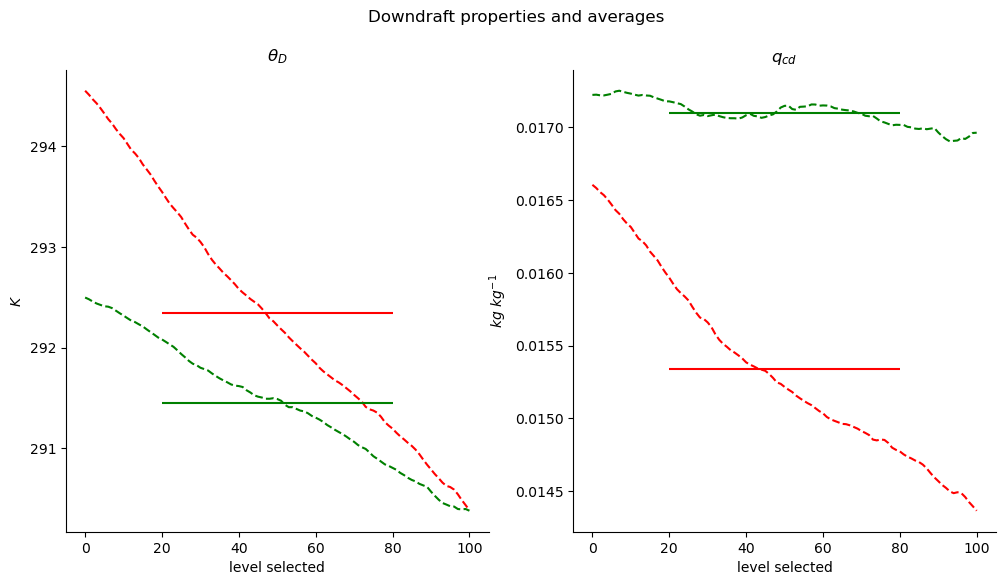

In [44]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
fig.suptitle("Downdraft properties and averages")

ax[0].plot(props_eu["thetaD"], "--", color="red", label="EUREC4A")
ax[0].plot(props_or["thetaD"], "--", color="green", label="ORCESTRA")

ax[0].hlines(xmin=20, xmax=80, y=props_eu["thetaD"].weighted((props_eu["thetaD"].p_cd).diff(dim="height_cd", n=1)).mean(), color="red", label="EUREC4A")
ax[0].hlines(xmin=20, xmax=80, y=props_or["thetaD"].weighted((props_or["thetaD"].p_cd).diff(dim="height_cd", n=1)).mean(), color="green", label="ORCESTRA")

ax[0].set_xlabel("level selected")
ax[0].set_ylabel(r"$K$")
ax[0].set_title(r"$\theta_D$")



ax[1].plot(props_eu["qD"], "--", color="red", label="EUREC4A")
ax[1].plot(props_or["qD"], "--", color="green", label="ORCESTRA")

ax[1].hlines(xmin=20, xmax=80, y=props_eu["qD"].weighted((props_eu["qD"].p_cd).diff(dim="height_cd", n=1)).mean(), color="red", label="EUREC4A")
ax[1].hlines(xmin=20, xmax=80, y=props_or["qD"].weighted((props_or["qD"].p_cd).diff(dim="height_cd", n=1)).mean(), color="green", label="ORCESTRA")

ax[1].set_xlabel("level selected")
ax[1].set_ylabel(r"$kg~kg^{-1}$")
ax[1].set_title(r"$q_{cd}$")

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

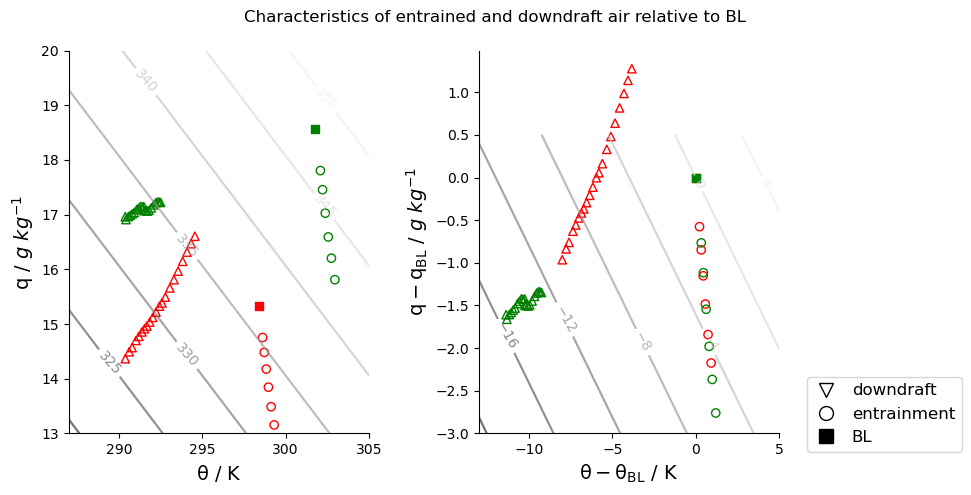

In [45]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Characteristics of entrained and downdraft air relative to BL")

th, q = np.linspace(287, 305), np.linspace(0.013*1e3, 0.02*1e3)
dth, dq = np.linspace(-13, 5), np.linspace(-3.e-3*1e3, (5e-4)*1e3)
Th, Q = np.meshgrid(th, q)
DTh, DQ = np.meshgrid(dth, dq)

MSE  = (cp*Th + Lv*Q/1e3)/cp
DMSE = (cp*DTh + Lv*DQ/1e3)/cp



datasets = {
    "eu": dict(color="red", sst=sst_eu.item(),  q_sfc=q_sfc_eu*1e3,  theta_bl=props_eu["theta_bl"], q_bl=props_eu["q_bl"],
               theta_out=props_eu["theta_out"][::5], q_out=props_eu["q_out"][::5]*1e3,
               thetaD=props_eu["thetaD"][::5],       qSat=props_eu["qD"][::5]*1e3),
    "or": dict(color="green", sst=sst_or.item(),  q_sfc=q_sfc_or*1e3, theta_bl=props_or["theta_bl"], q_bl=props_or["q_bl"],
               theta_out=props_or["theta_out"][::5], q_out=props_or["q_out"][::5]*1e3,
               thetaD=props_or["thetaD"][::5],       qSat=props_or["qD"][::5]*1e3),
}

for d in datasets.values():
    c, th_bl, q_bl, q_sfc, sst = d["color"], d["theta_bl"], d["q_bl"]*1e3 , d["q_sfc"], d["sst"]

    # absolute coords (ax[0])
    ax[0].scatter(th_bl,        q_bl,        c=c,           marker="s")
    ax[0].scatter(d["theta_out"], d["q_out"], edgecolors=c, marker="o", facecolors="none")
    ax[0].scatter(d["thetaD"],   d["qSat"],  edgecolors=c, marker="^", facecolors="none")
    cs = ax[0].contour(Th, Q, MSE, cmap="Greys_r", alpha=0.4)
    ax[0].clabel(cs, inline=True)
    ax[0].set_xlabel(r"$\rm \theta$ / K", fontsize=14)
    ax[0].set_ylabel(r"$\rm q$ / $g~kg^{-1}$", fontsize=14)


    # relative to BL (ax[1])
    ax[1].scatter(0,                          0,                          c=c,           marker="s")
    ax[1].scatter((d["theta_out"] - th_bl),     (d["q_out"] - q_bl),         edgecolors=c, marker="o", facecolors="none")
    ax[1].scatter((d["thetaD"]    - th_bl),     (d["qSat"]  - q_bl),         edgecolors=c, marker="^", facecolors="none")
    cs = ax[1].contour(DTh, DQ, DMSE, cmap="Greys_r", alpha=0.4)
    ax[1].clabel(cs, inline=True)
    ax[1].set_xlabel(r"$\rm \theta - \theta_{BL}$ / K", fontsize=14)
    ax[1].set_ylabel(r"$\rm q - q_{BL}$ / $g~kg^{-1}$", fontsize=14)

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

downdraft   = mlines.Line2D([], [], color='black', marker='v', linestyle='None',
                            markerfacecolor='none', markeredgecolor='black',
                            markersize=10, label=r'downdraft')
 
entrainment = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                            markerfacecolor='none', markeredgecolor='black',
                            markersize=10, label='entrainment')
 
bl          = mlines.Line2D([], [], color='black', marker='s', linestyle='None',
                            markerfacecolor='black', markeredgecolor='black',
                            markersize=10, label='BL')
 
legend = ax[1].legend(handles=[downdraft, entrainment, bl],
                   loc='center', frameon=True, fontsize=12,
                   handlelength=1.5, handletextpad=0.8, bbox_to_anchor=(1.35, 0.05))

plt.tight_layout()

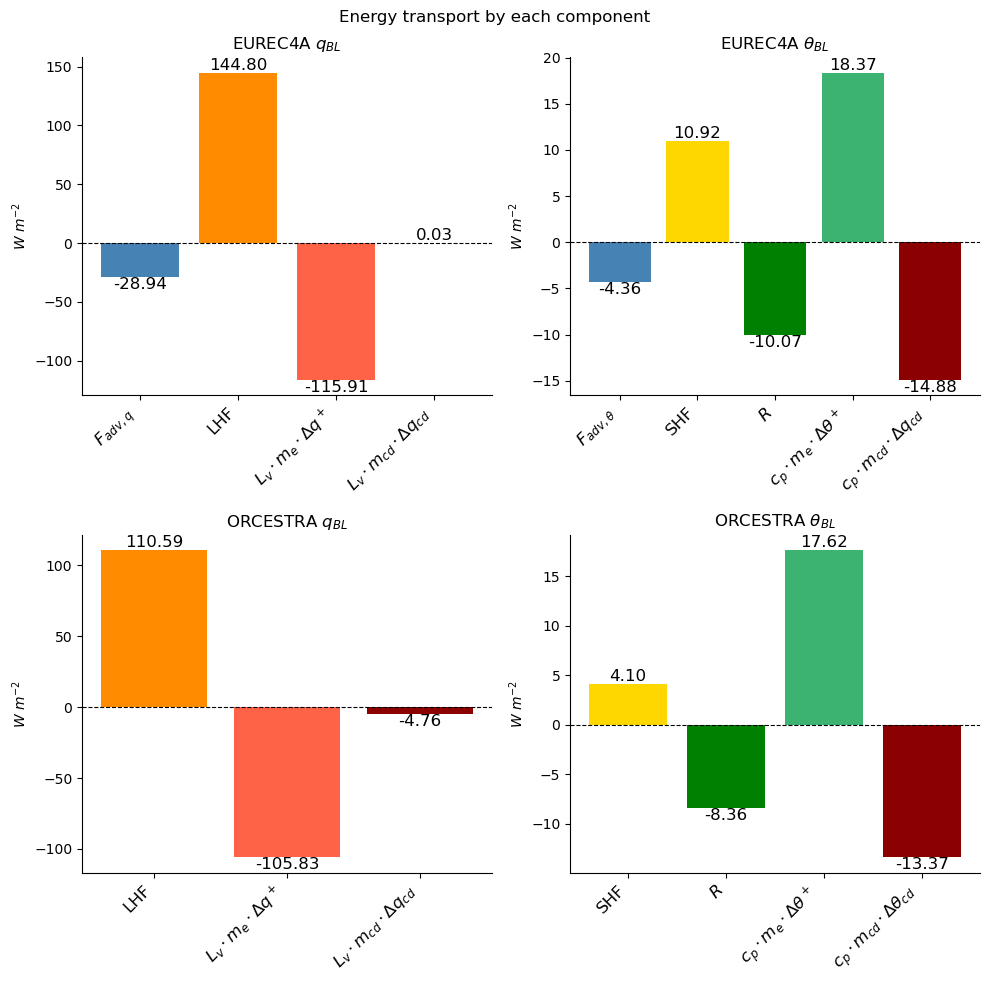

In [46]:
fig, ax = plt.subplots(2,2, figsize=(10, 10))
ax = ax.flatten()
fig.suptitle("Energy transport by each component")



labels = [
    r"$F_{adv, q}$",
    "LHF",
    r"$L_v \cdot m_e\cdot \Delta q^+$",
    r"$L_v \cdot m_{cd}\cdot \Delta q_{cd}$"
]

colors = [
    "steelblue",        # F_adv
    "darkorange",       # LHF
    "tomato",           # m_e · Δq+
    "darkred"
]


terms_moisture_eu = [(bl_density*bl_height*(Lv*Fa_q_eu)), 
                      lhf_recShip_eu.values, 
                      (E_CD_eu["me"]*Lv*(props_eu["q_out"] - props_eu["q_bl"])).mean().values ,
                      (E_CD_eu["mD"]*Lv*(props_eu["qD"] - props_eu["q_bl"])).mean().values ] 

# bar_values = [terms_moisture_eu[i][0]for i in range(len(terms_moisture_eu))]

all_labels = labels

ax[0].bar(all_labels, terms_moisture_eu, color=colors )   
for i, v in enumerate(terms_moisture_eu):   
    ax[0].text(i, v, f"{v:.2f}", ha='center', va='bottom' if v >= 0 else 'top', fontsize=12)
ax[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
ax[0].set_title(r"EUREC4A $q_{BL}$")
ax[0].set_ylabel(r"$W~m^{-2}$")
ax[0].set_xticks(range(len(all_labels)))
ax[0].set_xticklabels(all_labels, rotation=45, ha='right', fontsize=12)







labels = [
    r"$F_{adv, \theta}$",
    "SHF",
    r"$R$",
    r"$c_p \cdot m_e \cdot \Delta \theta^+$",
    r"$c_p \cdot m_{cd}\cdot \Delta q_{cd}$"
]


colors = [
    "steelblue",        # F_adv
    "gold",             # SHF
    "green",            # R
    "mediumseagreen",   # m_e · Δθ+
    "darkred"
]

terms_th_eu = [(bl_density*bl_height*(cp*Fa_th_eu) ),
                shf_recShip_eu.values  ,
                RNet_eu,
                (E_CD_eu["me"]*cp*(props_eu["theta_out"] - props_eu["theta_bl"])).mean().values , 
                (E_CD_eu["mD"]*cp*(props_eu["thetaD"] - props_eu["theta_bl"])).mean().values ] 

# bar_values = [terms_th_eu[i][0]for i in range(len(terms_th_eu))]

all_labels = labels #+ ["res"]

ax[1].bar(all_labels, terms_th_eu , color=colors ) 
for i, v in enumerate(terms_th_eu ): 
    ax[1].text(i, v, f"{v:.2f}", ha='center', va='bottom' if v >= 0 else 'top', fontsize=12)
ax[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
ax[1].set_title(r"EUREC4A $\theta_{BL}$")
ax[1].set_ylabel(r"$W~m^{-2}$")
ax[1].set_xticks(range(len(all_labels)))
ax[1].set_xticklabels(all_labels, rotation=45, ha='right', fontsize=12)



labels = [
    "LHF",
    r"$L_v \cdot m_e\cdot \Delta q^+$",
    r"$L_v \cdot m_{cd}\cdot \Delta q_{cd}$"
]

colors = [
    "darkorange",       # LHF
    "tomato",           # m_e · Δq+
    "darkred",          # m_cd · Δq_cd
]

terms_moisture_or = [lhf_recShip_or.values, 
                     (E_CD_or["me"]*Lv*(props_or["q_out"] - props_or["q_bl"])).mean().values ,
                    ( E_CD_or["mD"]*Lv*(props_or["qD"] - props_or["q_bl"])).mean().values  ] 

# bar_values = [terms_moisture_or[i][0]for i in range(len(terms_moisture_or))]

all_labels = labels #+ ["res"]

ax[2].bar(all_labels, terms_moisture_or , color=colors + ['grey'])    #+ [sum(bar_values)]
for i, v in enumerate(terms_moisture_or ):    #+ [sum(bar_values)]
    ax[2].text(i, v, f"{v:.2f}", ha='center', va='bottom' if v >= 0 else 'top', fontsize=12)
ax[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
ax[2].set_title(r"ORCESTRA $q_{BL}$")
ax[2].set_ylabel(r"$W~m^{-2}$")
ax[2].set_xticks(range(len(all_labels)))
ax[2].set_xticklabels(all_labels, rotation=45, ha='right', fontsize=12)








labels = [
    "SHF",
    r"$R$",
    r"$c_p \cdot m_e\cdot \Delta \theta^+$",
    r"$c_p \cdot m_{cd}\cdot \Delta \theta_{cd}$",
]


colors = [
    "gold",             # SHF
    "green",            # R
    "mediumseagreen",   # m_e · Δθ+
    "darkred",        # m_cd · Δθ_cd
]


terms_th_or = [shf_recShip_or.values ,
               RNet_or,
               (E_CD_or["me"]*cp*(props_or["theta_out"] - props_or["theta_bl"])).mean().values ,
               (E_CD_or["mD"]*cp*(props_or["thetaD"]- props_or["theta_bl"])).mean().values  ] 

# bar_values = [terms_th_or[i][0]for i in range(len(terms_th_or))]

all_labels = labels #+ ["res"]

ax[3].bar(all_labels, terms_th_or, color=colors + ['grey'])  # + [sum(bar_values)]
for i, v in enumerate(terms_th_or):  # + [sum(bar_values)]
    ax[3].text(i, v, f"{v:.2f}", ha='center', va='bottom' if v >= 0 else 'top', fontsize=12)
ax[3].axhline(0, color='black', linewidth=0.8, linestyle='--')
ax[3].set_title(r"ORCESTRA $\theta_{BL}$")
ax[3].set_ylabel(r"$W~m^{-2}$")
ax[3].set_xticks(range(len(all_labels)))
ax[3].set_xticklabels(all_labels, rotation=45, ha='right', fontsize=12)



for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)


plt.tight_layout()

#### modified version with stacked columns

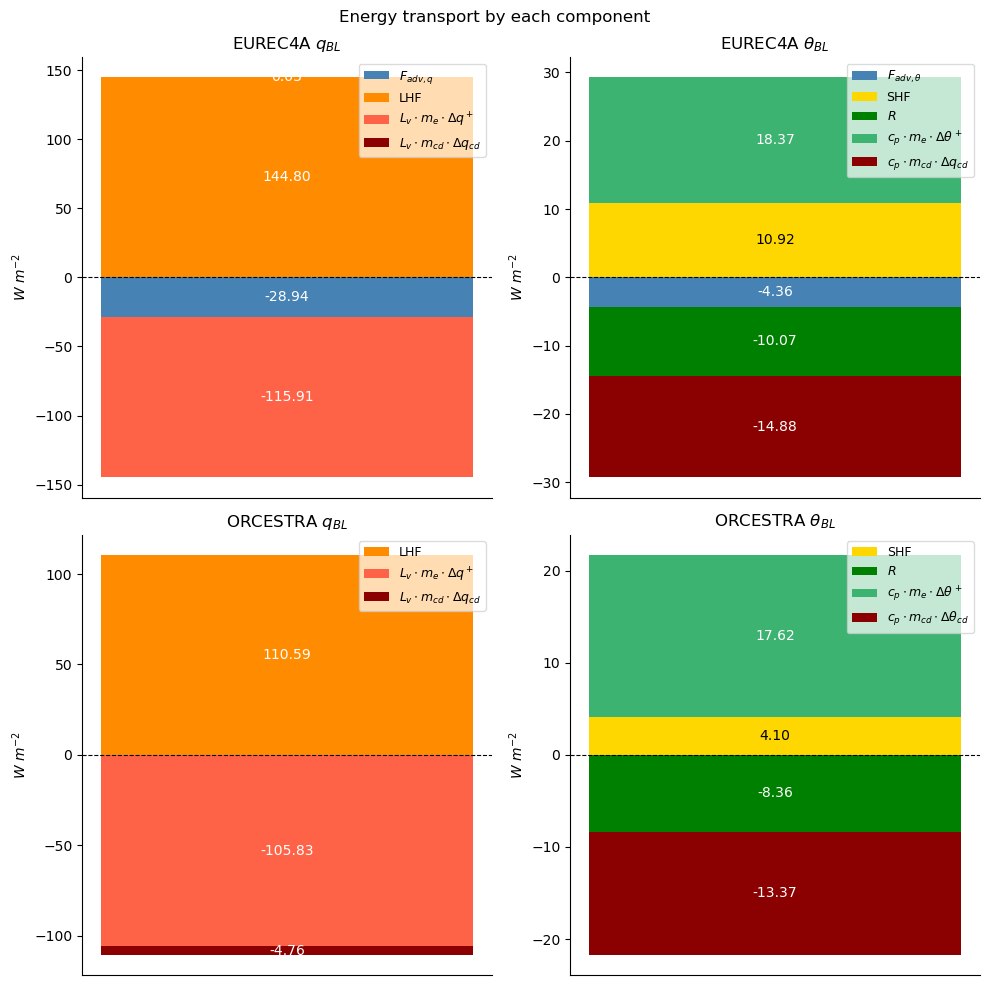

In [16]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax = ax.flatten()
fig.suptitle("Energy transport by each component")

subplots = [
    {
        "title": r"EUREC4A $q_{BL}$",
        "terms": terms_moisture_eu,
        "labels": [r"$F_{adv, q}$", "LHF", r"$L_v \cdot m_e\cdot \Delta q^+$", r"$L_v \cdot m_{cd}\cdot \Delta q_{cd}$"],
        "colors": ["steelblue", "darkorange", "tomato", "darkred"],
    },
    {
        "title": r"EUREC4A $\theta_{BL}$",
        "terms": terms_th_eu,
        "labels": [r"$F_{adv, \theta}$", "SHF", r"$R$", r"$c_p \cdot m_e \cdot \Delta \theta^+$", r"$c_p \cdot m_{cd}\cdot \Delta q_{cd}$"],
        "colors": ["steelblue", "gold", "green", "mediumseagreen", "darkred"],
    },
    {
        "title": r"ORCESTRA $q_{BL}$",
        "terms": terms_moisture_or,
        "labels": ["LHF", r"$L_v \cdot m_e\cdot \Delta q^+$", r"$L_v \cdot m_{cd}\cdot \Delta q_{cd}$"],
        "colors": ["darkorange", "tomato", "darkred"],
    },
    {
        "title": r"ORCESTRA $\theta_{BL}$",
        "terms": terms_th_or,
        "labels": ["SHF", r"$R$", r"$c_p \cdot m_e\cdot \Delta \theta^+$", r"$c_p \cdot m_{cd}\cdot \Delta \theta_{cd}$"],
        "colors": ["gold", "green", "mediumseagreen", "darkred"],
    },
]

for i, sp in enumerate(subplots):
    bottom_pos = 0
    bottom_neg = 0
    handles = []

    for val, label, color in zip(sp["terms"], sp["labels"], sp["colors"]):
        if val >= 0:
            bar = ax[i].bar(0, val, bottom=bottom_pos, color=color, label=label, width=0.5)
            ax[i].text(0, bottom_pos + val / 2, f"{val:.2f}", ha='center', va='center',
                       fontsize=10, color='white' if color not in ['gold'] else 'black')
            bottom_pos += val
        else:
            bar = ax[i].bar(0, val, bottom=bottom_neg, color=color, label=label, width=0.5)
            ax[i].text(0, bottom_neg + val / 2, f"{val:.2f}", ha='center', va='center',
                       fontsize=10, color='white')
            bottom_neg += val
        handles.append(bar)

    ax[i].axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax[i].set_title(sp["title"])
    ax[i].set_ylabel(r"$W~m^{-2}$")
    ax[i].set_xticks([])
    ax[i].legend(handles=[h[0] for h in handles], labels=sp["labels"],
                 loc='upper right', fontsize=9, framealpha=0.7)

    for spine in ['top', 'right']:
        ax[i].spines[spine].set_visible(False)

plt.tight_layout()

#### testing change in values of surface fluxes

In [47]:
shf_test = np.linspace(-10., 20, 50)
lhf_test = np.linspace(70, 170, 50)

SHF, LHF = np.meshgrid(shf_test, lhf_test)

mf_eu = np.zeros((2, shf_test.size, lhf_test.size))
mf_or = np.zeros((2, shf_test.size, lhf_test.size))

for i, shf in enumerate(shf_test):
    for j, lhf in enumerate(lhf_test):
        mf = yk22_mass_fluxes.solve_qTh_equations(props_eu, shf, lhf, RNet_eu, Fa_q_eu, Fa_th_eu)
        mf_eu[0, i, j] = mf["me"].item()
        mf_eu[1, i, j] = mf["mD"].item()

        mf = yk22_mass_fluxes.solve_qTh_equations(props_or, shf, lhf, RNet_or, Fa_q_or, Fa_th_or)
        mf_or[0, i, j] = mf["me"].item()
        mf_or[1, i, j] = mf["mD"].item()

In [48]:
actual_mf_eu = yk22_mass_fluxes.solve_qTh_equations(props_eu, shf_recShip_eu, lhf_recShip_eu, RNet_eu, Fa_q_eu, Fa_th_eu)
actual_mf_or = yk22_mass_fluxes.solve_qTh_equations(props_or, shf_recShip_or, lhf_recShip_or, RNet_or, Fa_q_or, Fa_th_or)

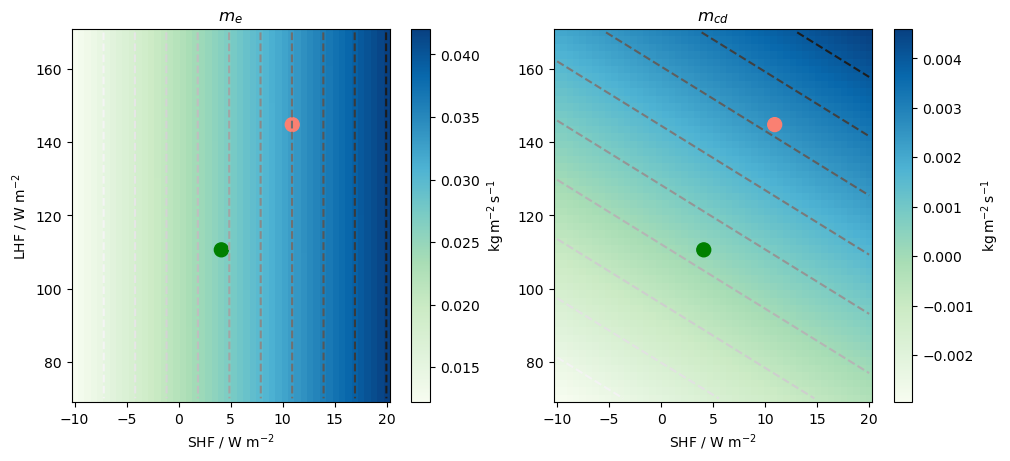

In [62]:

fig, ax = plt.subplots(1, 2, figsize=(10,4.5), constrained_layout=True)

# Common limits for m_e
vmin_me = min(mf_eu[0].min(), mf_or[0].min())
vmax_me = max(mf_eu[0].max(), mf_or[0].max())

# Common limits for m_cd
vmin_mcd = min(mf_eu[1].min(), mf_or[1].min())
vmax_mcd = max(mf_eu[1].max(), mf_or[1].max())

p00 = ax[0].pcolormesh(SHF, LHF, mf_eu[0],
                         vmin=vmin_me, vmax=vmax_me, cmap="GnBu")
ax[0].contour(SHF, LHF, mf_eu[0], levels=10, cmap="Greys", linestyles="--")
ax[0].scatter([shf_recShip_eu, shf_recShip_or], [lhf_recShip_eu, lhf_recShip_or], marker="o", color=["salmon", "green"], s=100)

ax[0].set_title(r"$m_e$")
ax[0].set_ylabel(r"LHF / $\rm W~m^{-2}$")
ax[0].set_xlabel(r"SHF / $\rm W~m^{-2}$")



p01 = ax[1].pcolormesh(SHF, LHF, mf_eu[1],
                         vmin=vmin_mcd, vmax=vmax_mcd, cmap="GnBu")
ax[1].contour(SHF, LHF, mf_eu[1], levels=10, cmap="Greys", linestyles="--")
ax[1].scatter([shf_recShip_eu, shf_recShip_or], [lhf_recShip_eu, lhf_recShip_or], marker="o", color=["salmon", "green"], s=100)
ax[1].set_title(r"$m_{cd}$")
ax[1].set_xlabel(r"SHF / $\rm W~m^{-2}$")


fig.colorbar(
    p00,
    ax=ax[0],
    label=r"$\rm kg\,m^{-2}\,s^{-1}$"
)

fig.colorbar(
    p01,
    ax=ax[1],
    label=r"$\rm kg\,m^{-2}\,s^{-1}$"
)


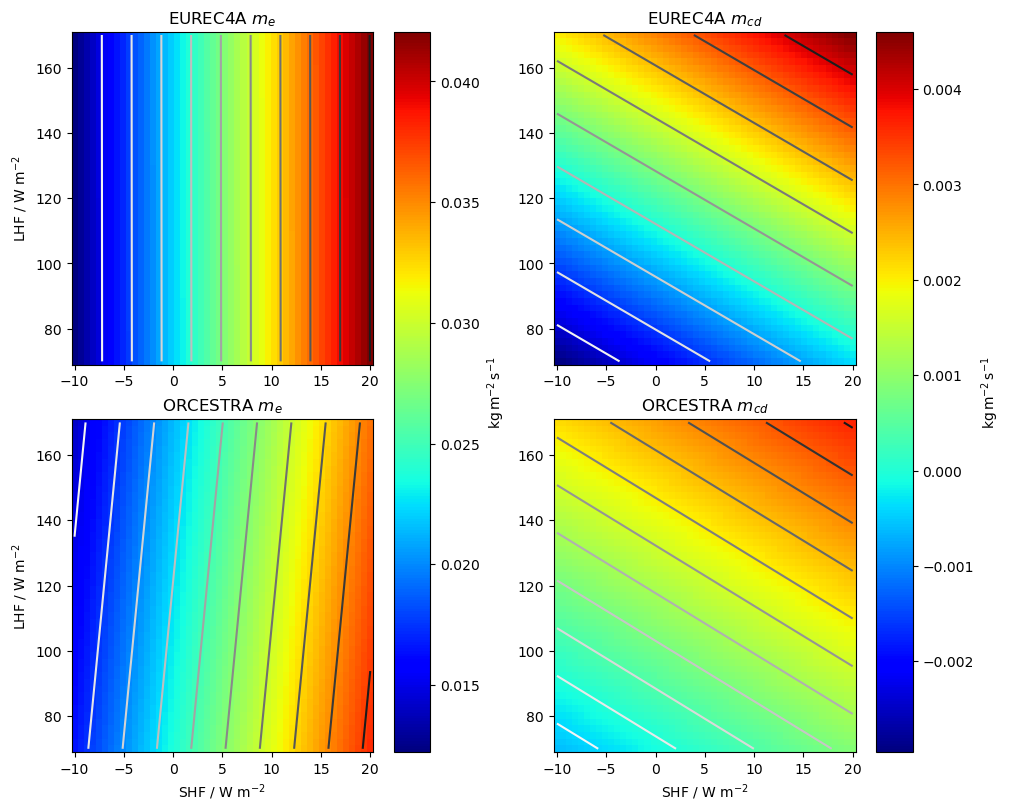

In [19]:

fig, ax = plt.subplots(2, 2, figsize=(10,8), constrained_layout=True)

# Common limits for m_e
vmin_me = min(mf_eu[0].min(), mf_or[0].min())
vmax_me = max(mf_eu[0].max(), mf_or[0].max())

# Common limits for m_cd
vmin_mcd = min(mf_eu[1].min(), mf_or[1].min())
vmax_mcd = max(mf_eu[1].max(), mf_or[1].max())

p00 = ax[0,0].pcolormesh(SHF, LHF, mf_eu[0],
                         vmin=vmin_me, vmax=vmax_me, cmap="jet")
ax[0,0].contour(SHF, LHF, mf_eu[0], levels=10, cmap="Greys")
ax[0,0].set_title(r"EUREC4A $m_e$")
ax[0,0].set_ylabel(r"LHF / $\rm W~m^{-2}$")


p01 = ax[0,1].pcolormesh(SHF, LHF, mf_eu[1],
                         vmin=vmin_mcd, vmax=vmax_mcd, cmap="jet")
ax[0,1].contour(SHF, LHF, mf_eu[1], levels=10, cmap="Greys")
ax[0,1].set_title(r"EUREC4A $m_{cd}$")

p10 = ax[1,0].pcolormesh(SHF, LHF, mf_or[0],
                         vmin=vmin_me, vmax=vmax_me, cmap="jet")
ax[1,0].contour(SHF, LHF, mf_or[0], levels=10, cmap="Greys")
ax[1,0].set_title(r"ORCESTRA $m_e$")
ax[1,0].set_xlabel(r"SHF / $\rm W~m^{-2}$")
ax[1,0].set_ylabel(r"LHF / $\rm W~m^{-2}$")




p11 = ax[1,1].pcolormesh(SHF, LHF, mf_or[1],
                         vmin=vmin_mcd, vmax=vmax_mcd, cmap="jet")
ax[1,1].contour(SHF, LHF, mf_or[1], levels=10, cmap="Greys")
ax[1,1].set_title(r"ORCESTRA $m_{cd}$")
ax[1,1].set_xlabel(r"SHF / $\rm W~m^{-2}$")

# One colorbar per column
fig.colorbar(
    p00,
    ax=ax[:, 0],
    label=r"$\rm kg\,m^{-2}\,s^{-1}$"
)

fig.colorbar(
    p01,
    ax=ax[:, 1],
    label=r"$\rm kg\,m^{-2}\,s^{-1}$"
)

# plt.tight_layout()

#### testing sensitivity to degree of saturation ($\alpha$)
$$ h_{cd} = c_p~\theta_{cd} + L_v \cdot ~ \alpha ~ q^*(\theta_{cd}, p_{cd})  $$

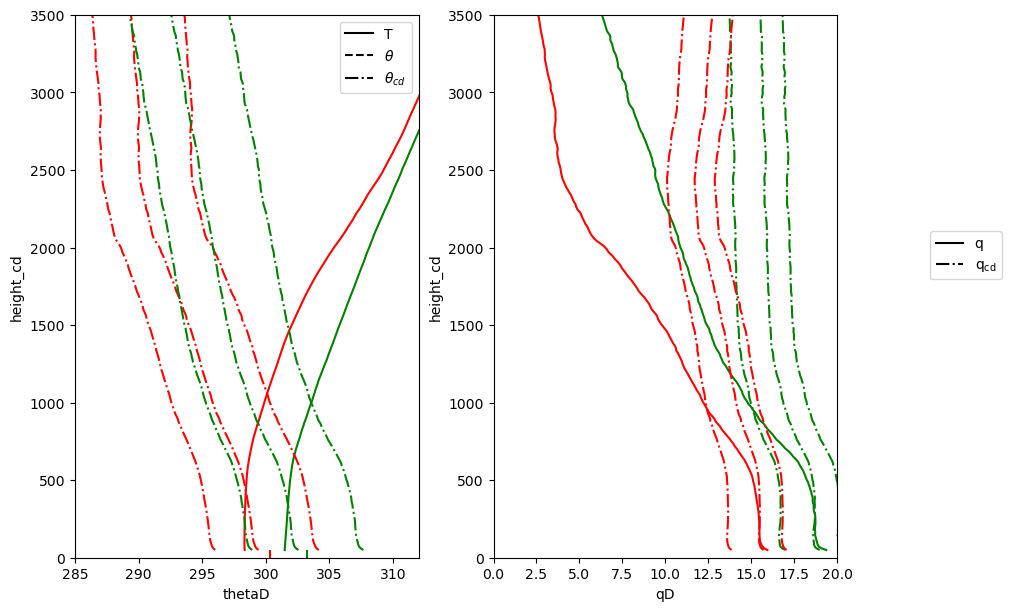

In [23]:
fig, ax = plt.subplots(1,2, figsize=(10,6), constrained_layout=True)

mean_prof_eu.theta.plot.line(ax=ax[0], y="height", color="red", linestyle="-")
mean_prof_or.theta.plot.line(ax=ax[0], y="height", color="green", linestyle="-")


legend_elements = [
    Line2D([0], [0], color='k', linestyle='-',  label='T'),
    Line2D([0], [0], color='k', linestyle='--', label=r'$\theta$'),
    Line2D([0], [0], color='k', linestyle='-.',  label=r'$\theta_{cd}$'),
]
ax[0].legend(handles=legend_elements)

ax[0].set_title("T")
ax[0].set_xlabel(r"K")
ax[0].set_xlim(285, 312)
ax[0].set_ylim(0, 3500)
ax[0].vlines([sst_eu, 
            sst_or], 
            ymin=0, ymax=50, 
            color=["red", "green"])




### moisture

(mean_prof_eu.q*1e3).plot.line(ax=ax[1], y="height", color="red")
(mean_prof_or.q*1e3).plot.line(ax=ax[1], y="height", color="green")


legend_elements = [
    Line2D([0], [0], color='k', linestyle='-',  label='q'),
    Line2D([0], [0], color='k', linestyle='-.',  label=r'$\rm q_{cd}$'),
]
ax[1].legend(handles=legend_elements, loc="lower left", bbox_to_anchor=(1.25,0.5))

ax[1].set_title(r"q")
ax[1].set_xlabel(r"$\rm g~kg^{-1}$")
ax[1].set_xlim(0, 20)
ax[1].set_ylim(0, 3500)




## sensitivity check

alpha = np.linspace(0.5, 1., 3)

for a in alpha:
    p_eu = yk22_mass_fluxes.properties_from_profile(mean_prof_eu, mixed_avg_levels, entrainment_levels, downdraft_levels = slice(0,3500), CD_sat_frac=a, vert_dim="height")
    p_or = yk22_mass_fluxes.properties_from_profile(mean_prof_or, mixed_avg_levels, entrainment_levels, downdraft_levels = slice(0,3500), CD_sat_frac=a, vert_dim="height")

    p_eu["thetaD"].plot.line(ax=ax[0], y="height_cd", color="red", linestyle="-.")
    p_or["thetaD"].plot.line(ax=ax[0], y="height_cd", color="green", linestyle="-.")

    (p_eu["qD"]*1e3).plot.line(ax=ax[1], y="height_cd", color="red", linestyle="-.")
    (p_or["qD"]*1e3).plot.line(ax=ax[1], y="height_cd", color="green", linestyle="-.")









# E_CD_eu = yk22_mass_fluxes.solve_qTh_equations(props_eu, shf_recShip_eu.values, lhf_recShip_eu.values, RNet_eu, Fa_q_eu, Fa_th_eu)

# E_CD_or = yk22_mass_fluxes.solve_qTh_equations(props_or, shf_recShip_or.values, lhf_recShip_or.values, RNet_or, Fa_q_or, Fa_th_or)

/tmp/ipykernel_408154/3080433179.py:27: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[0].scatter(th_bl,        q_bl,        c=c,           marker="s")
/tmp/ipykernel_408154/3080433179.py:37: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[1].scatter(0,                          0,                          c=c,           marker="s")


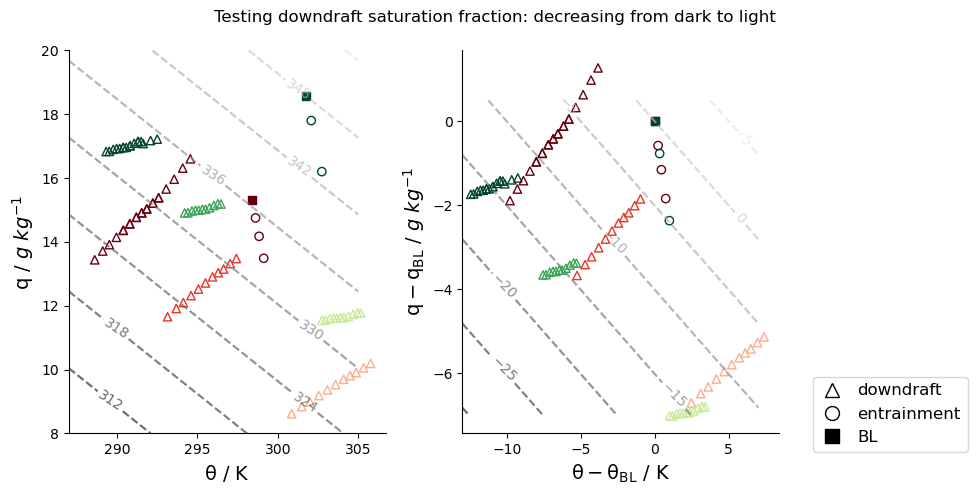

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle(r"Testing downdraft saturation fraction: decreasing from dark to light")

th, q = np.linspace(287, 305), np.linspace(0.008*1e3, 0.02*1e3)
dth, dq = np.linspace(-13, 7), np.linspace(-7.e-3*1e3, (5e-4)*1e3)
Th, Q = np.meshgrid(th, q)
DTh, DQ = np.meshgrid(dth, dq)

MSE  = (cp*Th + Lv*Q/1e3)/cp
DMSE = (cp*DTh + Lv*DQ/1e3)/cp



datasets = {
    "eu": dict(color=plt.cm.Reds(1.), sst=sst_eu.item(),  q_sfc=q_sfc_eu*1e3,  theta_bl=props_eu["theta_bl"], q_bl=props_eu["q_bl"],
               theta_out=props_eu["theta_out"][::10], q_out=props_eu["q_out"][::10]*1e3,
               thetaD=props_eu["thetaD"][::10],       qSat=props_eu["qD"][::10]*1e3),
    "or": dict(color=plt.cm.YlGn(1.), sst=sst_or.item(),  q_sfc=q_sfc_or*1e3, theta_bl=props_or["theta_bl"], q_bl=props_or["q_bl"],
               theta_out=props_or["theta_out"][::20], q_out=props_or["q_out"][::20]*1e3,
               thetaD=props_or["thetaD"][::20],       qSat=props_or["qD"][::20]*1e3),
}

for d in datasets.values():
    c, th_bl, q_bl, q_sfc, sst = d["color"], d["theta_bl"], d["q_bl"]*1e3 , d["q_sfc"], d["sst"]

    # absolute coords (ax[0])
    ax[0].scatter(th_bl,        q_bl,        c=c,           marker="s")
    ax[0].scatter(d["theta_out"], d["q_out"], edgecolors=c, marker="o", facecolors="none")
    ax[0].scatter(d["thetaD"],   d["qSat"],  edgecolors=c, marker="^", facecolors="none")
    cs = ax[0].contour(Th, Q, MSE, cmap="grey", alpha=0.4, linestyles="--")
    labels = ax[0].clabel(cs, inline=True)
    ax[0].set_xlabel(r"$\rm \theta$ / K", fontsize=14)
    ax[0].set_ylabel(r"$\rm q$ / $g~kg^{-1}$", fontsize=14)


    # relative to BL (ax[1])
    ax[1].scatter(0,                          0,                          c=c,           marker="s")
    ax[1].scatter((d["theta_out"] - th_bl),     (d["q_out"] - q_bl),         edgecolors=c, marker="o", facecolors="none")
    ax[1].scatter((d["thetaD"]    - th_bl),     (d["qSat"]  - q_bl),         edgecolors=c, marker="^", facecolors="none")
    cs = ax[1].contour(DTh, DQ, DMSE, cmap="grey", alpha=0.4, linestyles="--")
    labels = ax[1].clabel(cs, inline=True)
    ax[1].set_xlabel(r"$\rm \theta - \theta_{BL}$ / K", fontsize=14)
    ax[1].set_ylabel(r"$\rm q - q_{BL}$ / $g~kg^{-1}$", fontsize=14)



## testing degree of saturation
alpha = np.linspace(0.3, 1., 3)

colors_eu = plt.cm.Reds(np.linspace(0.3, 1, len(alpha)))
colors_or = plt.cm.YlGn(np.linspace(0.3, 1, len(alpha)))

for i, a in enumerate(alpha):
    p_eu = yk22_mass_fluxes.properties_from_profile(mean_prof_eu, mixed_avg_levels, entrainment_levels, downdraft_levels = slice(1000,2000), CD_sat_frac=a, vert_dim="height")
    p_or = yk22_mass_fluxes.properties_from_profile(mean_prof_or, mixed_avg_levels, entrainment_levels, downdraft_levels = slice(2500,3500), CD_sat_frac=a, vert_dim="height")


    ax[0].scatter(p_eu["thetaD"][::10], (p_eu["qD"][::10])*1e3, edgecolors=colors_eu[i], marker="^", facecolors="none")
    ax[0].scatter(p_or["thetaD"][::10], (p_or["qD"][::10])*1e3, edgecolors=colors_or[i], marker="^", facecolors="none")

    ax[1].scatter((p_eu["thetaD"][::10] - p_eu["theta_bl"]) , ((p_eu["qD"] - p_eu["q_bl"])[::10])*1e3, edgecolors=colors_eu[i], marker="^", facecolors="none")
    ax[1].scatter((p_or["thetaD"][::10] - p_or["theta_bl"]) , ((p_or["qD"] - p_or["q_bl"])[::10])*1e3, edgecolors=colors_or[i], marker="^", facecolors="none")











for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

downdraft   = mlines.Line2D([], [], color='black', marker='^', linestyle='None',
                            markerfacecolor='none', markeredgecolor='black',
                            markersize=10, label=r'downdraft')
 
entrainment = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                            markerfacecolor='none', markeredgecolor='black',
                            markersize=10, label='entrainment')
 
bl          = mlines.Line2D([], [], color='black', marker='s', linestyle='None',
                            markerfacecolor='black', markeredgecolor='black',
                            markersize=10, label='BL')
 
legend = ax[1].legend(handles=[downdraft, entrainment, bl],
                   loc='center', frameon=True, fontsize=12,
                   handlelength=1.5, handletextpad=0.8, bbox_to_anchor=(1.35, 0.05))

plt.tight_layout()

In [107]:
## compute thetaD
from scipy.optimize import root_scalar

def pot_temp_from_h(theta, p, h_cd, Lv, cp):
    es = 6.1121 * np.exp(17.502 * (theta-273.15) / (240.97 + (theta-273.15)))
    denominator = p - 0.378 * es * (1.0007 + p * 3.46e-6)
    
    return h_cd/cp - theta - (Lv / cp) * 0.622 * es * (1.0007 + p * 3.46e-6) / denominator


def find_theta_for_pair(p, h):
    # def f(t):
    #     return temp_from_h(t, p=p, h_cd=h, Lv=Lv, cp=cp)
    
    f = lambda t : pot_temp_from_h(t, p=p, h_cd=h, Lv=Lv, cp=cp)

    try:
        sol = root_scalar(f, bracket=[285,295], method='brentq')
        return sol.root if sol.converged else np.nan
    except Exception as e:
        print(f"Exception for p={p:.2f}, h={h:.2f}: {e}")
        return np.nan




In [108]:
## data to use
h_cd_eu = (cp*ds_eureca_bco["ta"] + Lv*ds_eureca_bco["mr"] + g*ds_eureca_bco.height).mean(dim="launch_time").sel(height=downdraft_levels_eu)
h_cd_or = (cp*ds_orcestra_bco["ta"] + Lv*ds_orcestra_bco["mr"] + g*ds_orcestra_bco.height).mean(dim="launch_time").sel(height=downdraft_levels_or)

p_cd_eu = ds_eureca_bco["p"].mean(dim="launch_time").sel(height=downdraft_levels_eu).values
p_cd_or = ds_orcestra_bco["p"].mean(dim="launch_time").sel(height=downdraft_levels_or).values

## sfc_pressure
sfc_pressure_eu = 1e5*np.ones_like(p_cd_eu)    # Pa
sfc_pressure_or = 1e5*np.ones_like(p_cd_or)    # Pa

# since I am working with arrays
vectorized_theta_root = np.vectorize(find_theta_for_pair)

# Apply to arrays
thetaD_eu = vectorized_theta_root( p_cd_eu / 100., h_cd_eu)   # sfc_pressure_eu/100. 
thetaD_or = vectorized_theta_root( p_cd_or / 100., h_cd_or)   # sfc_pressure_or/100. 



# compute corresponding saturation humidity in the BL
qSat_out_eu = meteo.qsea(   (thetaD_eu)-273.15 , p_cd_eu/100.  )/1e3    # kg / kg   # p_cd_eu/100
qSat_out_or = meteo.qsea(   (thetaD_or)-273.15 , p_cd_or/100.  )/1e3    # kg / kg   # p_cd_or/100

In [109]:
## all theta data
theta_eu = ds_eureca_bco.theta.mean(dim="launch_time")
theta_or = ds_orcestra_bco.theta.mean(dim="launch_time")


theta_out_eu = theta_eu.sel(height=entrainment_levels).values
theta_out_or = theta_or.sel(height=entrainment_levels).values

theta_bl_eu = theta_eu.sel(height=mixed_avg_levels).mean().values
theta_bl_or = theta_or.sel(height=mixed_avg_levels).mean().values


## all humidity data
q_eu = ds_eureca_bco.q.mean(dim="launch_time")
q_or = ds_orcestra_bco.q.mean(dim="launch_time")


q_out_eu = q_eu.sel(height=entrainment_levels).values
q_out_or = q_or.sel(height=entrainment_levels).values

q_bl_eu = q_eu.sel(height=mixed_avg_levels).mean().values
q_bl_or = q_or.sel(height=mixed_avg_levels).mean().values


### a possibly interesting way to characterize the entrainment - CD phase space

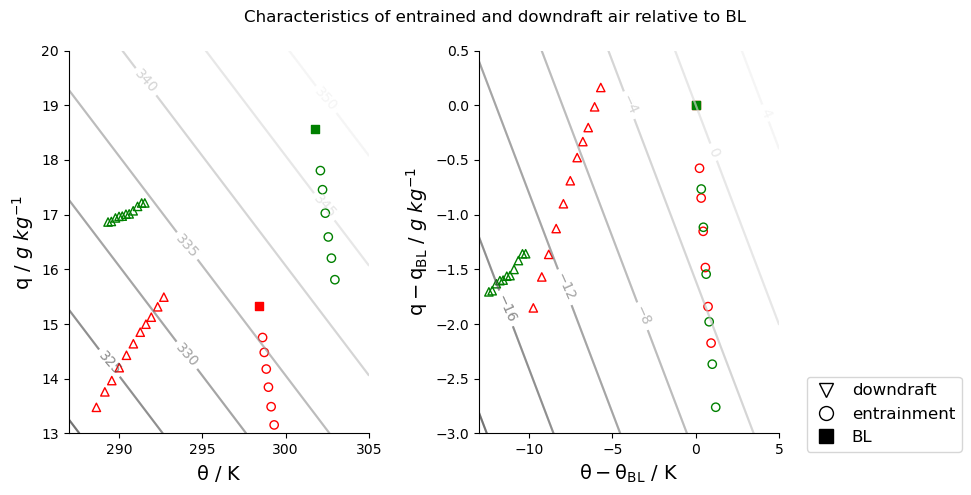

In [116]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Characteristics of entrained and downdraft air relative to BL")

th, q = np.linspace(287, 305), np.linspace(0.013*1e3, 0.02*1e3)
dth, dq = np.linspace(-13, 5), np.linspace(-3.e-3*1e3, (5e-4)*1e3)
Th, Q = np.meshgrid(th, q)
DTh, DQ = np.meshgrid(dth, dq)

MSE  = (cp*Th + Lv*Q/1e3)/cp
DMSE = (cp*DTh + Lv*DQ/1e3)/cp



datasets = {
    "eu": dict(color="red", sst=sst_eu.item(),  q_sfc=q_sfc_eu*1e3,  theta_bl=theta_bl_eu, q_bl=q_bl_eu,
               theta_out=theta_out_eu[::5], q_out=q_out_eu[::5]*1e3,
               thetaD=thetaD_eu[::10],       qSat=qSat_out_eu[::10]*1e3),
    "or": dict(color="green", sst=sst_or.item(),  q_sfc=q_sfc_or*1e3, theta_bl=theta_bl_or, q_bl=q_bl_or,
               theta_out=theta_out_or[::5], q_out=q_out_or[::5]*1e3,
               thetaD=thetaD_or[::10],       qSat=qSat_out_or[::10]*1e3),
}

for d in datasets.values():
    c, th_bl, q_bl, q_sfc, sst = d["color"], d["theta_bl"], d["q_bl"]*1e3 , d["q_sfc"], d["sst"]

    # absolute coords (ax[0])
    ax[0].scatter(th_bl,        q_bl,        c=c,           marker="s")
    ax[0].scatter(d["theta_out"], d["q_out"], edgecolors=c, marker="o", facecolors="none")
    ax[0].scatter(d["thetaD"],   d["qSat"],  edgecolors=c, marker="^", facecolors="none")
    cs = ax[0].contour(Th, Q, MSE, cmap="Greys_r", alpha=0.4)
    ax[0].clabel(cs, inline=True)
    ax[0].set_xlabel(r"$\rm \theta$ / K", fontsize=14)
    ax[0].set_ylabel(r"$\rm q$ / $g~kg^{-1}$", fontsize=14)


    # relative to BL (ax[1])
    ax[1].scatter(0,                          0,                          c=c,           marker="s")
    ax[1].scatter((d["theta_out"] - th_bl),     (d["q_out"] - q_bl),         edgecolors=c, marker="o", facecolors="none")
    ax[1].scatter((d["thetaD"]    - th_bl),     (d["qSat"]  - q_bl),         edgecolors=c, marker="^", facecolors="none")
    cs = ax[1].contour(DTh, DQ, DMSE, cmap="Greys_r", alpha=0.4)
    ax[1].clabel(cs, inline=True)
    ax[1].set_xlabel(r"$\rm \theta - \theta_{BL}$ / K", fontsize=14)
    ax[1].set_ylabel(r"$\rm q - q_{BL}$ / $g~kg^{-1}$", fontsize=14)

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

downdraft   = mlines.Line2D([], [], color='black', marker='v', linestyle='None',
                            markerfacecolor='none', markeredgecolor='black',
                            markersize=10, label=r'downdraft')
 
entrainment = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                            markerfacecolor='none', markeredgecolor='black',
                            markersize=10, label='entrainment')
 
bl          = mlines.Line2D([], [], color='black', marker='s', linestyle='None',
                            markerfacecolor='black', markeredgecolor='black',
                            markersize=10, label='BL')
 
legend = ax[1].legend(handles=[downdraft, entrainment, bl],
                   loc='center', frameon=True, fontsize=12,
                   handlelength=1.5, handletextpad=0.8, bbox_to_anchor=(1.35, 0.05))

plt.tight_layout()

In [45]:
eps = 0.295           # 0.14
oc_abs = 0.97         ## ocean absorptivity == emissivity
stefan = 5.67*1e-8
eta = 0.02
oc_alb = 0.055

def rad_terms_local(sw_in, lw_in, sst):
    return (eps/(1-eps))*lw_in +eps*oc_abs*stefan*(sst)**4 + ((eta/(1-eta)) + eta*(1-oc_alb))*sw_in

def R_net_local(sw_in, lw_in, sst, theta_bl):
    return rad_terms_local(sw_in, lw_in, sst) - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl)**4


RNet_eu = R_net_local(ingr_eu.sw_global.sel(cell=0).mean(dim="time").values,
                ingr_eu.lw_diff.sel(cell=0).mean(dim="time").values,
                sst_eu.values, 
                props_eu["theta_bl"].values)


RNet_or = R_net_local(ingr_or.sw_global.sel(cell=0).mean(dim="time").values,
                ingr_or.lw_diff.sel(cell=0).mean(dim="time").values,
                sst_or.values, 
                props_or["theta_bl"].values)



radi = [
    [r"Net radiation (W/m²)", RNet_eu, RNet_or],
]

# Create DataFrame
df = pd.DataFrame(radi, columns=["Quantity", "EU", "OR"])

display(HTML(df.to_html(index=False, table_id="summary-table")))

Quantity,EU,OR
Net radiation (W/m²),-10.069128,-8.363278


In [51]:

RNet_time = R_net(ingr_eu.sw_global.sel(cell=0).values,
                ingr_eu.lw_diff.sel(cell=0).values,
                ingr_eu.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell"]).values, 
                ds_eureca_bco.theta.sel(height=mixed_avg_levels).mean().values)

RNet_time

array([ -4.87634541,  -5.01426629,  -4.92385027,  -4.88877468,
        -4.93387745,  -5.09413938,  -5.17680318,  -5.25636358,
        -5.41193225,  -5.36508458,  -5.5295948 ,  -5.58027078,
       -12.72014032,  -8.7362442 ,  -8.87146091,  -8.98242328,
       -12.67499238, -13.81539737, -16.09701758, -13.76118259,
        -6.02368537,  -5.71973322,  -6.87686637,  -9.22543675,
       -13.14659031, -16.04069388, -17.88118152, -12.37430092,
       -10.26320839, -11.01801076,  -8.33841676,  -9.90840838,
       -10.93122042, -14.90793304, -18.01477935, -13.00638089,
       -12.8793618 , -12.15527918, -16.88134803, -10.92180134,
       -12.73772934,  -7.36292448,  -7.28198019, -11.86413568,
       -10.14168609, -12.64516817, -11.90749382,  -8.35367896,
        -5.20067108,  -4.90887313, -14.95996451, -13.98237383,
       -15.12304853,  -7.44276463,  -9.27842205, -11.29570691,
        -9.38036287, -13.12949631, -12.82287628])

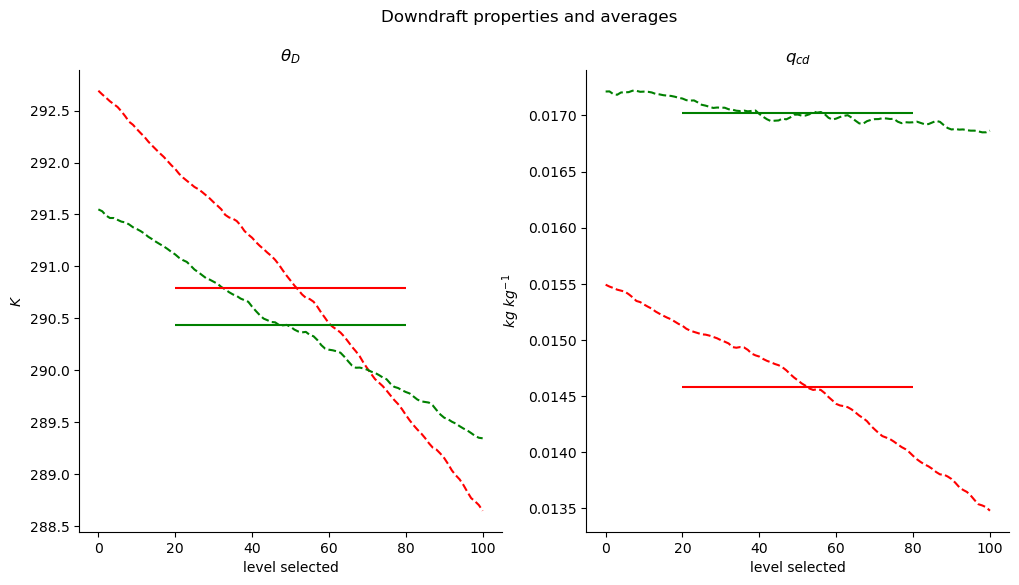

In [52]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
fig.suptitle("Downdraft properties and averages")

ax[0].plot(thetaD_eu, "--", color="red", label="EUREC4A")
ax[0].plot(thetaD_or, "--", color="green", label="ORCESTRA")

ax[0].hlines(xmin=20, xmax=80, y=np.nanmean(thetaD_eu), color="red", label="EUREC4A")
ax[0].hlines(xmin=20, xmax=80, y=np.nanmean(thetaD_or), color="green", label="ORCESTRA")

ax[0].set_xlabel("level selected")
ax[0].set_ylabel(r"$K$")
ax[0].set_title(r"$\theta_D$")



ax[1].plot(qSat_out_eu, "--", color="red", label="EUREC4A")
ax[1].plot(qSat_out_or, "--", color="green", label="ORCESTRA")
ax[1].hlines(xmin=20, xmax=80, y=np.nanmean(qSat_out_eu), color="red", label="EUREC4A")
ax[1].hlines(xmin=20, xmax=80, y=np.nanmean(qSat_out_or), color="green", label="ORCESTRA")

ax[1].set_xlabel("level selected")
ax[1].set_ylabel(r"$kg~kg^{-1}$")
ax[1].set_title(r"$q_{cd}$")

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

In [53]:
############  matrix coefficients
cp = 1004. 
Lv = 2.5e6

## save resulting values, depending on height selected
me_eu, me_or = [], []
mD_eu, mD_or = [], []


# Fa_q_eu         = (-2e-3)/86400.   # kg/kg / day
# Fa_th_eu        = (-1.)/86400.     # K / day
# bl_height    = 500.             # mean mixed layer height / m
# bl_density   = 1.               # vertically averaged density of the boundary layer / kg/m3


for i in range(theta_out_eu.size):
    A_eu = np.array([
        [
            theta_out_eu[i] - theta_bl_eu,  np.nanmean(thetaD_eu) - theta_bl_eu
        ],
        [
            q_out_eu[i] - q_bl_eu,          np.nanmean(qSat_out_eu) - q_bl_eu
        ]
    ])

    b_eu = np.array([
        - shf_recShip_eu/cp - (RNet_eu)/cp - bl_density*bl_height*Fa_th_eu,
        - lhf_recShip_eu / Lv - bl_density*bl_height*Fa_q_eu
    ])
    
    x_eu = np.linalg.pinv(A_eu) @ b_eu

    me_eu.append(x_eu[0])
    mD_eu.append(x_eu[1])



# Fa_q_or         = (-0.25e-3)/86400.   # kg/kg / day
# Fa_th_or        = (-0.25)/86400.      # K / da

for i in range(theta_out_or.size):
    A_or = np.array([
        [
            theta_out_or[i] - theta_bl_or,    np.nanmean(thetaD_or) - theta_bl_or
        ],
        [
            q_out_or[i] - q_bl_or,            np.nanmean(qSat_out_or) - q_bl_or
        ]
    ])

    b_or = np.array([
        - shf_recShip_or/cp - (RNet_or)/cp - bl_density*bl_height*Fa_th_or,   #( non_thBL_terms_or - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_or)**4 )/cp,
        - lhf_recShip_or/Lv - bl_density*bl_height*Fa_q_or
    ])    

    x_or = np.linalg.pinv(A_or) @ b_or

    me_or.append(x_or[0])
    mD_or.append(x_or[1])

me_eu, me_or = np.array(me_eu), np.array(me_or)
mD_eu, mD_or = np.array(mD_eu), np.array(mD_or)


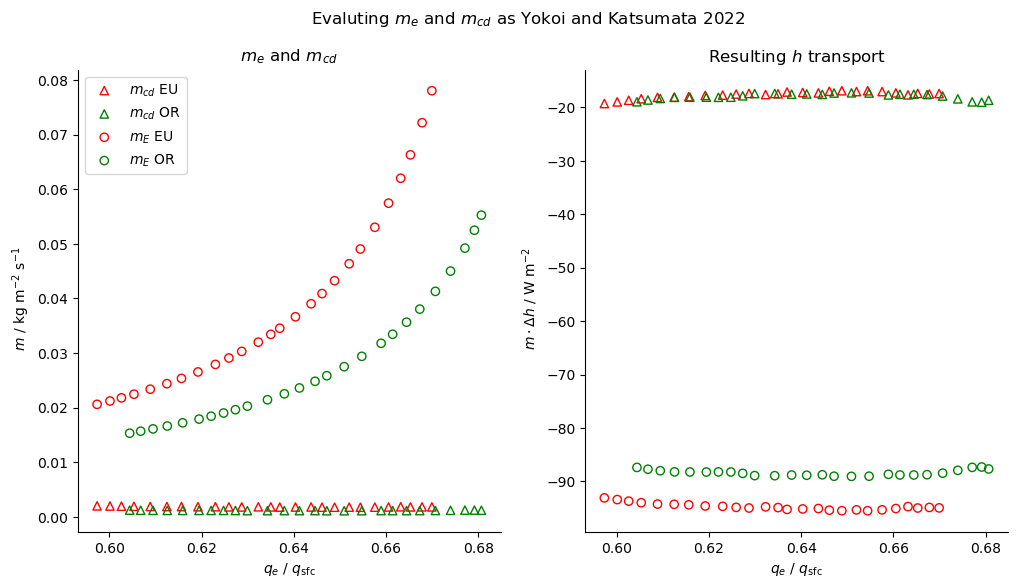

In [54]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
fig.suptitle(r"Evaluting $m_e$ and $m_{cd}$ as Yokoi and Katsumata 2022")

#### report E for values of q_out
ax[0].scatter(q_out_eu/q_sfc_eu, mD_eu, marker="^", facecolors='none', edgecolors="red", label=r"$m_{cd}$ EU")
ax[0].scatter(q_out_or/q_sfc_or, mD_or, marker="^", facecolors='none', edgecolors="green", label=r"$m_{cd}$ OR")

ax[0].scatter(q_out_eu/q_sfc_eu, me_eu, marker="o", facecolors='none', edgecolors="red", label=r"$m_{E}$ EU")
ax[0].scatter(q_out_or/q_sfc_or, me_or, marker="o", facecolors='none', edgecolors="green", label=r"$m_{E}$ OR")

ax[0].set_xlabel(r"$q_e$ / $q_\mathrm{sfc}$")
ax[0].set_ylabel(r" $m$ / $\rm kg~m^{-2}~s^{-1}$")
ax[0].set_title(r"$m_e$ and $m_{cd}$")
ax[0].legend()




#### report E for values of q_out
ax[1].scatter(q_out_eu/q_sfc_eu, mD_eu*(  cp*(np.nanmean(thetaD_eu) - theta_bl_eu) + Lv*(np.nanmean(qSat_out_eu) - q_bl_eu)  ), marker="^", facecolors='none', edgecolors="red", label=r"$m_{cd}$ EU")
ax[1].scatter(q_out_or/q_sfc_or, mD_or*(  cp*(np.nanmean(thetaD_or) - theta_bl_or) + Lv*(np.nanmean(qSat_out_or) - q_bl_or)  ), marker="^", facecolors='none', edgecolors="green", label=r"$m_{cd}$ OR")

ax[1].scatter(q_out_eu/q_sfc_eu, me_eu*( cp*(theta_out_eu - theta_bl_eu) + Lv*(q_out_eu - q_bl_eu) ) , marker="o", facecolors='none', edgecolors="red", label=r"$m_{E}$ EU")
ax[1].scatter(q_out_or/q_sfc_or, me_or*( cp*(theta_out_or - theta_bl_or) + Lv*(q_out_or - q_bl_or) ), marker="o", facecolors='none', edgecolors="green", label=r"$m_{E}$ OR")
ax[1].set_xlabel(r"$q_e$ / $q_\mathrm{sfc}$")
ax[1].set_ylabel(r" $m\cdot \Delta h$ / $\rm W~m^{-2}$")
ax[1].set_title(r"Resulting $h$ transport")
# ax[1].legend()



for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)
        # ax_twin.spines[spine].set_visible(False)


only two slightly different values of convective downdraft mass transport

the fact that we obtain only four values for $h$ transport is good: we are trying to explain only two fixed profiles :)

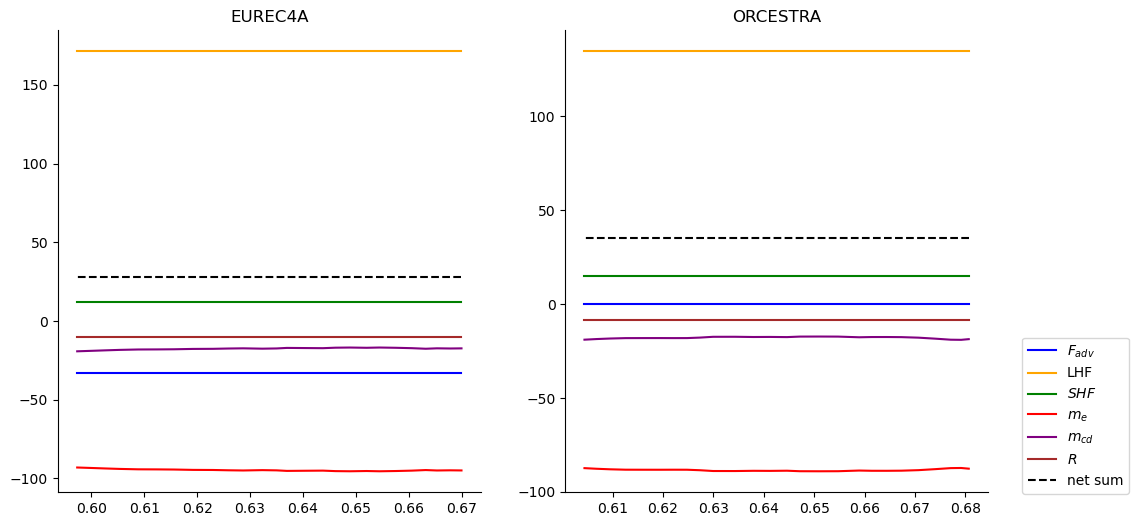

In [61]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))

labels = [
    r"$F_{adv}$",
    r"LHF",
    r"$SHF$",
    r"$m_e$",
    r"$m_{cd}$",
    r"$R$"
]

colors = [
    "blue",
    "orange",
    "green",
    "red",
    "purple",
    "brown"
]


terms = [(bl_density*bl_height*(cp*Fa_th_eu + Lv*Fa_q_eu) )*np.ones_like(q_out_eu),      # full advection           (r"$F_{adv}$"")
lhf_era5_eu.values*np.ones_like(q_out_eu),                                # reconstructed latent.    (r"LHF")
shf_era5_eu.values*np.ones_like(q_out_eu),                                      # reconstructed sensible.  (r"$SHF$")
me_eu*( cp*(theta_out_eu - theta_bl_eu) + Lv*(q_out_eu - q_bl_eu) ),          # contributio from entrainment (r"$m_e$")
mD_eu*(  cp*(np.nanmean(thetaD_eu) - theta_bl_eu) + Lv*(np.nanmean(qSat_out_eu) - q_bl_eu)  ),
RNet_eu*np.ones_like(q_out_eu)]                                                          # net radiation (R)

net_sum = 0
for i, (label, color) in enumerate(zip(labels, colors)):
    net_sum += terms[i]
    ax[0].plot(q_out_eu/q_sfc_eu, terms[i], label=label, color=color)
ax[0].plot(q_out_eu/q_sfc_eu, net_sum, "k--")
ax[0].set_title("EUREC4A")



terms = [(bl_density*bl_height*(cp*Fa_th_or + Lv*Fa_q_or) )*np.ones_like(q_out_or),      # full advection           (r"$F_{adv}$"")
lhf_era5_or.values*np.ones_like(q_out_or),                                # reconstructed latent.    (r"LHF")
shf_era5_or.values*np.ones_like(q_out_or),                                      # reconstructed sensible.  (r"$SHF$")
me_or*( cp*(theta_out_or - theta_bl_or) + Lv*(q_out_or - q_bl_or) ),          # contributio from entrainment (r"$m_e$")
mD_or*(  cp*(np.nanmean(thetaD_or) - theta_bl_or) + Lv*(np.nanmean(qSat_out_or) - q_bl_or)  ),  # downdrafts  (r"$m_{cd}$")
RNet_or*np.ones_like(q_out_or)]                                                           # net radiation (R)

net_sum = 0
for i, (label, color) in enumerate(zip(labels, colors)):
    net_sum += terms[i]
    ax[1].plot(q_out_or/q_sfc_or, terms[i], label=label, color=color)
ax[1].plot(q_out_or/q_sfc_or, net_sum, "k--", label="net sum")
ax[1].set_title("ORCESTRA")
ax[1].legend(bbox_to_anchor=(1.35, 0.35))


for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

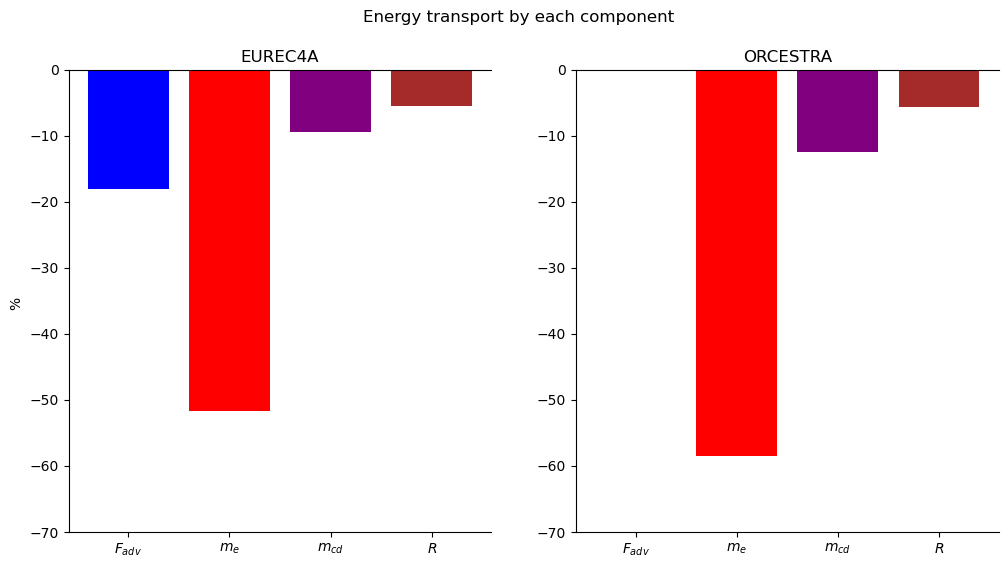

In [62]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
fig.suptitle("Energy transport by each component")

labels = [
    r"$F_{adv}$",
    r"$m_e$",
    r"$m_{cd}$",
    r"$R$"
]

colors = [
    "blue",
    "red",
    "purple",
    "brown"
]


terms = [(bl_density*bl_height*(cp*Fa_th_eu + Lv*Fa_q_eu) )*np.ones_like(q_out_eu),      # full advection           (r"$F_{adv}$"")
me_eu*( cp*(theta_out_eu - theta_bl_eu) + Lv*(q_out_eu - q_bl_eu) ),          # contributio from entrainment (r"$m_e$")
mD_eu*(  cp*(np.nanmean(thetaD_eu) - theta_bl_eu) + Lv*(np.nanmean(qSat_out_eu) - q_bl_eu)  ),
RNet_eu*np.ones_like(q_out_eu)]  

bar_values = [100*terms[i][0]/(lhf_era5_eu.values + shf_era5_eu.values) for i in range(len(terms))]

ax[0].bar(labels, bar_values, color=colors)
# ax[0].axhline(y=sum(bar_values), color='k', linestyle='--')
ax[0].set_title("EUREC4A")
ax[0].set_ylabel(r"% ")





terms = [(bl_density*bl_height*(cp*Fa_th_or + Lv*Fa_q_or) )*np.ones_like(q_out_or),      # full advection           (r"$F_{adv}$""), 
me_or*( cp*(theta_out_or - theta_bl_or) + Lv*(q_out_or - q_bl_or) ),          # contributio from entrainment (r"$m_e$")
mD_or*(  cp*(np.nanmean(thetaD_or) - theta_bl_or) + Lv*(np.nanmean(qSat_out_or) - q_bl_or)  ),  # downdrafts  (r"$m_{cd}$")
RNet_or*np.ones_like(q_out_or)] 

bar_values = [100*terms[i][0]/(lhf_era5_or.values + shf_era5_or.values) for i in range(len(terms))]

ax[1].bar(labels, bar_values, color=colors)
# ax[1].axhline(y=sum(bar_values), color='k', linestyle='--')
ax[1].set_title("ORCESTRA")




for x in ax:
    x.set_ylim(-70, 0)
    for spine in [ 'right']:
        x.spines[spine].set_visible(False)

/tmp/ipykernel_314427/785541825.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(labels, rotation=45, ha='right')
/tmp/ipykernel_314427/785541825.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(labels, rotation=45, ha='right')


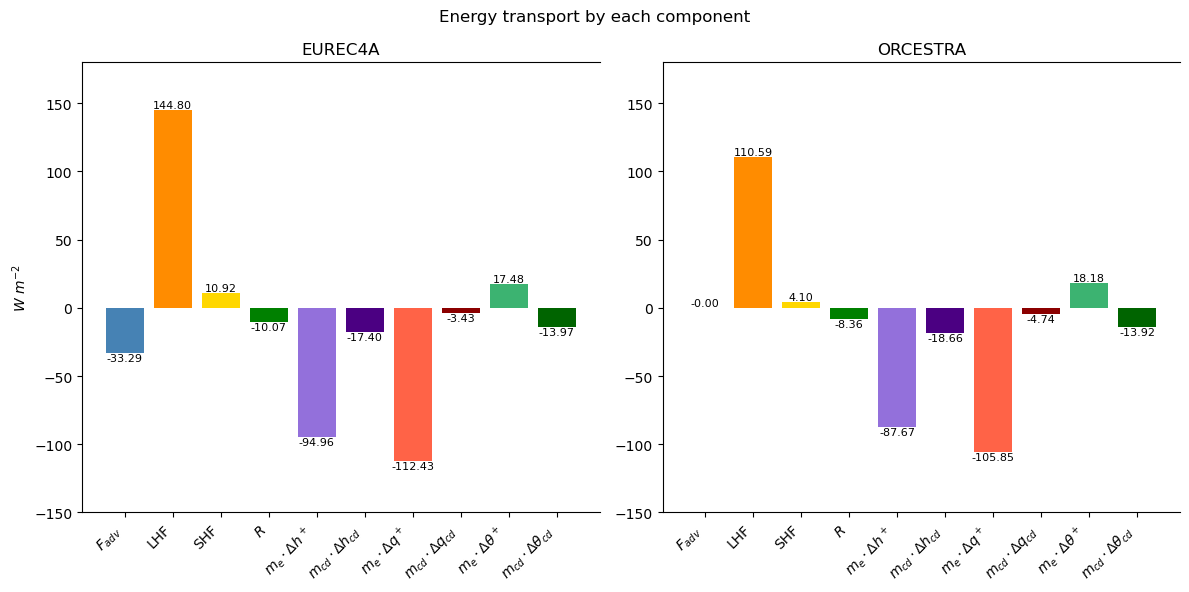

In [55]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
fig.suptitle("Energy transport by each component")

labels = [
    r"$F_{adv}$",
    "LHF",
    "SHF",
    r"$R$",
    r"$m_e\cdot \Delta h^+$",
    r"$m_{cd}\cdot \Delta h_{cd}$",
    r"$m_e\cdot \Delta q^+$",
    r"$m_{cd}\cdot \Delta q_{cd}$",
    r"$m_e\cdot \Delta \theta^+$",
    r"$m_{cd}\cdot \Delta \theta_{cd}$",
]

colors = [
    "steelblue",        # F_adv
    "darkorange",       # LHF
    "gold",             # SHF
    "green",            # R
    "mediumpurple",     # m_e · Δh+
    "indigo",           # m_cd · Δh_cd
    "tomato",           # m_e · Δq+
    "darkred",          # m_cd · Δq_cd
    "mediumseagreen",   # m_e · Δθ+
    "darkgreen",        # m_cd · Δθ_cd
]


terms = [(bl_density*bl_height*(cp*Fa_th_eu + Lv*Fa_q_eu) )*np.ones_like(q_out_eu),      # full advection           (r"$F_{adv}$"")
         lhf_recShip_eu.values*np.ones_like(q_out_eu), 
         shf_recShip_eu.values*np.ones_like(q_out_eu)  ,
         RNet_eu*np.ones_like(q_out_eu),
me_eu*( cp*(theta_out_eu - theta_bl_eu) + Lv*(q_out_eu - q_bl_eu) ),   
mD_eu*(  cp*(np.nanmean(thetaD_eu) - theta_bl_eu) + Lv*(np.nanmean(qSat_out_eu) - q_bl_eu)  ),
me_eu*Lv*(q_out_eu - q_bl_eu),
mD_eu*Lv*(np.nanmean(qSat_out_eu) - q_bl_eu),
me_eu*cp*(theta_out_eu - theta_bl_eu),
mD_eu*cp*(np.nanmean(thetaD_eu)- theta_bl_eu) ]  

bar_values = [terms[i][0]for i in range(len(terms))]

ax[0].bar(labels, bar_values, color=colors)
for i, v in enumerate(bar_values):
    ax[0].text(i, v, f"{v:.2f}", ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)
# ax[0].axhline(y=sum(bar_values), color='k', linestyle='--')
ax[0].set_title("EUREC4A")
ax[0].set_ylabel(r"$W~m^{-2}$")
ax[0].set_xticklabels(labels, rotation=45, ha='right')






terms = [(bl_density*bl_height*(cp*Fa_th_or + Lv*Fa_q_or) )*np.ones_like(q_out_or),      # full advection           (r"$F_{adv}$"")
         lhf_recShip_or.values*np.ones_like(q_out_or), 
         shf_recShip_or.values*np.ones_like(q_out_or)  ,
         RNet_or*np.ones_like(q_out_or),
me_or*( cp*(theta_out_or - theta_bl_or) + Lv*(q_out_or - q_bl_or) ),   
mD_or*(  cp*(np.nanmean(thetaD_or) - theta_bl_or) + Lv*(np.nanmean(qSat_out_or) - q_bl_or)  ),
me_or*Lv*(q_out_or - q_bl_or),
mD_or*Lv*(np.nanmean(qSat_out_or) - q_bl_or),
me_or*cp*(theta_out_or - theta_bl_or),
mD_or*cp*(np.nanmean(thetaD_or)- theta_bl_or) ] 

bar_values = [terms[i][0] for i in range(len(terms))]

ax[1].bar(labels, bar_values, color=colors)
for i, v in enumerate(bar_values):
    ax[1].text(i, v, f"{v:.2f}", ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)

# ax[1].axhline(y=sum(bar_values), color='k', linestyle='--')
ax[1].set_title("ORCESTRA")
ax[1].set_xticklabels(labels, rotation=45, ha='right')




plt.tight_layout()

for x in ax:
    x.set_ylim(-150, 180)
    for spine in [ 'right']:
        x.spines[spine].set_visible(False)

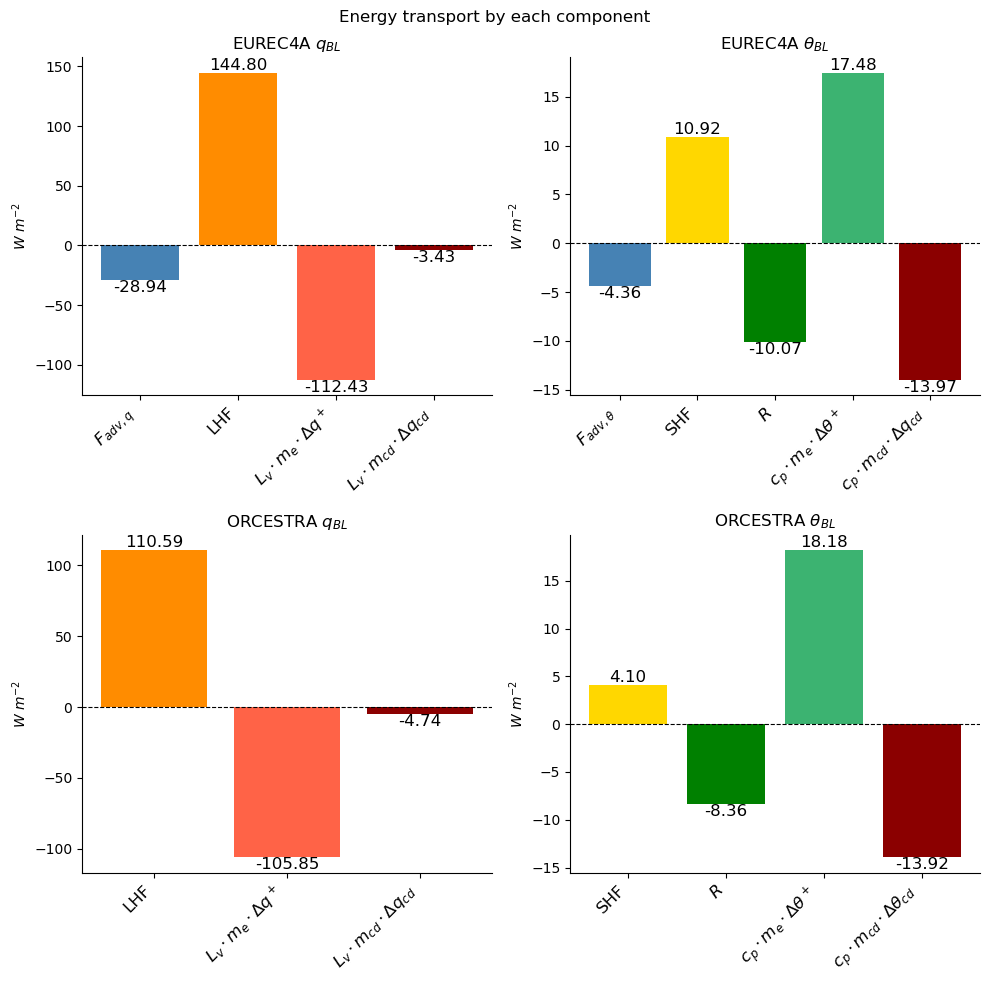

In [56]:
fig, ax = plt.subplots(2,2, figsize=(10, 10))
ax = ax.flatten()
fig.suptitle("Energy transport by each component")



labels = [
    r"$F_{adv, q}$",
    "LHF",
    r"$L_v \cdot m_e\cdot \Delta q^+$",
    r"$L_v \cdot m_{cd}\cdot \Delta q_{cd}$"
]

colors = [
    "steelblue",        # F_adv
    "darkorange",       # LHF
    "tomato",           # m_e · Δq+
    "darkred"
]


terms_moisture_eu = [(bl_density*bl_height*(Lv*Fa_q_eu) )*np.ones_like(q_out_eu),      # cp*Fa_th_eu + 
         lhf_recShip_eu.values*np.ones_like(q_out_eu), 
         me_eu*Lv*(q_out_eu - q_bl_eu),
         mD_eu*Lv*(np.nanmean(qSat_out_eu) - q_bl_eu)] 

bar_values = [terms_moisture_eu[i][0]for i in range(len(terms_moisture_eu))]

all_labels = labels #+ ["res"]

ax[0].bar(all_labels, bar_values, color=colors )   # + [sum(bar_values)]    + ['grey']
for i, v in enumerate(bar_values):   # + [sum(bar_values)]
    ax[0].text(i, v, f"{v:.2f}", ha='center', va='bottom' if v >= 0 else 'top', fontsize=12)
ax[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
ax[0].set_title(r"EUREC4A $q_{BL}$")
ax[0].set_ylabel(r"$W~m^{-2}$")
ax[0].set_xticks(range(len(all_labels)))
ax[0].set_xticklabels(all_labels, rotation=45, ha='right', fontsize=12)







labels = [
    r"$F_{adv, \theta}$",
    "SHF",
    r"$R$",
    r"$c_p \cdot m_e \cdot \Delta \theta^+$",
    r"$c_p \cdot m_{cd}\cdot \Delta q_{cd}$"
]


colors = [
    "steelblue",        # F_adv
    "gold",             # SHF
    "green",            # R
    "mediumseagreen",   # m_e · Δθ+
    "darkred"
]

terms_th_eu = [(bl_density*bl_height*(cp*Fa_th_eu) )*np.ones_like(q_out_eu),      # full advection           (r"$F_{adv}$"")
         shf_recShip_eu.values*np.ones_like(q_out_eu)  ,
         RNet_eu*np.ones_like(q_out_eu),
         me_eu*cp*(theta_out_eu - theta_bl_eu), 
         mD_eu*cp*(np.nanmean(thetaD_eu) - theta_bl_eu)] 

bar_values = [terms_th_eu[i][0]for i in range(len(terms_th_eu))]

all_labels = labels #+ ["res"]

ax[1].bar(all_labels, bar_values , color=colors )   #+ [sum(bar_values)]  + ['grey']
for i, v in enumerate(bar_values ):   #+ [sum(bar_values)]
    ax[1].text(i, v, f"{v:.2f}", ha='center', va='bottom' if v >= 0 else 'top', fontsize=12)
ax[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
ax[1].set_title(r"EUREC4A $\theta_{BL}$")
ax[1].set_ylabel(r"$W~m^{-2}$")
ax[1].set_xticks(range(len(all_labels)))
ax[1].set_xticklabels(all_labels, rotation=45, ha='right', fontsize=12)



labels = [
    "LHF",
    r"$L_v \cdot m_e\cdot \Delta q^+$",
    r"$L_v \cdot m_{cd}\cdot \Delta q_{cd}$"
]

colors = [
    "darkorange",       # LHF
    "tomato",           # m_e · Δq+
    "darkred",          # m_cd · Δq_cd
]

terms_moisture_or = [lhf_recShip_or.values*np.ones_like(q_out_or), 
me_or*Lv*(q_out_or - q_bl_or),
mD_or*Lv*(np.nanmean(qSat_out_or) - q_bl_or) ] 
bar_values = [terms_moisture_or[i][0]for i in range(len(terms_moisture_or))]

all_labels = labels #+ ["res"]

ax[2].bar(all_labels, bar_values , color=colors + ['grey'])    #+ [sum(bar_values)]
for i, v in enumerate(bar_values ):    #+ [sum(bar_values)]
    ax[2].text(i, v, f"{v:.2f}", ha='center', va='bottom' if v >= 0 else 'top', fontsize=12)
ax[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
ax[2].set_title(r"ORCESTRA $q_{BL}$")
ax[2].set_ylabel(r"$W~m^{-2}$")
ax[2].set_xticks(range(len(all_labels)))
ax[2].set_xticklabels(all_labels, rotation=45, ha='right', fontsize=12)








labels = [
    "SHF",
    r"$R$",
    r"$c_p \cdot m_e\cdot \Delta \theta^+$",
    r"$c_p \cdot m_{cd}\cdot \Delta \theta_{cd}$",
]


colors = [
    "gold",             # SHF
    "green",            # R
    "mediumseagreen",   # m_e · Δθ+
    "darkred",        # m_cd · Δθ_cd
]


terms_th_or = [shf_recShip_or.values*np.ones_like(q_out_or)  ,
         RNet_or*np.ones_like(q_out_or),
me_or*cp*(theta_out_or - theta_bl_or),
mD_or*cp*(np.nanmean(thetaD_or)- theta_bl_or) ] 
bar_values = [terms_th_or[i][0]for i in range(len(terms_th_or))]

all_labels = labels #+ ["res"]

ax[3].bar(all_labels, bar_values, color=colors + ['grey'])  # + [sum(bar_values)]
for i, v in enumerate(bar_values):  # + [sum(bar_values)]
    ax[3].text(i, v, f"{v:.2f}", ha='center', va='bottom' if v >= 0 else 'top', fontsize=12)
ax[3].axhline(0, color='black', linewidth=0.8, linestyle='--')
ax[3].set_title(r"ORCESTRA $\theta_{BL}$")
ax[3].set_ylabel(r"$W~m^{-2}$")
ax[3].set_xticks(range(len(all_labels)))
ax[3].set_xticklabels(all_labels, rotation=45, ha='right', fontsize=12)



for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)


plt.tight_layout()

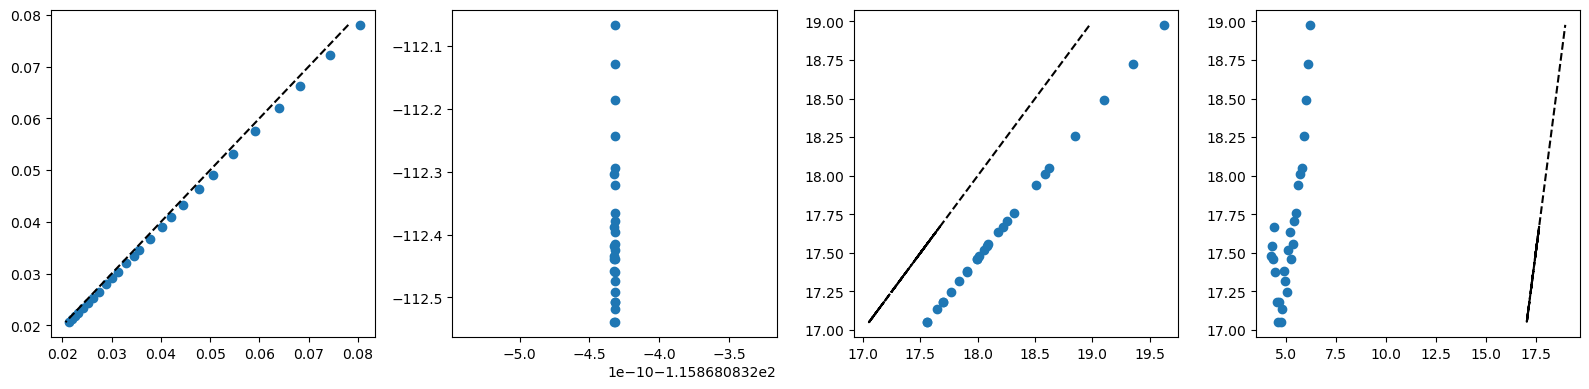

In [73]:
fig, ax = plt.subplots(1,4, figsize=(16,4))

ax[0].scatter(E_adv_eu, me_eu)
ax[0].plot(me_eu, me_eu, "k--")

ax[1].scatter(E_adv_eu*Lv*(q_out_eu - q_bl_eu), me_eu*Lv*(q_out_eu - q_bl_eu))

ax[2].scatter(E_adv_eu*cp*(theta_out_eu - theta_bl_eu), me_eu*cp*(theta_out_eu - theta_bl_eu))
ax[2].plot(me_eu*cp*(theta_out_eu - theta_bl_eu), me_eu*cp*(theta_out_eu - theta_bl_eu), "k--")

ax[3].scatter(E_adv_eu*cp*(theta_out_eu - theta_predRadAdv_eu), me_eu*cp*(theta_out_eu - theta_bl_eu))
ax[3].plot(me_eu*cp*(theta_out_eu - theta_bl_eu), me_eu*cp*(theta_out_eu - theta_bl_eu), "k--")


plt.tight_layout()


In [67]:
(q_out_eu - q_bl_eu)

array([-0.00057621, -0.00062284, -0.00067829, -0.0007248 , -0.00078287,
       -0.00084844, -0.00091757, -0.00097071, -0.00104057, -0.00110048,
       -0.0011526 , -0.00122744, -0.00130231, -0.00134512, -0.00140475,
       -0.00148388, -0.0015451 , -0.0016095 , -0.00169288, -0.00177145,
       -0.00184116, -0.00192068, -0.00199835, -0.00205818, -0.00211291,
       -0.00217433], dtype=float32)

In [68]:
E_adv_eu

array([0.08043498, 0.07441234, 0.06832956, 0.06394503, 0.05920179,
       0.05462668, 0.05051111, 0.04774588, 0.04454042, 0.04211556,
       0.04021112, 0.03775934, 0.0355886 , 0.03445583, 0.03299329,
       0.0312338 , 0.02999635, 0.02879607, 0.02737776, 0.02616348,
       0.02517285, 0.02413064, 0.02319279, 0.0225185 , 0.02193524,
       0.0213156 ])

In [91]:
import pandas as pd
from IPython.display import display, HTML

data = [
    ["LHF ERA5 (W/m²)", f"{lhf_era5_eu:.2f}", f"{lhf_era5_or:.2f}"],
    ["SHF ERA5 (W/m²)", f"{shf_era5_eu:.2f}", f"{shf_era5_or:.2f}"],
    ["R net (W/m²)", f"{(RNet_eu):.2f}", f"{(RNet_or):.2f}"],
    [r"q_e - q_{BL} (g/kg)", f"{1e3*(np.nanmean(q_out_eu) - q_bl_eu):.2f}", f"{1e3*(np.nanmean(q_out_or) - q_bl_or):.2f}"],
    [r"q_cd - q_{BL} (g/kg)", f"{1e3*(np.nanmean(qSat_out_eu) - q_bl_eu):.2f}", f"{1e3*(np.nanmean(qSat_out_or) - q_bl_or):.2f}"],
    [r"$\theta_e$ - $\theta_{BL}$ (K)", f"{(theta_out_eu[0] - theta_bl_eu):.2f}", f"{(theta_out_or[0] - theta_bl_or):.2f}"],
    [r"$\theta_{cd}$ - $\theta_{BL}$ (K)", f"{(np.nanmean(thetaD_eu) - theta_bl_eu):.2f}", f"{(np.nanmean(thetaD_or) - theta_bl_or):.2f}"],
    
]

# Create DataFrame
df = pd.DataFrame(data, columns=["Quantity","EU", "OR"])

display(HTML(df.to_html(index=False, table_id="summary-table")))

Quantity,EU,OR
LHF ERA5 (W/m²),171.35,134.73
SHF ERA5 (W/m²),12.37,15.08
R net (W/m²),-10.07,-8.36
q_e - q_{BL} (g/kg),-1.34,-1.75
q_cd - q_{BL} (g/kg),-0.75,-1.55
$\theta_e$ - $\theta_{BL}$ (K),0.22,0.33
$\theta_{cd}$ - $\theta_{BL}$ (K),-7.60,-11.32


#### how well can these numbers reconstruct relative humidity ?

$$ W_{sfc} \approx \frac{q_{bl}}{q^*_{sfc}} = \frac{V_{sfc,~lhf} + E\cdot (q^+/q^*_{sfc}) + D\cdot (q_{cd}/q^*_{sfc}) + \rho H F_{a,q} }{V_{sfc,~lhf} + E + D} $$

In [92]:
def rh_ED(Vs_lhf, me, mD, q_sfc, qE, qD, Fa_q):
    return (Vs_lhf + me*(qE/q_sfc) + mD*(qD/q_sfc) + bl_density*bl_height*Fa_q / q_sfc) / (Vs_lhf + me + mD)

rh_eu_ED = rh_ED(Vs_lhf_eu, me_eu, mD_eu, q_sfc_eu, (q_out_eu), np.nanmean(qSat_out_eu), Fa_q_eu)
rh_or_ED = rh_ED(Vs_lhf_or, me_or, mD_or, q_sfc_or, (q_out_or), np.nanmean(qSat_out_or), Fa_q_or)

In [93]:
## actual observed RH
rh_min_eu = ds_eureca_bco.rh.mean(dim="launch_time").sel(height=slice(0,100)).min().values
rh_min_or = ds_orcestra_bco.rh.mean(dim="launch_time").sel(height=slice(0,100)).min().values

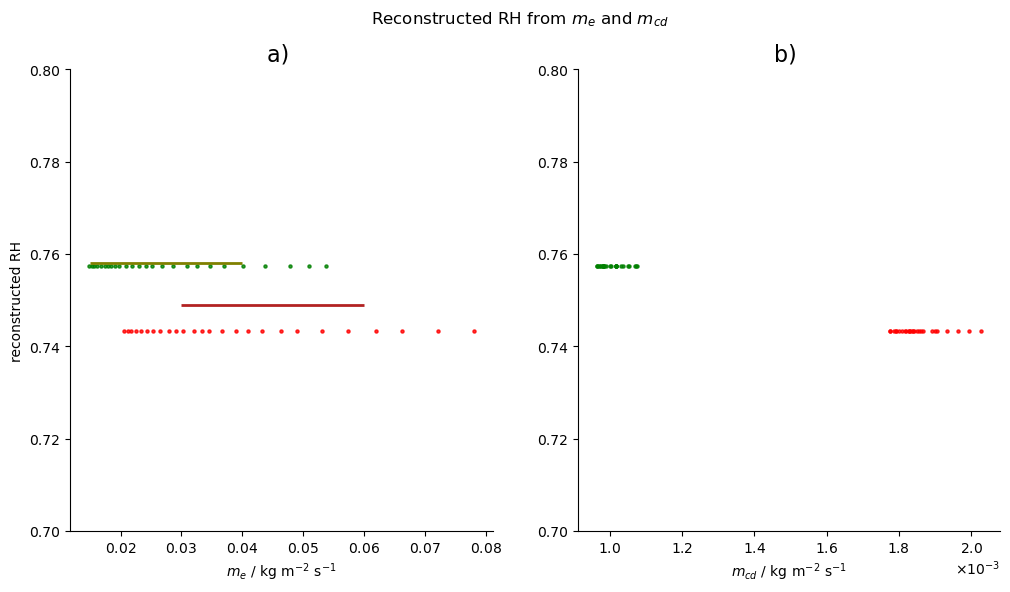

In [94]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
fig.suptitle(r"Reconstructed RH from $m_e$ and $m_{cd}$")


### factor to multiply W for to obtain a more proper estimate of RH
factor_eu = qsea(temp_eu[0]-273.15, 1013.)/1e3/q_sfc_eu    # theta_bl_eu
factor_or = qsea(temp_or[0]-273.15, 1013.)/1e3/q_sfc_or    # theta_bl_or


sc = ax[0].scatter(
    me_eu.ravel(),
    ((rh_eu_ED)/factor_eu).ravel(),
    color='red',
    s=5,
    alpha=0.8,
)

sc = ax[0].scatter(
    me_or.ravel(),
    ((rh_or_ED)/factor_or).ravel(),
    color='green',
    s=5,
    alpha=0.8,
)

# ax[0].hlines(xmin=0.03, xmax=0.06, y=(q_bl_eu/q_sfc_eu)/factor_eu, color="firebrick", linewidths=2., alpha=0.4)
# ax[0].hlines(xmin=0.015, xmax=0.04, y=(q_bl_or/q_sfc_or)/factor_or, color="olive", linewidths=2., alpha=0.4)


ax[0].hlines(xmin=0.03, xmax=0.06, y=rh_min_eu, color="firebrick", linewidths=2.)
ax[0].hlines(xmin=0.015, xmax=0.04, y=rh_min_or, color="olive", linewidths=2.)

ax[0].set_xlabel(r"$m_e$ / $\rm kg~m^{-2}~s^{-1}$")
ax[0].set_ylabel(r"reconstructed RH")
ax[0].set_title(r"a) ", fontsize=16)




sc = ax[1].scatter(
    (mD_eu).ravel(),
    ((rh_eu_ED)/factor_eu).ravel(),
    color='red',
    s=5,
    alpha=0.8,
)

sc = ax[1].scatter(
    (mD_or).ravel(),
    ((rh_or_ED)/factor_or).ravel(),
    color='green',
    s=5,
    alpha=0.8,
)


ax[1].set_xlabel(r"$m_{cd}$ / $\rm kg~m^{-2}~s^{-1}$")
ax[1].set_title(r"b) ", fontsize=16)





from matplotlib.ticker import ScalarFormatter

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0)) 

for x in ax:
    x.xaxis.set_major_formatter(formatter)
    x.set_ylim(0.7, 0.8)
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)



averaging over the convective downdraft levels makes the resulting $m_{cd}$ vary very little: what does this mean?

#### generalize to as many levels I want

In [67]:
############  matrix coefficients
cp = 1004. 
Lv = 2.5e6

## save resulting values, depending on height selected
# me_eu, me_or = [], []
# mD_eu, mD_or = [], []

me_eu, me_or = np.zeros((theta_out_eu.size, thetaD_eu.size)), np.zeros((theta_out_eu.size, thetaD_eu.size))
mD_eu, mD_or = np.zeros((theta_out_or.size, thetaD_or.size)), np.zeros((theta_out_or.size, thetaD_or.size))







# Fa_q_eu         = (-2e-3)/86400.   # kg/kg / day
# Fa_th_eu        = (-1.)/86400.     # K / day


bl_height    = 500.             # mean mixed layer height / m
bl_density   = 1.               # vertically averaged density of the boundary layer / kg/m3

##
 
for i in range(theta_out_eu.size):
    for j in range(thetaD_eu.size):
        A_eu = np.array([
            [
                theta_out_eu[i] - theta_bl_eu,  (thetaD_eu[j]) - theta_bl_eu
            ],
            [
                q_out_eu[i] - q_bl_eu,          (qSat_out_eu[j]) - q_bl_eu
            ]
        ])

        b_eu = np.array([
            - shf_recShip_eu/cp - (RNet_eu)/cp - bl_density*bl_height*Fa_th_eu,   #(non_thBL_terms_eu - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_eu)**4)/cp ,
            - lhf_recShip_eu / Lv - bl_density*bl_height*Fa_q_eu
        ])
        
        x_eu = np.linalg.pinv(A_eu) @ b_eu

        me_eu[i, j] = x_eu[0]
        mD_eu[i, j] = x_eu[1]





Fa_q_or         = (-0.25e-3)/86400.   # kg/kg / day
Fa_th_or        = (-0.25)/86400.      # K / da


for i in range(theta_out_or.size):
    for j in range(thetaD_or.size):
        A_or = np.array([
            [
                theta_out_or[i] - theta_bl_or,    (thetaD_or[j]) - theta_bl_or
            ],
            [
                q_out_or[i] - q_bl_or,            (qSat_out_or[j]) - q_bl_or
            ]
        ])

        b_or = np.array([
            - shf_recShip_or/cp - (RNet_or)/cp - bl_density*bl_height*Fa_th_or,   #( non_thBL_terms_or - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_or)**4 )/cp,
            - lhf_recShip_or/Lv - bl_density*bl_height*Fa_q_or
        ])

        x_or = np.linalg.pinv(A_or) @ b_or

        me_or[i, j] = x_or[0]
        mD_or[i, j] = x_or[1]



In [68]:
def rh_ED(Vs_lhf, me, mD, q_sfc, qE, qD, Fa_q):
    rh = np.zeros_like(me)
    
    for i in range(me.shape[0]):
        for j in range(me.shape[1]):
            rh[i,j] = (Vs_lhf + me[i,j]*(qE[i]/q_sfc) + mD[i,j]*(qD[j]/q_sfc) + bl_density*bl_height*Fa_q / q_sfc) / (Vs_lhf + me[i,j] + mD[i,j])
    
    return rh

rh_eu_ED = rh_ED(Vs_lhf_eu, me_eu, mD_eu, q_sfc_eu, (q_out_eu), (qSat_out_eu), Fa_q_eu)
rh_or_ED = rh_ED(Vs_lhf_or, me_or, mD_or, q_sfc_or, (q_out_or), (qSat_out_or), Fa_q_or)

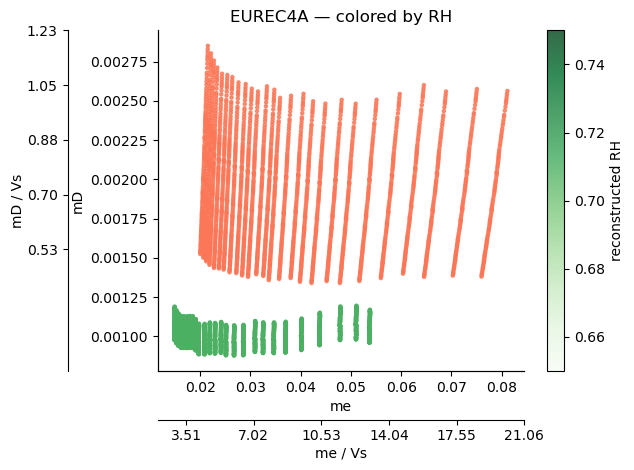

In [69]:
fig, ax = plt.subplots()

sc = ax.scatter(
    me_eu.ravel(),
    mD_eu.ravel(),
    c=rh_eu_ED.ravel(),
    cmap="Reds",
    vmin=0.65, vmax=0.75,
    s=5,
    alpha=0.8
)

sc = ax.scatter(
    me_or.ravel(),
    mD_or.ravel(),
    c=rh_or_ED.ravel(),
    cmap="Greens",
    vmin=0.65, vmax=0.75,
    s=5,
    alpha=0.8
)

## unique colorbar
plt.colorbar(sc, ax=ax, label="reconstructed RH")

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)



# --- Second X axis (below) ---
ax_bot = ax.twiny()
ax_bot.set_xlim(ax.get_xlim())

x_positions = np.array([0.02, 0.04, 0.06, 0.08, 0.1, 0.12])
x_labels = [f"{v/Vs_shf_eu:.2f}" for v in x_positions]

ax_bot.set_xticks(x_positions)
ax_bot.set_xticklabels(x_labels)
ax_bot.xaxis.set_ticks_position("bottom")
ax_bot.xaxis.set_label_position("bottom")
ax_bot.spines["bottom"].set_position(("outward", 35))
ax_bot.spines["top"].set_visible(False)
ax_bot.spines["right"].set_visible(False)
ax_bot.set_xlabel("me / Vs", labelpad=2)

# --- Second Y axis (right side, pushed outward) ---
ax_left = ax.twinx()
ax_left.set_ylim(ax.get_ylim())

y_positions = np.array([0.003, 0.004, 0.005, 0.006, 0.007])
y_labels = [f"{v/Vs_shf_eu:.2f}" for v in y_positions]

ax_left.set_yticks(y_positions)
ax_left.set_yticklabels(y_labels)
ax_left.yaxis.set_ticks_position("left")
ax_left.yaxis.set_label_position("left")
ax_left.spines["left"].set_position(("outward", 65))
ax_left.spines["top"].set_visible(False)
ax_left.spines["right"].set_visible(False)
ax_left.set_ylabel("mD / Vs", labelpad=2)

ax.set_xlabel("me")
ax.set_ylabel("mD")
ax.set_title("EUREC4A — colored by RH")

plt.tight_layout()
plt.show()

In [72]:
mD_eu.shape

(26, 101)

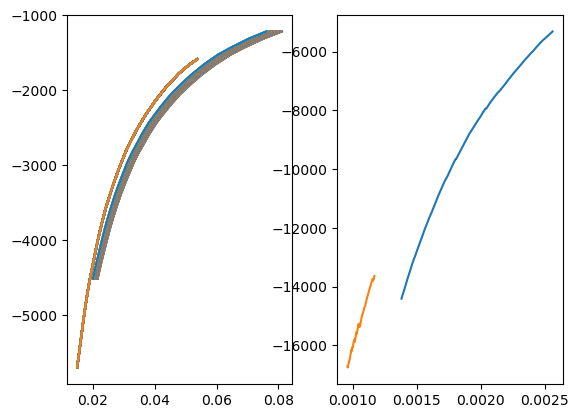

In [70]:
fig, ax = plt.subplots(1,2)

ax[0].plot(me_eu,  cp*(theta_out_eu - theta_bl_eu) + Lv*(q_out_eu - q_bl_eu) )
ax[0].plot(me_or,  cp*(theta_out_or - theta_bl_or) + Lv*(q_out_or - q_bl_or) )

ax[1].plot(mD_eu[0], cp*(thetaD_eu - theta_bl_eu) + Lv*(qSat_out_eu - q_bl_eu))
ax[1].plot(mD_or[0], cp*(thetaD_or - theta_bl_or) + Lv*(qSat_out_or - q_bl_or))


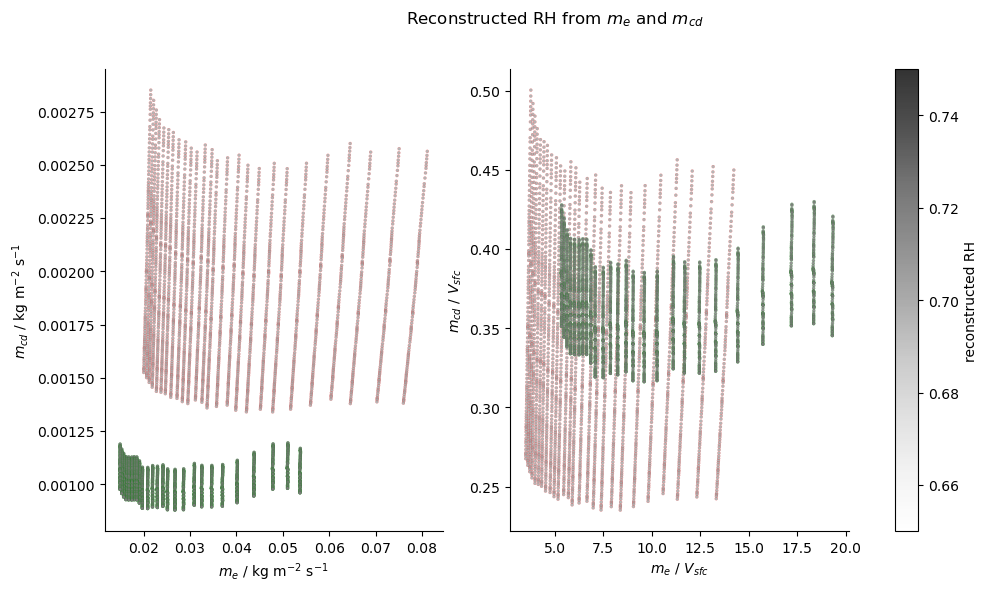

In [71]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
fig.suptitle(r"Reconstructed RH from $m_e$ and $m_{cd}$")

sc = ax[0].scatter(
    me_eu.ravel(),
    mD_eu.ravel(),
    c=rh_eu_ED.ravel(),
    cmap="Greys",
    vmin=0.65, vmax=0.75,
    s=5,
    alpha=0.8,
    edgecolors="red", 
    linewidths=0.1
)

sc = ax[0].scatter(
    me_or.ravel(),
    mD_or.ravel(),
    c=rh_or_ED.ravel(),
    cmap="Greys",
    vmin=0.65, vmax=0.75,
    s=5,
    alpha=0.8,
    edgecolors="green",   # border color
    linewidths=0.1
)

## unique colorbar
plt.colorbar(sc, ax=ax, label="reconstructed RH")

ax[0].set_xlabel(r"$m_e$ / $\rm kg~m^{-2}~s^{-1}$")
ax[0].set_ylabel(r"$m_{cd}$ / $\rm kg~m^{-2}~s^{-1}$")



sc = ax[1].scatter(
    (me_eu/Vs_shf_eu).ravel(),
    (mD_eu/Vs_shf_eu).ravel(),
    c=rh_eu_ED.ravel(),
    cmap="Greys",
    vmin=0.65, vmax=0.75,
    s=5,
    alpha=0.8,
    edgecolors="red", 
    linewidths=0.1
)

sc = ax[1].scatter(
    (me_or/Vs_shf_or).ravel(),
    (mD_or/Vs_shf_or).ravel(),
    c=rh_or_ED.ravel(),
    cmap="Greys",
    vmin=0.65, vmax=0.75,
    s=5,
    alpha=0.8,
    edgecolors="green",   # border color
    linewidths=0.1
)


ax[1].set_xlabel(r"$m_e~/~V_{sfc}$")
ax[1].set_ylabel(r"$m_{cd}~/~V_{sfc}$")


for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

In [72]:
def rh_ED(Vs_lhf, me, mD, q_sfc, qE, qD, Fa_q):
    return (Vs_lhf + me*(qE/q_sfc) + mD*(qD/q_sfc) + bl_density*bl_height*Fa_q/q_sfc) / (Vs_lhf + me + mD)

rh_eu_ED_mean = rh_ED(Vs_lhf_eu, np.nanmean(me_eu), np.nanmean(mD_eu), q_sfc_eu, np.nanmean(q_out_eu), np.nanmean(qSat_out_eu), Fa_q_eu)
rh_or_ED_mean = rh_ED(Vs_lhf_or, np.nanmean(me_or), np.nanmean(mD_or), q_sfc_or, np.nanmean(q_out_or), np.nanmean(qSat_out_or), Fa_q_or)

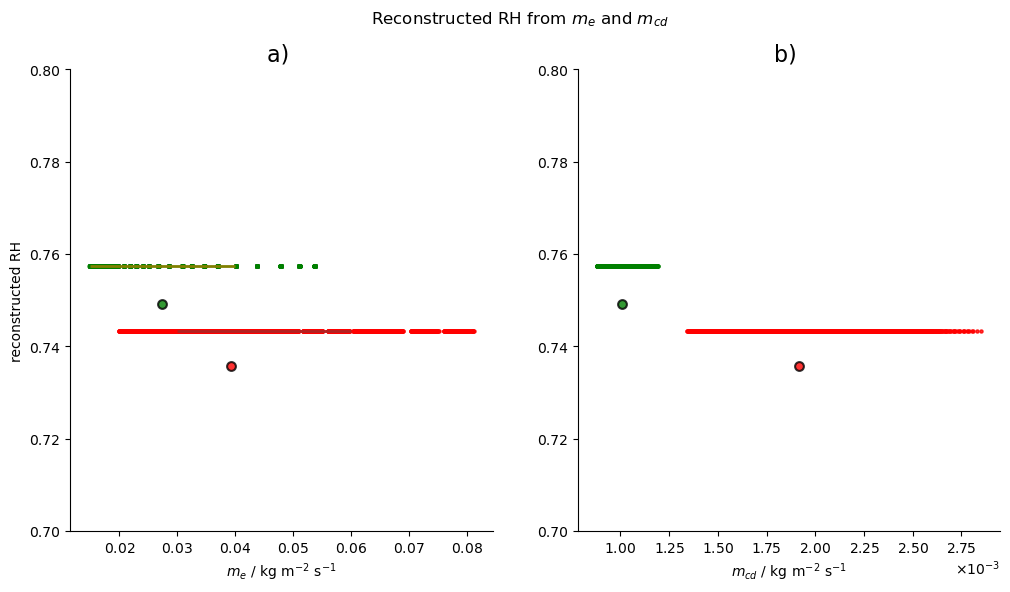

In [73]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
fig.suptitle(r"Reconstructed RH from $m_e$ and $m_{cd}$")

factor_eu = qsea(temp_eu[0]-273.15, 1013.)/1e3/q_sfc_eu    # theta_bl_eu
factor_or = qsea(temp_or[0]-273.15, 1013.)/1e3/q_sfc_or    # theta_bl_or

sc = ax[0].scatter(
    me_eu.ravel(),
    (rh_eu_ED/factor_eu).ravel(),
    color='red',
    s=5,
    alpha=0.8,
)

sc = ax[0].scatter(
    me_or.ravel(),
    (rh_or_ED/factor_or).ravel(),
    color='green',
    s=5,
    alpha=0.8,
)

ax[0].scatter(
    np.nanmean(me_eu),
    (rh_eu_ED_mean/factor_eu),
    marker="o",
    c='red',
    s=40,
    alpha=0.8,
    edgecolor="black",
    linewidths=1.5
)

ax[0].scatter(
    np.nanmean(me_or),
    (rh_or_ED_mean/factor_or),
    marker="o",
    c='green',
    s=40,
    alpha=0.8,
    edgecolor="black",
    linewidths=1.5
)


ax[0].hlines(xmin=0.03, xmax=0.06, y=(q_bl_eu/q_sfc_eu)/factor_eu, color="firebrick", linewidths=2.)
ax[0].hlines(xmin=0.015, xmax=0.04, y=(q_bl_or/q_sfc_or)/factor_or, color="olive", linewidths=2.)


ax[0].set_xlabel(r"$m_e$ / $\rm kg~m^{-2}~s^{-1}$")
ax[0].set_ylabel(r"reconstructed RH")
ax[0].set_title(r"a) ", fontsize=16)




sc = ax[1].scatter(
    (mD_eu).ravel(),
    (rh_eu_ED/factor_eu).ravel(),
    color='red',
    s=5,
    alpha=0.8,
)

sc = ax[1].scatter(
    (mD_or).ravel(),
    (rh_or_ED/factor_or).ravel(),
    color='green',
    s=5,
    alpha=0.8,
)



ax[1].scatter(
    np.nanmean(mD_eu),
    (rh_eu_ED_mean/factor_eu),
    marker="o",
    c='red',
    s=40,
    alpha=0.8,
    edgecolor="black",
    linewidths=1.5
)

ax[1].scatter(
    np.nanmean(mD_or),
    (rh_or_ED_mean/factor_or),
    marker="o",
    c='green',
    s=40,
    alpha=0.8,
    edgecolor="black",
    linewidths=1.5
)

ax[1].set_xlabel(r"$m_{cd}$ / $\rm kg~m^{-2}~s^{-1}$")
ax[1].set_title(r"b) ", fontsize=16)





from matplotlib.ticker import ScalarFormatter

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0)) 

for x in ax:
    x.xaxis.set_major_formatter(formatter)
    x.set_ylim(0.7, 0.8)
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

ValueError: x and y must be the same size

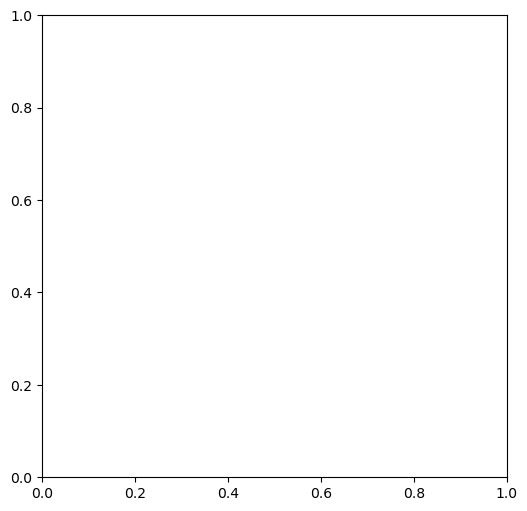

In [54]:
fig, ax = plt.subplots(1,1, figsize=(6, 6))


sc = ax.scatter(
    qSat_out_eu.ravel(),
    (mD_eu).ravel(),
    color='red',
    s=5,
    alpha=0.8,
)

sc = ax.scatter(
    qSat_out_or.ravel(),
    (mD_or).ravel(),
    color='green',
    s=5,
    alpha=0.8,
)

#### check radiation part!!

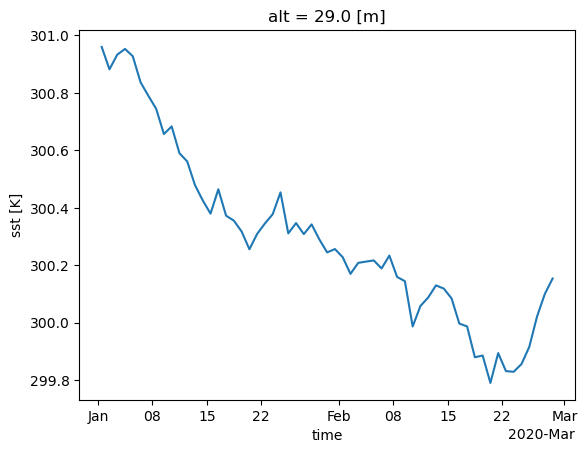

In [72]:
ingr_eu.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell"]).plot.line()

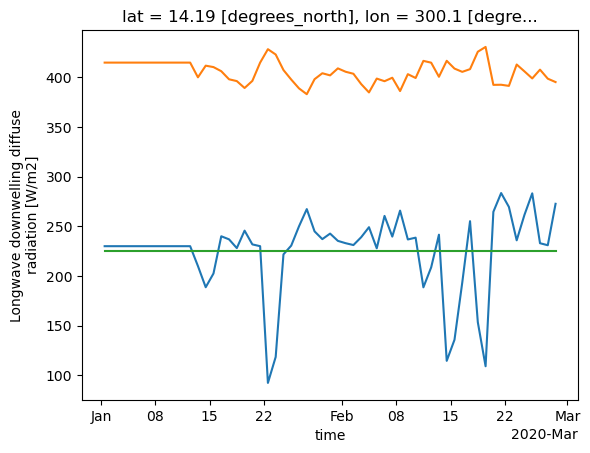

In [105]:
ingr_eu.sw_global.sel(cell=0).plot.line()
ingr_eu.lw_diff.sel(cell=0).plot.line()

mean_sw = ingr_eu.sw_global.sel(cell=0).mean(dim="time").values
mean_sw = mean_sw*np.ones(ingr_eu.time.size)

plt.plot(ingr_eu.time.values, mean_sw)


In [93]:
mean_sw = ingr_or.sw_global.sel(cell=0).mean(dim="time").values
mean_sw

array(255.77151, dtype=float32)

In [42]:
## see dependence also on choice of downdraft levels


## save resulting values, depending on height selected
me_eu, me_or = np.zeros((q_out_eu.size, qSat_out_eu.size)), np.zeros((q_out_eu.size, qSat_out_eu.size))
mD_eu, mD_or = np.zeros((q_out_or.size, qSat_out_or.size)), np.zeros((q_out_or.size, qSat_out_or.size))


##
 
for i in range(me_eu[:,0].size):
    for j in range(me_eu[0,:].size):
        A_eu = np.array([
            [
                theta_out_eu[i] - theta_bl_eu,  thetaD_eu[j] - theta_bl_eu
            ],
            [
                q_out_eu[i] - q_bl_eu,          qSat_out_eu[j] - q_bl_eu
            ]
        ])

        b_eu = np.array([
            - shf_era5_eu.values/cp - (non_thBL_terms_eu - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_eu.values)**4)/cp ,
            - lhf_era5_eu.values / Lv
        ])

        x_eu = np.linalg.pinv(A_eu) @ b_eu

        me_eu[i,j] = x_eu[0]
        mD_eu[i,j] = x_eu[1]


for i in range(me_or[:,0].size):
    for j in range(me_or[0,:].size):
        A_or = np.array([
            [
                theta_out_or[i] - theta_bl_or,    thetaD_or[j] - theta_bl_or
            ],
            [
                q_out_or[i] - q_bl_or,            qSat_out_or[j] - q_bl_or
            ]
        ])

        b_or = np.array([
            - shf_era5_or.values/cp - ( non_thBL_terms_or - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_or)**4 )/cp,
            - lhf_era5_or.values/Lv 
        ])

        x_or = np.linalg.pinv(A_or) @ b_or

        me_or[i,j] = x_or[0]
        mD_or[i,j] = x_or[1]

me_eu, me_or = np.array(me_eu), np.array(me_or)
mD_eu, mD_or = np.array(mD_eu), np.array(mD_or)


In [108]:
theta_out_eu.shape

(11,)

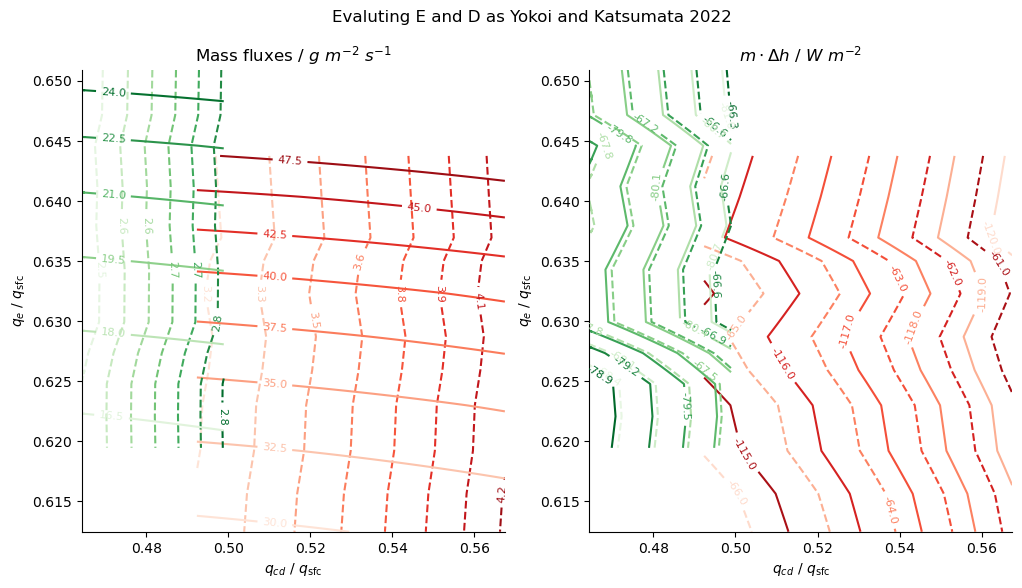

In [46]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
fig.suptitle("Evaluting E and D as Yokoi and Katsumata 2022")

#### report E for values of q_out

xx_eu, yy_eu = np.meshgrid(qSat_out_eu*1e3/q_sfc_eu, q_out_eu*1e3/q_sfc_eu)
xx_or, yy_or = np.meshgrid(qSat_out_or*1e3/q_sfc_or, q_out_or*1e3/q_sfc_or)

c1 = ax[0].contour(xx_eu, yy_eu, mD_eu*1e3, cmap="Reds", linestyles="--")   # , marker="^", facecolors='none', edgecolors="red", label=r"$m_{cd}$ EU")
c2 = ax[0].contour(xx_eu, yy_eu, me_eu*1e3, cmap="Reds")  # , marker="o", facecolors='none', edgecolors="red", label=r"$m_{E}$ EU")

c3 = ax[0].contour(xx_or, yy_or, mD_or*1e3, cmap="Greens", linestyles="--")   # , marker="^", facecolors='none', edgecolors="red", label=r"$m_{cd}$ EU")
c4 = ax[0].contour(xx_or, yy_or, me_or*1e3, cmap="Greens") 

ax[0].set_xlabel(r"$q_{cd}$ / $q_\mathrm{sfc}$")
ax[0].set_ylabel(r"$q_{e}$ / $q_\mathrm{sfc}$")
ax[0].set_title(r"Mass fluxes / $g~m^{-2}~s^{-1}$")
# ax[0].legend()

for c in [c1, c2, c3, c4]:
    plt.clabel(c, inline=True, fontsize=8, fmt='%.1f')


c1 = ax[1].contour(xx_eu, yy_eu, mD_eu*(  cp*(thetaD_eu[np.newaxis, :] - theta_bl_eu.values)    + Lv*(qSat_out_eu[np.newaxis, :] - q_bl_eu.values) ), cmap="Reds", linestyles="--" )
c2 = ax[1].contour(xx_eu, yy_eu, me_eu*(  cp*(theta_out_eu[:, np.newaxis] - theta_bl_eu.values) + Lv*(q_out_eu[:, np.newaxis] - q_bl_eu.values) ), cmap="Reds"   ) 

c3 = ax[1].contour(xx_or, yy_or, mD_or*(  cp*(thetaD_or[np.newaxis, :] - theta_bl_or.values)    + Lv*(qSat_out_or[np.newaxis, :] - q_bl_or.values) ), cmap="Greens", linestyles="--" )
c4 = ax[1].contour(xx_or, yy_or, me_or*(  cp*(theta_out_or[:, np.newaxis] - theta_bl_or.values) + Lv*(q_out_or[:, np.newaxis] - q_bl_or.values) ), cmap="Greens"   ) 

for c in [c1, c2, c3, c4]:
    plt.clabel(c, inline=True, fontsize=8, fmt='%.1f')

ax[1].set_xlabel(r"$q_{cd}$ / $q_\mathrm{sfc}$")
ax[1].set_ylabel(r"$q_{e}$ / $q_\mathrm{sfc}$")
ax[1].set_title(r"$m\cdot \Delta h$ / $W~m^{-2}$")

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)



In [59]:
theta_bl_eu.values

array(298.38904, dtype=float32)

#### can we estimate what role advection plays, using differences between each single radiosounding?

In [ ]:

def local_adv(ds, max_hgt):
    heightss = slice(50, max_hgt)
    wspd  = ds.wspd.sel(height=heightss)
    wspd_pair_mean = (wspd + wspd.shift(launch_time=-1)) / 2
    wspd_pair_mean = wspd_pair_mean.isel(launch_time=slice(0, -1)).values

    moist = ds.q.sel(height=heightss)
    th    = ds.theta.sel(height=heightss)

    dt  = (ds.launch_time.diff(dim="launch_time") / np.timedelta64(1,"h"))
    dt = dt.rename("dt")  # give it a name

    dt_hgt = dt.expand_dims(height=wspd.height).transpose("launch_time", "height")

    ## it's actually harder than I was expecting
    ## THIS IS THE TOTAL CHANGE IN TIME
    moist_adv = -wspd_pair_mean*((moist.diff(dim="launch_time")))  / (wspd_pair_mean*dt_hgt)
    th_adv    = -wspd_pair_mean*((th.diff(dim="launch_time")) ) / (wspd_pair_mean*dt_hgt)

    return moist_adv, th_adv




q_adv_eu, th_adv_eu = local_adv(ds_eureca_bco, max_hgt=500)
q_adv_or, th_adv_or = local_adv(ds_orcestra_bco, max_hgt=500)

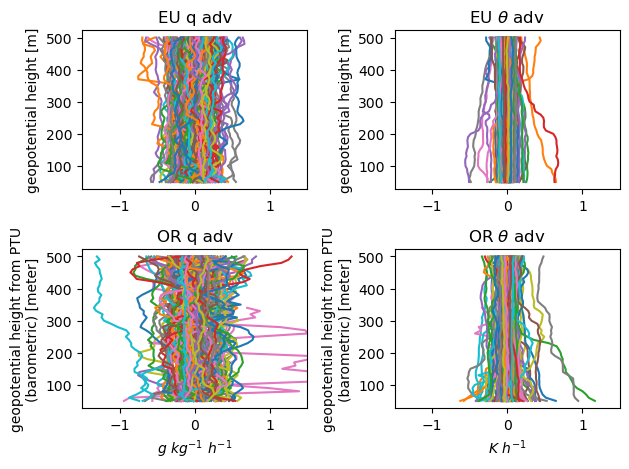

In [49]:
fig, ax = plt.subplots(2,2)
ax = ax.flatten()

(q_adv_eu*1e3).plot.line(ax=ax[0], y="height", add_legend=False)
(q_adv_or*1e3).plot.line(ax=ax[2], y="height", add_legend=False)

ax[0].set_title("EU q adv")
ax[0].set_xlabel("")
ax[2].set_title("OR q adv")
ax[2].set_xlabel(r"$g~kg^{-1}~h^{-1}$")

for x in [ax[0], ax[2]]:
    x.set_xlim(-1.5, 1.5)




th_adv_eu.plot.line(ax=ax[1], y="height", add_legend=False)
th_adv_or.plot.line(ax=ax[3], y="height", add_legend=False)

ax[1].set_title(r"EU $\theta$ adv")
ax[3].set_title(r"OR $\theta$ adv")
ax[1].set_xlabel("")
ax[3].set_xlabel(r"$K~h^{-1}$")

for x in [ax[1], ax[3]]:
    x.set_xlim(-1.5, 1.5)

plt.tight_layout()
plt.show()